# Does DNSSEC adoption follow the software? One program at a time

This notebook answers four questions for eight DNS programs: **BIND 9, Unbound, Knot DNS, Knot Resolver, NSD,
OpenDNSSEC, PowerDNS Authoritative and PowerDNS Recursor**.

1. After each version release, does DNSSEC **adoption** move in OpenINTEL (forward TLD zones) and in the RIR
   reverse data? Adoption means what the team means by it: **the % of domains in a month with at least one DS,
   DNSKEY or RRSIG record**. Separately: does the **feature use** of the zones that are already signed move, meaning
   which algorithms, DS digests and NSEC3 settings they use?
2. When a release changes a **default** (for example "sign with ECDSA unless told otherwise"), is the change
   followed by a change in adoption, or in feature use?
3. Are changes made by hand, one zone at a time, or in large automatic-looking batches, and at which level of
   the operator hierarchy?
4. Is a newer RFC published while its predecessor is still being deployed?

Every number comes from the verified outputs of Phases 1 to 7 and is read from those files when the notebook runs;
none is typed into the text. A cell says **new computation** where it computes something the phases did not
export. The two setup cells below have their code hidden; the short answer follows them.

## 0. Which OpenINTEL data this notebook reads

Every number below comes from two monthly timelines: the **server run** (OpenINTEL forward TLDs plus the five RIRs)
and the **panel run** (AFRINIC and ARIN pooled). The committed ones were built from a single drive, so the forward
TLDs stop where that drive stops. To analyse the **full** corpus, whose remaining years sit on a second "spill"
drive, set the two paths in the next cell, or export them before building:

```
OPENINTEL_MAIN=/mnt/nas_share/Josh OPENINTEL_SPILL=/mnt/spill/openintel \
    python notebooks/build_software_vs_adoption_notebook.py --run-pipeline
```

The pipeline takes hours on the full corpus. The usual way is to run it once in the background
(`python scripts/run_openintel_full.py --main ... --spill ...`, resumable) and then build this notebook normally:
it reads whatever run the analyses last used, and the cell after next says which one that is and what each drive
contributed. A source-day whose files are split across the two drives is merged, never counted twice.

In [1]:
# ---- data source: set MAIN_DRIVE and SPILL_DRIVE to analyse the full OpenINTEL corpus --------- #
import os
MAIN_DRIVE     = os.environ.get("OPENINTEL_MAIN", "")      # e.g. "/mnt/nas_share/Josh"
SPILL_DRIVE    = os.environ.get("OPENINTEL_SPILL", "")     # e.g. "/mnt/spill/openintel" -- the remaining years
REVERSE_CORPUS = os.environ.get("OPENINTEL_REVERSE", "out/reverse/corpus")   # RIR reverse zones
RUN_DIR        = os.environ.get("OPENINTEL_RUN_DIR", "out/openintel_full")   # where the new runs go
RUN_PIPELINE   = os.environ.get("OPENINTEL_RUN_PIPELINE", "0") == "1"        # True: build the runs now (hours)
print(f"main drive: {MAIN_DRIVE or '(not set)'} | spill drive: {SPILL_DRIVE or '(not set)'} | "
      f"run dir: {RUN_DIR} | run pipeline now: {RUN_PIPELINE}")

main drive: (not set) | spill drive: (not set) | run dir: out/openintel_full/server/ | run pipeline now: False


In [2]:
# ---- optionally build the runs, then report which run the analyses read ---------------------- #
import json, subprocess, sys
from pathlib import Path
_R = Path.cwd()
while not (_R / "scripts" / "run_openintel_full.py").exists():
    if _R == _R.parent:
        raise RuntimeError("run this notebook from inside the rfc_adoption repository")
    _R = _R.parent

if RUN_PIPELINE:
    if not MAIN_DRIVE:
        raise ValueError("RUN_PIPELINE is on but MAIN_DRIVE is empty: set it in the cell above.")
    _cmd = [sys.executable, str(_R / "scripts" / "run_openintel_full.py"), "--main", MAIN_DRIVE,
            "--run-dir", RUN_DIR, "--reverse-corpus", REVERSE_CORPUS]
    if SPILL_DRIVE:
        _cmd += ["--spill", SPILL_DRIVE]
    print("running:", " ".join(_cmd), flush=True)
    if subprocess.run(_cmd, cwd=_R).returncode:
        raise RuntimeError("the pipeline failed; its output above says where. Re-running resumes it.")

_inp7 = json.loads((_R / "out/analysis/software_vs_adoption.json").read_text("utf-8")).get("inputs", {})
_inpP = json.loads((_R / "out/analysis/prevalence_metrics.json").read_text("utf-8")).get("inputs", {})
print("Phase 7 (software vs adoption) read:", _inp7.get("server_run", "?"), "and", _inp7.get("panel_run", "?"))
print("Prevalence metrics read:            ", _inpP.get("server", "?"), "and", _inpP.get("panel", "?"))
_srv = Path(_inp7.get("server_run", "out/server_run/timeline_monthly.parquet"))
_srv = _srv if _srv.is_absolute() else _R / _srv
_srvP = Path(_inpP.get("server", "out/server_run/timeline_monthly.parquet"))
_srvP = _srvP if _srvP.is_absolute() else _R / _srvP
if _srvP.resolve() != _srv.resolve():
    print("WARNING: the two analyses read different server runs; rerun both "
          "(scripts/run_openintel_full.py ... --step analyses).")
_cov = _srv.parent.parent / "coverage.json"
if _srv.parent.name == "server_run" or not _cov.exists():
    print("These are the committed local runs: the forward TLDs come from a single drive. Set MAIN_DRIVE and "
          "SPILL_DRIVE above to use the full corpus.")
else:
    _c = json.loads(_cov.read_text("utf-8"))
    print(f"Coverage of this run ({_cov}), days per source and which drive held them:")
    for _k, _v in _c["per_source"].items():
        print(f"  {_k:24s} {_v['days']:6d} days  {_v['first_day']} .. {_v['last_day']}  {_v['by_drive']}")
    if _c.get("unmatched_files"):
        print(f"WARNING: {_c['unmatched_files']} file(s) matched no layout and are not in the run.")

Phase 7 (software vs adoption) read: out/openintel_full/server/timeline_monthly.parquet and out/openintel_full/panel/timeline_monthly.parquet
Prevalence metrics read:             out/openintel_full/server/timeline_monthly.parquet and out/openintel_full/panel/timeline_monthly.parquet
Coverage of this run (/home/josh/rfc_adoption/out/openintel_full/coverage.json), days per source and which drive held them:
  reverse/afrinic             200 days  2009-04-01 .. 2026-09-01  {'reverse corpus': 200}
  reverse/apnic               179 days  2009-04-01 .. 2024-12-01  {'reverse corpus': 179}
  reverse/arin                200 days  2009-04-01 .. 2026-09-01  {'reverse corpus': 200}
  reverse/lacnic              200 days  2009-04-01 .. 2026-09-01  {'reverse corpus': 200}
  reverse/ripe                200 days  2009-04-01 .. 2026-09-01  {'reverse corpus': 200}
  zonefile/ch                2302 days  2020-05-19 .. 2026-09-07  {'main': 2302}
  zonefile/ee                2586 days  2019-07-29 .. 2026-09

## Setup

Paths, palette and small drawing helpers. Note: running the setup cell deletes and rewrites every PNG in
`reporting/charts/software_vs_adoption/`, which are tracked files. The palette is the project's validated one: three categorical colours
in fixed order (blue, orange, green), a blue ramp for ordered values, and red only for a highlighted event.

In [3]:
# setup: imports, palette, drawing helpers
import json
import math
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MaxNLocator

ROOT = Path.cwd()
while not (ROOT / "data" / "software" / "timelines").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError("run this notebook from inside the rfc_adoption repository")
    ROOT = ROOT.parent
FIGDIR = ROOT / "reporting" / "charts" / "software_vs_adoption"
FIGDIR.mkdir(parents=True, exist_ok=True)
for old in FIGDIR.glob("*.png"):
    old.unlink()

SURFACE = "#fcfcfb"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"
RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#2a78d6", "#1c5cab", "#104281"]
RED = "#d03b3b"

plt.rcParams.update({
    "font.family": ["DejaVu Sans", "sans-serif"],
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9.5, "figure.dpi": 100,
})

NAME = {"bind9": "BIND 9", "unbound": "Unbound", "knot": "Knot DNS", "kresd": "Knot Resolver",
        "nsd": "NSD", "opendnssec": "OpenDNSSEC", "pdns-auth": "PowerDNS Authoritative",
        "pdns-rec": "PowerDNS Recursor"}
SRC = {"se": ".se", "nu": ".nu", "gov": ".gov", "ee": ".ee", "ch": ".ch", "li": ".li", "fed.us": ".fed.us",
       "_pooled-afrinic-arin": "reverse panel"}
TLDS = ["se", "nu", "gov", "ee", "ch", "li"]
PANEL = "_pooled-afrinic-arin"
_FIG = [0]


def style(ax, grid="y"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_axisbelow(True)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
    ax.tick_params(length=0)


def pct_axis(ax, axis="y"):
    f = FuncFormatter(lambda v, _: f"{v:g}%")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(f)


def year_axis(ax, nbins=8):
    # integer years only, so a year never prints twice
    ax.xaxis.set_major_locator(MaxNLocator(nbins=nbins, integer=True))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(round(v))}"))


def frame(fig, title, sub, bottom=0.55, left=0.07, right=0.98, hspace=None, wspace=None):
    '''Title (the finding) and subtitle (the metric) above the axes, never overlapping them.
    bottom is the space in inches kept under the axes for tick labels and a legend.'''
    W, H = fig.get_figwidth(), fig.get_figheight()
    t = textwrap.fill(title, width=int(W * 8.2))
    s = "\n".join(textwrap.fill(p, width=int(W * 13.2)) for p in sub.split("\n"))
    nt, ns = t.count("\n") + 1, s.count("\n") + 1
    y = 1 - 0.12 / H
    fig.text(0.012, y, t, fontsize=14, fontweight="bold", color=INK, va="top", ha="left")
    y -= (0.27 * nt + 0.06) / H
    fig.text(0.012, y, s, fontsize=10, color=INK_2, va="top", ha="left", linespacing=1.35)
    top = y - (0.19 * ns + 0.30) / H
    kw = dict(top=top, bottom=bottom / H, left=left, right=right)
    if hspace is not None:
        kw["hspace"] = hspace
    if wspace is not None:
        kw["wspace"] = wspace
    fig.subplots_adjust(**kw)


def legend_below(fig, handles, ncol=None, y_in=0.08):
    H = fig.get_figheight()
    fig.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.012, y_in / H), frameon=False,
               ncol=ncol or len(handles), handlelength=1.8, columnspacing=1.6)


def save(fig, name):
    _FIG[0] += 1
    path = FIGDIR / f"{_FIG[0]:02d}_{name}.png"
    fig.savefig(path, dpi=110, bbox_inches="tight", pad_inches=0.25)
    plt.show()
    plt.close(fig)
    return path


def say(text):
    '''Plain-language reading printed directly under a chart.'''
    display(Markdown(text))


def m2y(m, start=False):
    # 'YYYY-MM' -> fractional year; forward months are plotted mid-month, reverse labels at the 1st
    y, mo = int(m[:4]), int(m[5:7])
    return y + (mo - 1) / 12 + (0 if start else 0.5 / 12)


def d2y(d):
    ts = pd.Timestamp(d[:10])
    return ts.year + (ts.dayofyear - 1) / (366 if ts.is_leap_year else 365)

In [4]:
# ---- inputs, all read-only -------------------------------------------------------------- #
A7 = ROOT / "out/analysis"
J7 = json.loads((A7 / "software_vs_adoption.json").read_text("utf-8"))
J4 = json.loads((A7 / "cross_program.json").read_text("utf-8"))
Q1 = pd.read_csv(A7 / "software_vs_adoption_q1.csv")
Q1R = pd.read_csv(A7 / "software_vs_adoption_q1_releases.csv")
Q2 = pd.read_csv(A7 / "software_vs_adoption_q2.csv")
Q3 = pd.read_csv(A7 / "software_vs_adoption_q3.csv")
Q4 = pd.read_csv(A7 / "software_vs_adoption_q4.csv")
Q4A = pd.read_csv(A7 / "software_vs_adoption_q4_alignment.csv")
Q5 = pd.read_csv(A7 / "software_vs_adoption_q5.csv")
MAP = pd.read_csv(A7 / "software_vs_adoption_mapping.csv")
# Adoption (prevalence) rows are appended to the same CSVs; keep the two claims apart from here on.
PREV_OBS = ["ds_prev", "dnskey_prev", "rrsig_prev"]
PNAME = {"ds_prev": "DS", "dnskey_prev": "DNSKEY", "rrsig_prev": "RRSIG"}


def _split(df):
    m_ = df.observable.isin(PREV_OBS)
    return df[~m_].copy(), df[m_].copy()


Q1, Q1P = _split(Q1)
Q1R, Q1RP = _split(Q1R)
Q2, Q2P = _split(Q2)
Q4, Q4P = _split(Q4)
Q4A, Q4AP = _split(Q4A)
_pm, _pe = A7 / "software_vs_adoption_prevalence_mapping.csv", A7 / "software_vs_adoption_prevalence_excluded.csv"
PMAP = pd.read_csv(_pm) if _pm.exists() else pd.DataFrame(columns=["program", "row_id", "observable", "reason"])
PEXC = pd.read_csv(_pe) if _pe.exists() else pd.DataFrame(columns=["program", "row_id", "reason"])
ADOPT_DEF = "the % of domains in a month with at least one DS, DNSKEY or RRSIG record"
PREV = pd.read_csv(A7 / "prevalence_metrics.csv")
# Coverage is read from the data, never typed: a full server run adds years and possibly TLDs.
_fw = PREV[(PREV.corpus == "forward") & (PREV.metric == "ds_share")]
FWD_SPAN = {s_: (g_.month.min(), g_.month.max()) for s_, g_ in _fw.groupby("source")}
_signed = set(_fw.loc[_fw.numerator > 0, "source"])
FWD_NEVER_SIGNED = sorted(set(FWD_SPAN) - _signed)
TLDS = [t_ for t_ in TLDS if t_ in _signed] + sorted(_signed - set(TLDS))
for t_ in TLDS:
    SRC.setdefault(t_, "." + t_)
FWD_START = min(FWD_SPAN[t_][0] for t_ in TLDS)
FWD_END = max(FWD_SPAN[t_][1] for t_ in TLDS)
_pn = PREV[(PREV.corpus == "reverse_panel") & (PREV.metric == "ds_share") & (PREV.numerator > 0)]
PANEL_START, PANEL_END = _pn.month.min(), _pn.month.max()
FWD_XLIM = (m2y(FWD_START) - 0.25, m2y(FWD_END) + 0.15)
PANEL_XLIM = (m2y(PANEL_START, True) - 0.3, m2y(PANEL_END, True) + 0.2)


def _join(xs):
    xs = list(xs)
    return xs[0] if len(xs) == 1 else ", ".join(xs[:-1]) + " and " + xs[-1]


def fwd_coverage_text():
    by_start = {}
    for t_ in TLDS:
        by_start.setdefault(FWD_SPAN[t_][0], []).append(SRC[t_])
    starts = ", ".join(f"**{_join(v)}** from {k}" for k, v in sorted(by_start.items()))
    ends = sorted({FWD_SPAN[t_][1] for t_ in TLDS})
    end_txt = (f"all end in {ends[0]}" if len(ends) == 1 else
               "ending " + ", ".join(f"{SRC[t_]} {FWD_SPAN[t_][1]}" for t_ in TLDS))
    never = (f" ({_join([SRC.get(t_, '.' + t_) for t_ in FWD_NEVER_SIGNED])} "
             f"{'is' if len(FWD_NEVER_SIGNED) == 1 else 'are'} also scanned but never "
             "has a signed zone, so it appears nowhere.)") if FWD_NEVER_SIGNED else ""
    return f"{starts}; {end_txt}.{never}"


def tld_grid(n, ncols, width, row_h, **kw):
    # as many rows as the TLD list needs; unused panels hidden (a new TLD is drawn, never dropped)
    nrows = max(1, math.ceil(n / ncols))
    fig_, axes_ = plt.subplots(nrows, ncols, figsize=(width, row_h * nrows + 0.8), squeeze=False, **kw)
    for ax_ in axes_.flat[n:]:
        ax_.set_visible(False)
    return fig_, axes_
DEF4 = pd.read_csv(A7 / "cross_program_defaults_normalised.csv")
CVE6 = pd.read_csv(A7 / "cross_program_q6_cve_latency.csv")
MAT4 = pd.read_csv(A7 / "cross_program_q1_mechanism_matrix.csv")
TL = {p: json.loads((ROOT / f"data/software/timelines/{p}.json").read_text("utf-8"))
      for p in ["bind9", "unbound", "knot", "kresd", "nsd", "opendnssec", "pdns-auth", "pdns-rec"]}

# Phase 7's own series builder and release list, imported so every share on a chart is built exactly
# the way the tests built it (domain_days mean daily share, strict panel, MIN_DEN floor).
sys.path.insert(0, str(ROOT / "scripts"))
import software_vs_adoption as sva  # noqa: E402

DATA = sva.Data()
RELEASES = sva.load_releases()      # stable, publicly shipped releases: [(tag, date)]


def series(obs, source):
    corpus = "reverse_panel" if source == PANEL else "forward"
    r = sva.share_series(DATA, obs, corpus, source)
    return None if r is None else r[0]


def series_full(obs, source):
    corpus = "reverse_panel" if source == PANEL else "forward"
    return sva.share_series(DATA, obs, corpus, source)


# ---- defensive access to the Phase 4 / Phase 7 JSON, and a register of every number quoted ------- #
NA = "not available in this run"
SOURCES = {"J7": ("out/analysis/software_vs_adoption.json", J7), "J4": ("out/analysis/cross_program.json", J4)}
QUOTED = []   # (label, value, source key, path): re-checked against a fresh read in the appendix


def jget(obj, *path, default=None):
    for k in path:
        try:
            obj = obj[k]
        except (KeyError, IndexError, TypeError):
            return default
    return obj


def idx(src, path, **match):
    # index of the first dict in the list at `path` whose fields equal `match`, or None
    lst = jget(SOURCES[src][1], *path, default=[]) or []
    for i, d in enumerate(lst):
        if all(d.get(k) == v for k, v in match.items()):
            return i
    return None


def val(src, *path):
    # a number from the JSON, recorded so the appendix can check it again; None if absent
    if any(p is None for p in path):
        return None
    v = jget(SOURCES[src][1], *path)
    if v is not None:
        QUOTED.append((f"{src}:" + "/".join(str(p) for p in path), v, src, path))
    return v


def fmtv(v, spec="", suffix=""):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return NA
    return format(v, spec) + suffix


def find_key(obj, needle, path=()):
    # first (path, value) whose key contains `needle`, searched depth-first
    if isinstance(obj, dict):
        for k, v in obj.items():
            if needle in str(k).lower():
                return path + (k,), v
        for k, v in obj.items():
            r = find_key(v, needle, path + (k,))
            if r:
                return r
    return None


DRAWS = jget(J7, "notes", "draws", default=1000)
PRE, POST = sva.STEP_PRE, sva.STEP_POST
POWER = find_key(J7, "power")
# The q-value statement concerns the primary step test, so take its placebo count only
# (the transient test has up to 160 placebo months, the step test up to 148).
_Q2S = Q2[Q2.test == "step12"] if "test" in Q2.columns else Q2
MAXPLAC = int(_Q2S.placebo_months.max()) if "placebo_months" in _Q2S.columns and _Q2S.placebo_months.notna().any() else None
NEAR0 = 0.01   # pp: a statistic smaller than this means the share barely moved


def near0(v):
    return "" if v is None or (isinstance(v, float) and math.isnan(v)) or abs(v) >= NEAR0 else (
        f", a change of under {NEAR0:g} percentage points; the share barely moved")


def is_step(df):
    return df.test.astype(str).str.startswith("step")


ALL_REL = "all stable public releases"


def es_of(df):
    return df.event_set.fillna(ALL_REL) if "event_set" in df.columns else pd.Series(ALL_REL, index=df.index)


def es_label(es):
    return "" if es == ALL_REL else f" [{es}]"


REASONS = [("release months fill", "releases fill more than 75% of the testable window"),
           ("the testable window", "the testable window is shorter than 24 months"),
           ("the value never", "the value never appears in that corpus"),
           ("the value is present", "the value is present in fewer than 12 months"),
           ("no release month", "no release falls in the testable window"),
           ("no month with at least", "the denominator never reaches the minimum count"),
           ("no before-period", "there are not enough months before the event"),
           ("no after-period", "there are not enough months after the event"),
           ("the value is absent in every month", "the value is absent throughout the window"),
           ("only ", "the series has too few testable months"),
           ("no series", "there is no series"), ("the series is too short", "the series is too short")]


def reason_counts(df):
    out = {}
    for r in df.reason.fillna(""):
        lab = next((l for k, l in REASONS if r.startswith(k)), r[:60] or "no reason given")
        out[lab] = out.get(lab, 0) + 1
    return out


def pval(p):
    return NA if p is None or (isinstance(p, float) and math.isnan(p)) else ("p < 0.001" if p < 0.001 else f"p = {p:.3f}")


def pp(v):
    # a gap in percentage points, readable at any size (no scientific notation)
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return NA
    a = abs(v)
    if a >= 10:
        return f"{v:+.1f} pp"
    if a >= 0.1:
        return f"{v:+.2f} pp"
    if a == 0:
        return "0 pp"
    return np.format_float_positional(v, precision=2, unique=False, fractional=False, sign=True) + " pp"


def binom_tail(k, n, p=0.1):
    return sum(math.comb(n, i) * p ** i * (1 - p) ** (n - i) for i in range(k, n + 1))


def ds_unit(q1p, rate):
    # new computation from Phase 7's rows: one test per program and corpus (DS prevalence only)
    d_ = q1p[is_step(q1p) & (q1p.status == "tested") & (q1p.observable == "ds_prev") & (es_of(q1p) == ALL_REL)]
    if d_.empty or rate is None:
        return None
    k_ = int(d_.beats_chance_mean.astype(bool).sum())
    return k_, len(d_), rate * len(d_), binom_tail(k_, len(d_), rate)


def pnice(sr):
    return str(sr).replace("panel", "reverse panel").replace("alg13", "ECDSA").replace("digest1", "SHA-1 DS")


def power_facts():
    # (smallest step above the band at the one chosen event month, smallest step detected across event months)
    if not POWER or not isinstance(POWER[1], dict):
        return {}, {}
    rows_ = pd.DataFrame(POWER[1].get("rows", []))
    one = {}
    if len(rows_) and {"series", "step_pp", "above_band"} <= set(rows_.columns):
        for ser, g_ in rows_.groupby("series", sort=False):
            hit = g_[g_.above_band.astype(bool) & (g_.step_pp > 0)].step_pp
            one[ser] = None if hit.empty else float(hit.min())
    return one, dict(POWER[1].get("smallest_detectable_step_pp", {}) or {})


PW_ONE, PW_ALL = power_facts()


def power_facts_tab(tab):
    rows_ = pd.DataFrame((tab or {}).get("rows", []))
    one = {}
    if len(rows_) and {"series", "step_pp", "above_band"} <= set(rows_.columns):
        for ser, g_ in rows_.groupby("series", sort=False):
            hit = g_[g_.above_band.astype(bool) & (g_.step_pp > 0)].step_pp
            one[ser] = None if hit.empty else float(hit.min())
    return rows_, one, dict((tab or {}).get("smallest_detectable_step_pp", {}) or {})


PPOWER = jget(J7, "q2_default_change_events", "prevalence", "detection_power", default=None)
PPW_ROWS, PPW_ONE, PPW_ALL = power_facts_tab(PPOWER)


def _ppw(d):
    return "; ".join(f"{pnice(k).replace('ds_prev', 'DS adoption')}: "
                     f"{'not even ' + format(PPW_ROWS[PPW_ROWS.series == k].step_pp.max(), 'g') + ' pp' if v is None else f'{v:g} pp'}"
                     for k, v in d.items())


PPW_TEXT = (f"at one chosen event month the smallest step detected is {_ppw(PPW_ONE)}; across all possible event months "
            f"{_ppw(PPW_ALL)}") if PPW_ONE or PPW_ALL else None

# measurement breaks: months in which the measured population changed, not the signing (Phase 7 notes)
BREAKS = jget(J7, "notes", "measurement_breaks", default=[]) or []
BREAK_SRC = {b["source"] for b in BREAKS}


def q4_txt():
    sm = jget(J7, "q4_spikes", "prevalence", "summary", default={}) or {}
    for k_ in ("spikes", "aligned_within_3m", "expected_aligned", "spikes_excluding_dip_reversals",
               "aligned_excluding_dip_reversals"):
        if sm.get(k_) is not None:
            val("J7", "q4_spikes", "prevalence", "summary", k_)
    t_ = (f"{fmtv(sm.get('aligned_within_3m'))} of {fmtv(sm.get('spikes'))} sudden jumps or drops in the number of "
          f"signed domains follow a default change that could cause them within 3 months, against "
          f"{fmtv(sm.get('expected_aligned'), '.1f')} expected")
    if sm.get("spikes_excluding_dip_reversals") is not None:
        t_ += (f"; leaving out the {fmtv(sm.get('dip_reversals'))} jumps that only undo a one-month dip, "
               f"{fmtv(sm.get('aligned_excluding_dip_reversals'))} of {fmtv(sm.get('spikes_excluding_dip_reversals'))} "
               f"against {fmtv(sm.get('expected_excluding_dip_reversals'), '.1f')}")
    return t_ + (". No kind of jump lines up more often than chance." if not sm.get("cells_beating_chance") else ".")


def breaks_text():
    return "; ".join(f"{SRC.get(b['source'], b['source'])} {b['first']} to {b['last']}" for b in BREAKS)


# unit-corrected headline counts (one test per program x corpus, or per row x corpus, on DS where possible)
UQ1 = ("q1_per_program_releases", "prevalence", "aggregate", "unit_program_x_corpus")
UQ2 = ("q2_default_change_events", "prevalence", "unit_row_x_corpus")


def unit(path, key):
    return jget(J7, *path, key, default=None)


def unit_txt(u, outside_key):
    if not u:
        return NA
    exp_ = u.get("expected", u.get("expected_discrete"))
    return (f"{u[outside_key]} of {u['units']} against {exp_:.1f} expected (a chance of about "
            f"{u['p_at_least_observed']:.2f})")


def _pw(d):
    return "; ".join(f"{pnice(k)}: {'not even 10 pp' if v is None else f'{v:g} pp'}" for k, v in d.items())


PW_TEXT = (f"at one chosen event month, the smallest step detected is {_pw(PW_ONE)}; across all possible event "
           f"months (what the notebook calls 'detected'), {_pw(PW_ALL)}") if PW_ONE or PW_ALL else None

# New computation (not a Phase 7 output): what the reverse-ledger window of a default change is made of.
CL = pd.read_parquet(ROOT / "out/analysis/delegation_change_clusters.parquet")
EV3 = {e["row_id"]: e for e in jget(J7, "q3_manual_vs_automatic", "events", default=[])}


def block_caveat(group):
    e = EV3.get(group)
    if e is None:
        return ""
    w0, w1 = e["window"]
    x = CL[(CL.month >= w0) & (CL.month <= w1) & CL.kind.isin(["sign", "rollover"])
           & (CL.to_alg.astype(str) == str(e["to_alg"]))].sort_values("n_delegations", ascending=False)
    if x.empty:
        return ""
    big, tot = x.iloc[0], int(x.n_delegations.sum())
    if big.n_delegations * 2 < tot:
        return ""
    cm = pd.Period(big.month, "M") - 1          # label M holds changes made during calendar month M-1
    verb = {"sign": "signed", "rollover": "rolled over"}.get(big.kind, big.kind)
    when = (f"possibly before the release on the {int(e['timing_date'][8:10])}th"
            if str(cm) == e["timing_date"][:7] else f"after the release of {e['timing_date']}")
    return (f"this is one {big.source.upper()} block ({big.block}, {int(big.n_delegations)} of the window's {tot} "
            f"matching delegations) {verb} during {cm.strftime('%B %Y')}, {when}")


print({p: len(v) for p, v in RELEASES.items()})
print("Phase 7 step test:", str(jget(J7, "notes", "step_test", default=NA))[:200])
print("detection-power table:", "/".join(map(str, POWER[0])) if POWER else NA)

{'bind9': 444, 'knot': 174, 'kresd': 89, 'nsd': 130, 'opendnssec': 65, 'pdns-auth': 132, 'pdns-rec': 171, 'unbound': 120}
Phase 7 step test: primary Q1/Q2 statistic: mean of actual minus a linear trend fitted to the 24 months before the event and extrapolated over the 12 months after. The centred rolling-median detrend absorbs a lasting le
detection-power table: q2_default_change_events/detection_power


## The short answer

In [5]:
# every number below is read from the Phase 4 / Phase 7 JSON when this cell runs
a1 = ("q1_per_program_releases", "aggregate", "step12")
n1, o1, e1 = val("J7", *a1, "tested"), val("J7", *a1, "mean_outside_90pct_null"), val("J7", *a1, "expected_by_chance_at_10pct")
e1c = val("J7", *a1, "expected_by_calibrated_rate")
bf = ("q1_per_program_releases", "aggregate", "bind9_feature_releases", "step12")
bn, bo = val("J7", *bf, "tested"), val("J7", *bf, "mean_outside_90pct_null")
s2 = ("q2_default_change_events", "summary", "step12")
n2, o2, e2 = val("J7", *s2, "n_tests"), val("J7", *s2, "n_outside_band"), val("J7", *s2, "expected_outside_by_chance")
e2d = val("J7", *s2, "expected_outside_discrete")
ext = jget(J7, "q2_default_change_events", "most_extreme_step_tests", default=None)
if ext:
    top = [(e["row_id"], e["source"], e["percentile"], e.get("in_expected_direction")) for e in ext[:2]]
    for k in range(min(2, len(ext))):
        val("J7", "q2_default_change_events", "most_extreme_step_tests", k, "percentile")
else:
    q2s = Q2[(Q2.test == "step12") & (Q2.status == "tested")].sort_values("p_two_sided")
    top = [(r.row_id, r.source, r.percentile, r.in_expected_direction) for r in q2s.head(2).itertuples()]
def _obs(rid, src):
    x = Q2[(Q2.row_id == rid) & (Q2.source == src) & (Q2.test == "step12")].observed
    return None if x.empty else float(x.iloc[0])


def _tiny(rid, src):
    v = _obs(rid, src)
    return "" if not near0(v) else f"; a change of {pp(v)}: ranked extreme, but the share hardly moved"


tops = "; ".join(f"{rid} in {SRC.get(src, src)}, at percentile {p:.1f}" +
                 ("" if d is None else f" ({'in' if d else 'against'} the expected direction{_tiny(rid, src)})")
                 for rid, src, p, d in top)
exp1 = max(x for x in (e1, e1c) if x is not None) if (e1 is not None or e1c is not None) else None
exp2 = max(x for x in (e2, e2d) if x is not None) if (e2 is not None or e2d is not None) else None
more1 = o1 is not None and exp1 is not None and o1 > exp1 * 1.5
more2 = o2 is not None and exp2 is not None and o2 > exp2 * 1.5
q3t = Q3[Q3.status == "tested"]
lower = int((q3t.diff_share_in_actions_ge_10 < 0).sum())
q3all = q3t[q3t.scope == "all RIRs"].sort_values("p_block_ge_observed")
c3 = q3all.iloc[0] if len(q3all) else None
lf = jget(J4, "q4_leader_follower", "baseline_sub_milestones", default=[])
minp = min((b["p_at_least_observed"] for b in lf), default=None)
kt = CVE6[(CVE6.cve == "CVE-2023-50387") & (CVE6.group == "included")]
kt_days = (pd.to_datetime(kt.stable_date).max() - pd.to_datetime(kt.stable_date).min()).days if len(kt) else None
kt_before = bool((pd.to_datetime(kt.stable_date) < pd.to_datetime(kt.nvd_published)).all()) if len(kt) else False
i9276 = [idx("J7", ("q5_successor_rfc", "pairs"), successor="RFC 9276", source=t_, status="covered") for t_ in TLDS]
sh9276 = [v for v in (val("J7", "q5_successor_rfc", "pairs", i, "share_at_successor") for i in i9276 if i is not None) if v is not None]
i8624 = idx("J7", ("q5_successor_rfc", "pairs"), successor="RFC 8624", observable="digest1", source=PANEL)
sh8624 = val("J7", "q5_successor_rfc", "pairs", i8624, "share_at_successor")
bind_txt = (f"BIND 9 cannot be tested on every stable release, because it ships in almost every month; on its x.y.0 "
            f"feature releases instead, {fmtv(bo)} of {fmtv(bn)} tests fall outside the band." if bn else
            "BIND 9 cannot be tested on every stable release, because it ships in almost every month.")
# ---- adoption (prevalence) ----
pa = ("q1_per_program_releases", "prevalence", "aggregate", "step12")
pn1, po1 = val("J7", *pa, "tested"), val("J7", *pa, "mean_outside_90pct_null")
pe1c, pe1 = val("J7", *pa, "expected_by_calibrated_rate"), val("J7", *pa, "expected_by_chance_at_10pct")
pbf = ("q1_per_program_releases", "prevalence", "aggregate", "bind9_feature_releases", "step12")
pbn, pbo = val("J7", *pbf, "tested"), val("J7", *pbf, "mean_outside_90pct_null")
ps2 = ("q2_default_change_events", "prevalence", "summary", "step12")
pn2, po2 = val("J7", *ps2, "n_tests"), val("J7", *ps2, "n_outside_band")
pod, pe2d = val("J7", *ps2, "n_outside_and_expected_direction"), val("J7", *ps2, "expected_outside_discrete")
p4 = ("q4_spikes", "prevalence", "summary")
p4n, p4a, p4e = val("J7", *p4, "spikes"), val("J7", *p4, "aligned_within_3m"), val("J7", *p4, "expected_aligned")
_pu = Q1P[is_step(Q1P) & (Q1P.status == "tested") & (es_of(Q1P) == ALL_REL) & Q1P.beats_chance_mean.astype(bool)]
_pairs = _pu.groupby(["program", "source"]).percentile.median()
_up = [f"{NAME[p_]} in {SRC[s_]}" for (p_, s_), v in _pairs.items() if v > 50]
_dn = [f"{NAME[p_]} in {SRC[s_]}" for (p_, s_), v in _pairs.items() if v <= 50]
_rate = (pe1c or pe1 or 0) / pn1 if pn1 else None
_tail1 = binom_tail(po1, pn1, _rate) if (pn1 and po1 is not None and _rate) else None
u1, u1g, u1m = unit(UQ1, "step12"), unit(UQ1, "step12_without_gov"), unit(UQ1, "step12_breaks_masked")
u2, u2g, u2m = unit(UQ2, "step12"), unit(UQ2, "step12_without_gov"), unit(UQ2, "step12_breaks_masked")
for k_ in ("units", "outside_90pct_null", "expected", "p_at_least_observed"):
    val("J7", *UQ1, "step12", k_)
for k_ in ("units", "outside_90pct_null"):
    val("J7", *UQ1, "step12_breaks_masked", k_)
for k_ in ("units", "outside_90_band", "expected_discrete", "p_at_least_observed", "in_expected_direction"):
    val("J7", *UQ2, "step12", k_)
for k_ in ("units", "outside_90_band"):
    val("J7", *UQ2, "step12_breaks_masked", k_)
adopt_txt = (
    f"**Two separate claims.** *Adoption* means what the team means by it: {ADOPT_DEF}. *Feature use* means which "
    "algorithms, DS digests and NSEC3 settings the zones that are already signed use. Software could move either one.\n\n"
    "**A. Adoption: does software change how many domains are signed?** (section 2b)\n\n"
    "Each result below is counted once per program and corpus (or per default change and corpus), on the DS series, "
    "because DS, DNSKEY and RRSIG adoption move almost as one line.\n\n"
    f"1. **Releases.** {unit_txt(u1, 'outside_90pct_null')} are *unusual*: the share of signed domains left its own "
    "trend after the program's releases by more than after 9 of 10 shifted copies of the release schedule"
    + (f" ({', '.join(u1['units_outside'])})" if u1 and u1.get("units_outside") else "") + ". "
    + (f"Without .gov: {unit_txt(u1g, 'outside_90pct_null')}. " if u1g else "")
    + (f"With the measurement-break months left out: {unit_txt(u1m, 'outside_90pct_null')}, and a different set "
       f"({', '.join(u1m.get('units_outside', []))}). " if u1m else "")
    + f"Counted per test instead, as a secondary view, it is {fmtv(po1)} of {fmtv(pn1)} against "
    f"{fmtv(pe1c if pe1c is not None else pe1, '.1f')}, which looks borderline only because the three series repeat "
    "one another. "
    + (f"BIND 9 is tested on its x.y.0 feature releases: {fmtv(pbo)} of {fmtv(pbn)} unusual." if pbn else "") + "\n"
    f"2. **Default changes that could change whether zones get signed.** {unit_txt(u2, 'outside_90_band')}"
    + (f", {u2['in_expected_direction']} of them in the direction the change should push" if u2 else "")
    + (f" ({', '.join(u2['units_outside'])})" if u2 and u2.get("units_outside") else "") + ". "
    + (f"Without .gov: {unit_txt(u2g, 'outside_90_band')}. " if u2g else "")
    + (f"With the break months left out: {unit_txt(u2m, 'outside_90_band')}. " if u2m else "")
    + f"Per test: {fmtv(po2)} of {fmtv(pn2)}.\n"
    + f"3. **Sudden jumps.** {q4_txt()}\n\n"
    + "So neither releases nor default changes are shown to move how many domains are signed, within the power "
    "limits of chart 2. The largest month-to-month moves in these shares come from the measured list of zones "
    f"changing ({breaks_text()}), not from domains being signed.\n\n"
    + "**B. Feature use: does software change which DNSSEC features signed zones use?**")
say(adopt_txt)
bs1 = ("q1_per_program_releases", "break_sensitivity_feature", "per_test", "step12")
bs2 = ("q2_default_change_events", "break_sensitivity_feature", "per_test", "step12")
fm1t, fm1o = val("J7", *bs1, "tested_masked"), val("J7", *bs1, "outside_masked")
fm2t, fm2o = val("J7", *bs2, "tested_masked"), val("J7", *bs2, "outside_masked")
_r1 = (e1c / n1) if (e1c and n1) else 0.1
_r2 = (e2d / n2) if (e2d and n2) else 0.1
_fc1 = len(jget(J7, "q1_per_program_releases", "break_sensitivity_feature", "outside_flag_changes", default=[]) or [])
FEAT_BREAK_TXT = ((f"With the measurement-break months left out, the release result becomes {fmtv(fm1o)} of {fmtv(fm1t)} "
                   f"against about {_r1 * fm1t:.1f} and {_fc1} tests change side, and the default-change result "
                   f"{fmtv(fm2o)} of {fmtv(fm2t)} against about {_r2 * fm2t:.1f}: the headline stays at chance, but "
                   "which results are unusual depends on how the breaks are handled, so no single feature-use "
                   "result is robust.") if fm1t else "")
say(f'''
1. **Releases (section 3).** After a program's releases, feature use {'departs from its own trend more often than chance' if more1 else 'does not depart from its own trend more often than chance'}:
   {fmtv(o1)} of {fmtv(n1)} program-level step tests fall outside the 90% chance band, against {fmtv(e1, 'g')} expected if
   exactly 1 test in 10 did so by chance{'' if e1c is None else f' (or {e1c:.1f} at the rate the null actually rejects on data with no effect)'}. {bind_txt}
2. **Default changes (section 3).** {fmtv(o2)} of {fmtv(n2)} default-change events are followed by a departure from
   trend outside the band, against {fmtv(e2, 'g')} expected at 1 in 10{'' if e2d is None else f' ({e2d:.1f} under the exact placebo null, whose band is set by a finite number of months)'}{', which is more than chance' if more2 else ', which is about what chance produces'}.
   The two most extreme: {tops}. This is judged by counts against chance, not by q-values: with at most {fmtv(MAXPLAC)}
   placebo months per series no single test can reach a Benjamini-Hochberg q below 0.10. The step test also detects
   only steps above a certain size (chart 1, in the box below{': ' + PW_TEXT if PW_TEXT else ''}), so "inside the band"
   means "no large lasting shift". {FEAT_BREAK_TXT}
3. **Manual against automatic (section 5).** In the reverse data, large batches of changes are {'not ' if lower > len(q3t) / 2 else ''}more common after
   a signer default change: the share moved in actions of 10 or more delegations is lower in the window than in
   other months in {lower} of {len(q3t)} tested cells.{(' The closest case, ' + c3.group + ', has p = ' + format(c3.p_block_ge_observed, '.3f') + ' at the block level; ' + (block_caveat(c3.group) or 'see section 5') + '.') if c3 is not None else ''}
4. **Across programs (section 4).** {'No program ships new DNSSEC defaults first more often than chance' if (minp or 1) >= 0.1 else 'One program ships new defaults first more often than chance'} (smallest
   p = {fmtv(minp, '.2f')}). The coordination that is clearly real is the KeyTrap fix of February 2024: {kt.program.nunique()}
   codebases shipped it within {fmtv(kt_days)} days{', all before NVD published the CVE' if kt_before else ''}.
5. **Successor RFCs (section 6).** Yes, repeatedly. When RFC 9276 asked for zero NSEC3 iterations in 2022-08,
   {fmtv(min(sh9276) if sh9276 else None, '.0f')} to {fmtv(max(sh9276) if sh9276 else None, '.1f')}% of NSEC3 names in every forward
   TLD still used more than zero. When RFC 8624 deprecated SHA-1 DS in 2019-06, {fmtv(sh8624, '.0f')}% of DS-carrying
   delegations on the reverse panel still used it.
''')

**Two separate claims.** *Adoption* means what the team means by it: the % of domains in a month with at least one DS, DNSKEY or RRSIG record. *Feature use* means which algorithms, DS digests and NSEC3 settings the zones that are already signed use. Software could move either one.

**A. Adoption: does software change how many domains are signed?** (section 2b)

Each result below is counted once per program and corpus (or per default change and corpus), on the DS series, because DS, DNSKEY and RRSIG adoption move almost as one line.

1. **Releases.** 5 of 49 against 5.3 expected (a chance of about 0.62) are *unusual*: the share of signed domains left its own trend after the program's releases by more than after 9 of 10 shifted copies of the release schedule (kresd .ch, nsd .ch, opendnssec .ch, opendnssec .se, pdns-rec .se). Without .gov: 5 of 42 against 4.5 expected (a chance of about 0.48). With the measurement-break months left out: 4 of 49 against 5.3 expected (a chance of about 0.79), and a different set (kresd .ch, kresd .se, nsd .ch, opendnssec .ch). Counted per test instead, as a secondary view, it is 15 of 133 against 14.4, which looks borderline only because the three series repeat one another. BIND 9 is tested on its x.y.0 feature releases: 0 of 19 unusual.
2. **Default changes that could change whether zones get signed.** 3 of 8 against 0.9 expected (a chance of about 0.05), 2 of them in the direction the change should push (d15-dnssec-policy-default-ecdsap256 .nu ds_prev, knot[9]@2.7.5 panel ds_prev, knot[9]@2.7.5 .nu ds_prev). Without .gov: 3 of 7 against 0.8 expected (a chance of about 0.04). With the break months left out: 1 of 3 against 0.3 expected (a chance of about 0.31). Per test: 5 of 14.
3. **Sudden jumps.** 3 of 59 sudden jumps or drops in the number of signed domains follow a default change that could cause them within 3 months, against 2.5 expected; leaving out the 2 jumps that only undo a one-month dip, 2 of 57 against 2.3. No kind of jump lines up more often than chance.

So neither releases nor default changes are shown to move how many domains are signed, within the power limits of chart 2. The largest month-to-month moves in these shares come from the measured list of zones changing (.se 2017-05 to 2017-11; .se 2018-10 to 2019-01; .nu 2017-06 to 2017-09; .nu 2018-06 to 2019-02; .gov 2018-02 to 2018-03), not from domains being signed.

**B. Feature use: does software change which DNSSEC features signed zones use?**


1. **Releases (section 3).** After a program's releases, feature use departs from its own trend more often than chance:
   26 of 144 program-level step tests fall outside the 90% chance band, against 14.4 expected if
   exactly 1 test in 10 did so by chance (or 15.6 at the rate the null actually rejects on data with no effect). BIND 9 cannot be tested on every stable release, because it ships in almost every month; on its x.y.0 feature releases instead, 3 of 58 tests fall outside the band.
2. **Default changes (section 3).** 11 of 102 default-change events are followed by a departure from
   trend outside the band, against 10.2 expected at 1 in 10 (12.1 under the exact placebo null, whose band is set by a finite number of months), which is about what chance produces.
   The two most extreme: l01-nsec3-max-iterations-150 in .se, at percentile 0.0 (in the expected direction; a change of -0.00014 pp: ranked extreme, but the share hardly moved); knot[1]@2.0.0 in reverse panel, at percentile 1.7 (against the expected direction). This is judged by counts against chance, not by q-values: with at most 149
   placebo months per series no single test can reach a Benjamini-Hochberg q below 0.10. The step test also detects
   only steps above a certain size (chart 1, in the box below: at one chosen event month, the smallest step detected is ECDSA .se: 1 pp; ECDSA reverse panel: 5 pp; SHA-1 DS .nu: 5 pp; across all possible event months (what the notebook calls 'detected'), ECDSA .se: not even 10 pp; ECDSA reverse panel: 10 pp; SHA-1 DS .nu: not even 10 pp), so "inside the band"
   means "no large lasting shift". With the measurement-break months left out, the release result becomes 31 of 144 against about 15.6 and 27 tests change side, and the default-change result 8 of 77 against about 9.1: the headline stays at chance, but which results are unusual depends on how the breaks are handled, so no single feature-use result is robust.
3. **Manual against automatic (section 5).** In the reverse data, large batches of changes are not more common after
   a signer default change: the share moved in actions of 10 or more delegations is lower in the window than in
   other months in 19 of 24 tested cells. The closest case, pdns-auth[0]@3.2, has p = 0.098 at the block level; this is one RIPE block (216.151.in-addr.arpa, 64 of the window's 73 matching delegations) signed during January 2013, possibly before the release on the 17th.
4. **Across programs (section 4).** No program ships new DNSSEC defaults first more often than chance (smallest
   p = 0.11). The coordination that is clearly real is the KeyTrap fix of February 2024: 4
   codebases shipped it within 7 days, all before NVD published the CVE.
5. **Successor RFCs (section 6).** Yes, repeatedly. When RFC 9276 asked for zero NSEC3 iterations in 2022-08,
   92 to 99.9% of NSEC3 names in every forward
   TLD still used more than zero. When RFC 8624 deprecated SHA-1 DS in 2019-06, 62% of DS-carrying
   delegations on the reverse panel still used it.


## How to read every chart in this notebook


> **Adoption and feature use, never mixed.** **Adoption** is the % of domains in a month with at least one DS, DNSKEY or RRSIG record (the team's definition; also called
> prevalence). **Feature use** is a share *among signed zones*: which algorithm, DS digest or NSEC3 setting they use.
> A default change such as "sign with ECDSA" can change feature use without changing adoption at all. Section 2b tests
> adoption; sections 3 to 6 test feature use unless they say otherwise.
>
> **Unusual.** A result is *unusual* when the move after an event is bigger, up or down, than after 9 of 10 random
> months (for a default change) or 9 of 10 shifted copies of the release schedule (for a program). The charts shade
> the usual range, and with no effect at all about 1 test in 10 is unusual anyway.
>
> **Two corpora, never mixed.**
>
> * **Forward** means OpenINTEL's daily scans of whole TLD zone files: **.se and .nu** from 2016-06, **.gov** from 2017-05, **.ee** from 2019-07, **.ch and .li** from 2020-05, **.fr** from 2022-08; ending .se 2026-09, .nu 2026-09, .gov 2026-09, .ee 2026-09, .ch 2026-09, .li 2026-09, .fr 2024-02. (.fed.us is also scanned but never has a signed zone, so it appears nowhere.) A forward monthly
>   share is the **mean daily share**: summed
>   daily numerator counts over summed daily denominator counts.
> * **Reverse** means the RIR reverse-DNS zones (`in-addr.arpa`). Every reverse share uses the **strict panel**,
>   AFRINIC and ARIN pooled (`_pooled-afrinic-arin`), from 2011-05, when it first held signed delegations. A reverse
>   month label M is the zone state at **00:00 UTC on the 1st of M**, so a change between labels M-1 and M happened
>   during calendar month M-1. Every chart that marks a release against reverse data follows this rule.
>
> **Denominators.** An algorithm share is out of *signed* zones (forward: zones serving a DNSKEY) or of *DS-carrying*
> delegations (reverse). A digest share is out of DS-carrying zones. An NSEC3 iteration share is out of NSEC3
> *owner names*, not zones. The DS, DNSKEY and RRSIG shares of section 2 are out of all delegated zones.
>
> **The step test ("departure from trend").** It asks "did the share jump after the event and stay there?" A
> straight line is fitted to the 24 months *before* the event and extended over the 12 months *after*; the
> statistic is the average gap, in percentage points (pp), between what happened and what the line predicted.
> **It only detects steps above a certain size**, and a larger one in noisy series; chart 1 below gives the sizes for feature use and chart 2 for adoption: for adoption, at one chosen event month the smallest step detected is DS adoption .se: 2 pp; DS adoption .nu: not even 10 pp; DS adoption reverse panel: 0.05 pp; across all possible event months DS adoption .se: 5 pp; DS adoption .nu: 10 pp; DS adoption reverse panel: 0.1 pp.
>
> **Chance band.** To judge a gap, the same statistic is computed at 1,000 placebo dates: for a default change,
> random months of the same series; for a program's release schedule, the whole schedule shifted in time. The
> **90% chance band** holds the middle 90% of those placebo values. By chance alone about one test in ten lands
> outside it, so the text under every chart gives **how many fell outside against how many chance predicts**.
>
> **Percentile.** A percentile of 97 means the real value is larger than 97% of the placebo values. About 5 or less,
> or about 95 or more, is outside the band; the exact edge is the placebo values' own 5th and 95th percentile, so a
> value printed as 5.0 can fall on either side of it (the dot colour shows which).
>
> **Action size** (section 5 only): how many reverse delegations changed the same way in the same month and address
> block. It is only a proxy for "automatic".


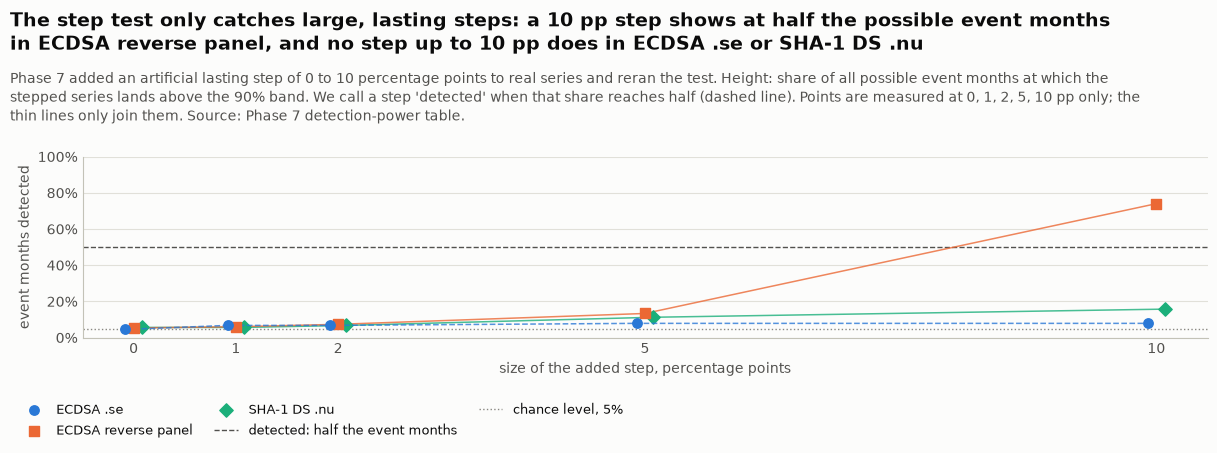

**How to read it.** Each line is one real series, measured only at the marked points; where two lines overlap they are drawn slightly apart. With no step added, about 5% of event months land above the band, as they should. A test with good power would climb to 100% after a step of 1 or 2 pp. Here ECDSA .se reaches 8% at the largest step; ECDSA reverse panel reaches 74% at the largest step; SHA-1 DS .nu reaches 16% at the largest step, so ECDSA .se and SHA-1 DS .nu stay far below the detection line: the placebo months next to the event carry the same step and widen the band with it. There are two ways to state this power, and Phase 7 reports both. At one chosen event month, the smallest step detected is ECDSA .se: 1 pp; ECDSA reverse panel: 5 pp; SHA-1 DS .nu: 5 pp; across all possible event months (what the notebook calls 'detected'), ECDSA .se: not even 10 pp; ECDSA reverse panel: 10 pp; SHA-1 DS .nu: not even 10 pp. So 'inside the band' anywhere below means 'no lasting step larger than about 5 to 10 pp', and in volatile series not even that.

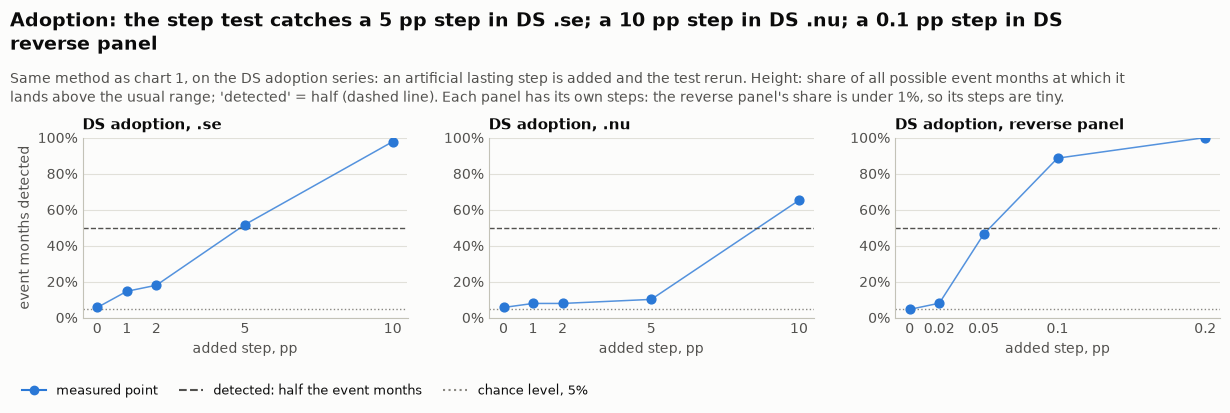

**How to read it.** The same test as chart 1, run on the share of domains with a DS record. At one chosen event month the smallest step detected is DS adoption .se: 2 pp; DS adoption .nu: not even 10 pp; DS adoption reverse panel: 0.05 pp; across all possible event months DS adoption .se: 5 pp; DS adoption .nu: 10 pp; DS adoption reverse panel: 0.1 pp. On the reverse panel, where under 1% of delegations are signed, a step of a tenth of a point is already large, and the test sees it; in the forward TLDs, where about half the domains are signed and the lines jump when the measured zone list changes, only steps of several points are caught, and in .nu not even 10.

In [6]:
say(f'''
> **Adoption and feature use, never mixed.** **Adoption** is {ADOPT_DEF} (the team's definition; also called
> prevalence). **Feature use** is a share *among signed zones*: which algorithm, DS digest or NSEC3 setting they use.
> A default change such as "sign with ECDSA" can change feature use without changing adoption at all. Section 2b tests
> adoption; sections 3 to 6 test feature use unless they say otherwise.
>
> **Unusual.** A result is *unusual* when the move after an event is bigger, up or down, than after 9 of 10 random
> months (for a default change) or 9 of 10 shifted copies of the release schedule (for a program). The charts shade
> the usual range, and with no effect at all about 1 test in 10 is unusual anyway.
>
> **Two corpora, never mixed.**
>
> * **Forward** means OpenINTEL's daily scans of whole TLD zone files: {fwd_coverage_text()} A forward monthly
>   share is the **mean daily share**: summed
>   daily numerator counts over summed daily denominator counts.
> * **Reverse** means the RIR reverse-DNS zones (`in-addr.arpa`). Every reverse share uses the **strict panel**,
>   AFRINIC and ARIN pooled (`_pooled-afrinic-arin`), from {PANEL_START}, when it first held signed delegations. A reverse
>   month label M is the zone state at **00:00 UTC on the 1st of M**, so a change between labels M-1 and M happened
>   during calendar month M-1. Every chart that marks a release against reverse data follows this rule.
>
> **Denominators.** An algorithm share is out of *signed* zones (forward: zones serving a DNSKEY) or of *DS-carrying*
> delegations (reverse). A digest share is out of DS-carrying zones. An NSEC3 iteration share is out of NSEC3
> *owner names*, not zones. The DS, DNSKEY and RRSIG shares of section 2 are out of all delegated zones.
>
> **The step test ("departure from trend").** It asks "did the share jump after the event and stay there?" A
> straight line is fitted to the {PRE} months *before* the event and extended over the {POST} months *after*; the
> statistic is the average gap, in percentage points (pp), between what happened and what the line predicted.
> **It only detects steps above a certain size**, and a larger one in noisy series; {('chart 1 below gives the sizes for feature use and chart 2 for adoption' + (': for adoption, ' + PPW_TEXT if PPW_TEXT else '')) if POWER else 'this run of Phase 7 exports no detection-power table, and the second Phase 7 verification found that a 1 pp step was not detected and 5 to 10 pp steps only in quiet series'}.
>
> **Chance band.** To judge a gap, the same statistic is computed at {DRAWS:,} placebo dates: for a default change,
> random months of the same series; for a program's release schedule, the whole schedule shifted in time. The
> **90% chance band** holds the middle 90% of those placebo values. By chance alone about one test in ten lands
> outside it, so the text under every chart gives **how many fell outside against how many chance predicts**.
>
> **Percentile.** A percentile of 97 means the real value is larger than 97% of the placebo values. About 5 or less,
> or about 95 or more, is outside the band; the exact edge is the placebo values' own 5th and 95th percentile, so a
> value printed as 5.0 can fall on either side of it (the dot colour shows which).
>
> **Action size** (section 5 only): how many reverse delegations changed the same way in the same month and address
> block. It is only a proxy for "automatic".
''')
if POWER:
    path, tab = POWER
    rows = pd.DataFrame(tab.get("rows", []) if isinstance(tab, dict) else tab)
    need = {"series", "step_pp", "share_of_event_months_above_band"}
    if len(rows) and need <= set(rows.columns):
        pan = [k for k, v in PW_ALL.items() if v is not None]
        rest = [k for k, v in PW_ALL.items() if v is None]
        ttl_ = ("The step test only catches large, lasting steps: "
                + (" and ".join(f"a {PW_ALL[k]:g} pp step shows at half the possible event months in {pnice(k)}" for k in pan)
                   or "no step up to 10 pp shows at half the event months in any series")
                + ("" if not rest or not pan else f", and no step up to 10 pp does in {' or '.join(pnice(k) for k in rest)}"))
        fig, ax = plt.subplots(figsize=(12.5, 4.6))
        frame(fig, ttl_,
              "Phase 7 added an artificial lasting step of 0 to 10 percentage points to real series and reran the test. "
              "Height: share of all possible event months at which the stepped series lands above the 90% band. We call "
              "a step 'detected' when that share reaches half (dashed line). Points are measured at "
              + ", ".join(f"{v:g}" for v in sorted(rows.step_pp.unique())) + " pp only; the thin lines only join them. "
              "Source: Phase 7 detection-power table.", bottom=1.2, right=0.97)
        styles = [(S1, "o", "--", 4), (S2, "s", "-", 3), (S3, "D", "-", 2)]
        order_ = list(rows.series.unique())[:3]
        for k, ser in enumerate(order_):
            gdf = rows[rows.series == ser].sort_values("step_pp")
            col, mk, ls, z = styles[k]
            off = (k - 1) * 0.08       # small horizontal offset so overlapping lines stay visible
            ax.plot(gdf.step_pp + off, gdf.share_of_event_months_above_band * 100, color=col, lw=1.1, ls=ls, zorder=z,
                    alpha=0.8)
            ax.scatter(gdf.step_pp + off, gdf.share_of_event_months_above_band * 100, color=col, marker=mk, s=46,
                       zorder=z + 1, label=pnice(ser))
        ax.axhline(50, color=INK_2, ls="--", lw=1)
        ax.axhline(5, color=MUTED, ls=":", lw=1)
        ax.set_xlim(-0.5, rows.step_pp.max() + 0.5); ax.set_ylim(0, 100)
        ax.set_xticks(sorted(rows.step_pp.unique()))
        ax.set_xlabel("size of the added step, percentage points"); ax.set_ylabel("event months detected")
        pct_axis(ax); style(ax)
        legend_below(fig, ax.get_legend_handles_labels()[0] + [
            Line2D([], [], color=INK_2, ls="--", lw=1, label="detected: half the event months"),
            Line2D([], [], color=MUTED, ls=":", lw=1, label="chance level, 5%")], ncol=3)
        save(fig, "detection_power")
        top_ = rows.groupby("series").share_of_event_months_above_band.max() * 100
        low_ = [pnice(k) for k, v in top_.items() if v < 20]
        say("**How to read it.** Each line is one real series, measured only at the marked points; where two lines "
            "overlap they are drawn slightly apart. With no step added, about 5% of event months land above the band, "
            "as they should. A test with good power would climb to 100% after a step of 1 or 2 pp. Here "
            + "; ".join(f"{pnice(k)} reaches {v:.0f}% at the largest step" for k, v in top_.items())
            + (f", so {' and '.join(low_)} stay far below the detection line" if low_ else "")
            + ": the placebo months next to the event carry the same step and widen the band with it. There are two "
            "ways to state this power, and Phase 7 reports both. " + (PW_TEXT[0].upper() + PW_TEXT[1:] if PW_TEXT else "")
            + ". So 'inside the band' anywhere below means 'no lasting step larger than about 5 to 10 pp', and in "
            "volatile series not even that.")
    else:
        say(f"**Detection power**, from `{'/'.join(map(str, path))}` in the Phase 7 JSON:")
        display(rows)
if len(PPW_ROWS) and {"series", "step_pp", "share_of_event_months_above_band"} <= set(PPW_ROWS.columns):
    sers = list(PPW_ROWS.series.unique())
    fig, axes = plt.subplots(1, len(sers), figsize=(12.5, 4.2), squeeze=False)
    frame(fig, "Adoption: the step test catches " + "; ".join(
              f"{'no step up to ' + format(PPW_ROWS[PPW_ROWS.series == k].step_pp.max(), 'g') + ' pp' if v is None else f'a {v:g} pp step'}"
              f" in {pnice(k).replace('ds_prev ', 'DS ')}" for k, v in PPW_ALL.items()),
          "Same method as chart 1, on the DS adoption series: an artificial lasting step is added and the test rerun. "
          "Height: share of all possible event months at which it lands above the usual range; 'detected' = half "
          "(dashed line). Each panel has its own steps: the reverse panel's share is under 1%, so its steps are tiny.",
          bottom=1.0, wspace=0.25)
    for ax, ser in zip(axes[0], sers):
        g_ = PPW_ROWS[PPW_ROWS.series == ser].sort_values("step_pp")
        ax.plot(g_.step_pp, g_.share_of_event_months_above_band * 100, color=S1, lw=1.1, alpha=0.8)
        ax.scatter(g_.step_pp, g_.share_of_event_months_above_band * 100, color=S1, s=40, zorder=3)
        ax.axhline(50, color=INK_2, ls="--", lw=1); ax.axhline(5, color=MUTED, ls=":", lw=1)
        ax.set_xticks(list(g_.step_pp)); ax.set_xticklabels([f"{v:g}" for v in g_.step_pp])
        ax.set_ylim(0, 100); ax.set_title(pnice(ser).replace("ds_prev ", "DS adoption, "), loc="left", fontweight="bold")
        ax.set_xlabel("added step, pp"); pct_axis(ax); style(ax)
    axes[0][0].set_ylabel("event months detected")
    legend_below(fig, [Line2D([], [], marker="o", color=S1, label="measured point"),
                       Line2D([], [], color=INK_2, ls="--", label="detected: half the event months"),
                       Line2D([], [], color=MUTED, ls=":", label="chance level, 5%")], ncol=3)
    save(fig, "adoption_detection_power")
    k0 = next(iter(PPW_ALL), None)
    if k0 is not None:
        val("J7", "q2_default_change_events", "prevalence", "detection_power", "smallest_detectable_step_pp", k0)
    say("**How to read it.** The same test as chart 1, run on the share of domains with a DS record. "
        + (PPW_TEXT[0].upper() + PPW_TEXT[1:] + ". " if PPW_TEXT else "")
        + "On the reverse panel, where under 1% of delegations are signed, a step of a tenth of a point is already "
        "large, and the test sees it; in the forward TLDs, where about half the domains are signed and the lines jump "
        "when the measured zone list changes, only steps of several points are caught, and in .nu not even 10.")

## 2. The adoption series themselves

Everything later measures movement in these lines, so here they are first, with nothing else on them.

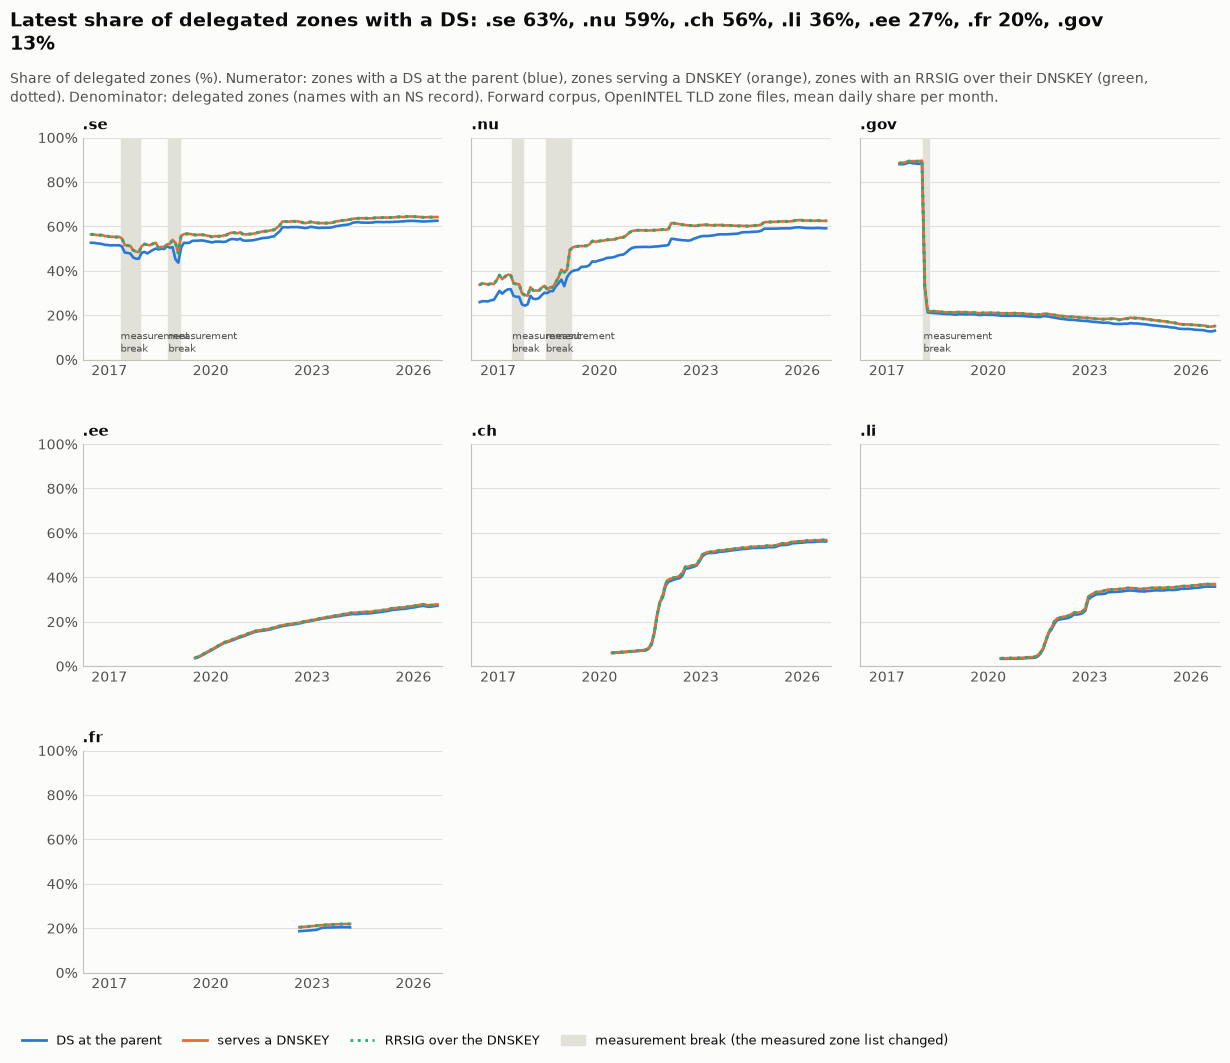

**How to read it.** Each panel is one TLD; each line is the percentage of that TLD's delegated zones that have the thing in the legend. Orange above blue means some zones serve keys without a DS at the parent (signed but not chained). The green dotted line sits on the orange one because every signed zone signs its own DNSKEY set; it is drawn to show that RRSIG adds no new information at zone level. In each TLD's last month the DS share is 62.5% in .se (2026-09), 59.2% in .nu (2026-09), 13.0% in .gov (2026-09), 27.2% in .ee (2026-09), 56.1% in .ch (2026-09), 35.8% in .li (2026-09) and 20.4% in .fr (2024-02).  **Measurement breaks** (shaded grey): .se 2017-05 to 2017-11: .se: denominator 1,326,434 in 2017-04 to 1,663,208 in 2017-11, +25%; DS share 51.5% to 45.5%; the DS count did not follow; .se 2018-10 to 2019-01: .se: denominator 1,621,745 in 2018-09 to 1,338,823 in 2019-01, -17%; DS share 51.0% to 43.7%; the DS count did not follow; .nu 2017-06 to 2017-09: .nu: denominator 281,539 in 2017-05 to 356,341 in 2017-09, +27%; DS share 31.8% to 24.9%; the DS count did not follow; .nu 2018-06 to 2019-02: .nu: denominator 454,465 in 2018-05 to 232,995 in 2019-02, -49%; DS share 30.1% to 39.0%; the DS count did not follow; .gov 2018-02 to 2018-03: .gov: denominator 1,234 in 2018-01 to 5,564 in 2018-03, +351%; DS share 88.7% to 21.3%; the DS count did not follow. In these months the list of zones being measured changed, so the shares moved without any domain being signed or unsigned; the largest month-to-month moves in these lines come from such denominator changes, not from adoption. First months measured on only part of the month: .se 2016-06 (24 days), .nu 2016-06 (24 days), .ee 2019-07 (3 days), .ch 2020-05 (13 days), .li 2020-05 (13 days) and .fr 2022-08 (22 days).

In [7]:
fwd = PREV[(PREV.corpus == "forward") & PREV.source.isin(TLDS)]
fig, axes = tld_grid(len(TLDS), 3, 12.5, 3.3, sharey=True)
_lastds = {t_: fwd[(fwd.source == t_) & (fwd.metric == "ds_share") & (fwd.month == FWD_SPAN[t_][1])].pct.iloc[0]
           for t_ in TLDS}
frame(fig, "Latest share of delegated zones with a DS: " + ", ".join(
          f"{SRC[t_]} {_lastds[t_]:.0f}%" for t_ in sorted(TLDS, key=lambda x: -_lastds[x])),
      "Share of delegated zones (%). Numerator: zones with a DS at the parent (blue), zones serving a DNSKEY "
      "(orange), zones with an RRSIG over their DNSKEY (green, dotted). Denominator: delegated zones (names with "
      "an NS record). Forward corpus, OpenINTEL TLD zone files, mean daily share per month.",
      bottom=0.95, hspace=0.38, wspace=0.08)
metric_style = [("ds_share", S1, "-", "DS at the parent"), ("dnskey_share", S2, "-", "serves a DNSKEY"),
                ("rrsig_zone_share", S3, ":", "RRSIG over the DNSKEY")]
for ax, tld in zip(axes.flat, TLDS):
    for b_ in BREAKS:
        if b_["source"] == tld:
            ax.axvspan(m2y(b_["first"], True), m2y(b_["last"], True) + 1 / 12, color=GRID, zorder=0)
            ax.text(m2y(b_["first"], True), 2, "measurement\nbreak", fontsize=7.5, color=INK_2, va="bottom", ha="left")
    for met, col, ls, _ in metric_style:
        s = fwd[(fwd.source == tld) & (fwd.metric == met)].sort_values("month")
        ax.plot([m2y(m) for m in s.month], s.pct, color=col, ls=ls, lw=1.9 if ls == "-" else 2.2)
    ax.set_title("." + tld, loc="left", fontweight="bold")
    ax.set_xlim(*FWD_XLIM)
    ax.set_ylim(0, 100)
    pct_axis(ax); year_axis(ax, 5); style(ax)
legend_below(fig, [Line2D([], [], color=c, ls=ls, lw=2, label=l) for _, c, ls, l in metric_style]
             + ([Patch(color=GRID, label="measurement break (the measured zone list changed)")] if BREAKS else []),
             ncol=4 if BREAKS else 3)
save(fig, "forward_ds_dnskey_rrsig")
say("**How to read it.** Each panel is one TLD; each line is the percentage of that TLD's delegated zones "
    "that have the thing in the legend. Orange above blue means some zones serve keys without a DS at the parent "
    "(signed but not chained). The green dotted line sits on the orange one because every signed zone signs its "
    "own DNSKEY set; it is drawn to show that RRSIG adds no new information at zone level. "
    "In each TLD's last month the DS share is " + _join([f"{_lastds[t_]:.1f}% in {SRC[t_]} ({FWD_SPAN[t_][1]})"
                                                         for t_ in TLDS]) + ". "
    + (" **Measurement breaks** (shaded grey): " + "; ".join(
        f"{SRC.get(b_['source'], b_['source'])} {b_['first']} to {b_['last']}: {b_['description']}" for b_ in BREAKS)
       + ". In these months the list of zones being measured changed, so the shares moved without any domain being "
       "signed or unsigned; the largest month-to-month moves in these lines come from such denominator changes, not "
       "from adoption. " if BREAKS else
       "The .gov drop in early 2018 is the scanned zone list growing from about 1,200 to 5,600 zones, not signing "
       "collapsing. ") + (("First months measured on only part of the month: " + _join(
        [f"{SRC[t_]} {FWD_SPAN[t_][0]} ({int(_md)} days)" for t_ in TLDS
         for _md in [_fw[(_fw.source == t_) & (_fw.month == FWD_SPAN[t_][0])].measured_days.max()]
         if _md < pd.Period(FWD_SPAN[t_][0], freq="M").days_in_month - 1]) + ".")
        if any(_fw[(_fw.source == t_) & (_fw.month == FWD_SPAN[t_][0])].measured_days.max()
               < pd.Period(FWD_SPAN[t_][0], freq="M").days_in_month - 1 for t_ in TLDS) else ""))

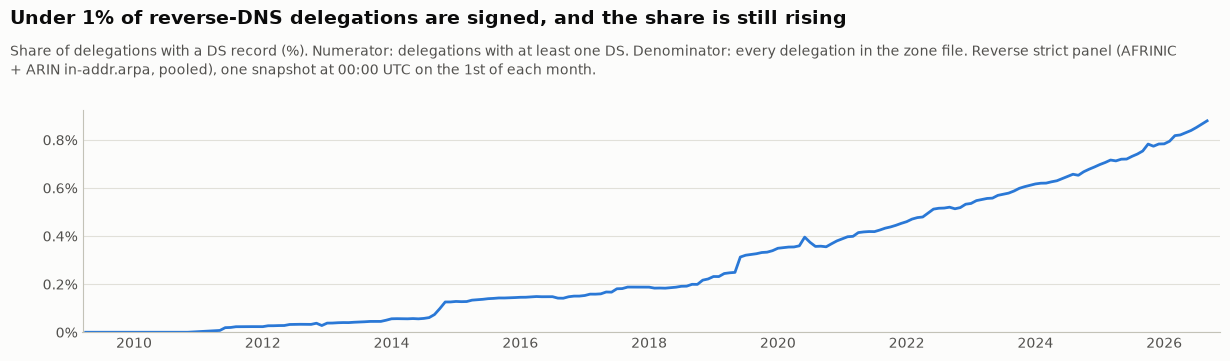

**How to read it.** One line: the percentage of reverse delegations on the strict panel that carry a DS. It reaches 0.879% in 2026-09 (6,546 of 744,492 delegations). DNSKEY and RRSIG cannot be measured here: a reverse parent zone holds only NS, DS and glue. Because so few delegations are signed, the algorithm and digest shares later on are shares of these few thousand signed delegations, not of all delegations.

In [8]:
rp = PREV[(PREV.corpus == "reverse_panel") & (PREV.source == PANEL) & (PREV.metric == "ds_share")].sort_values("month")
fig, ax = plt.subplots(figsize=(12.5, 3.8))
frame(fig, "Under 1% of reverse-DNS delegations are signed, and the share is still rising",
      "Share of delegations with a DS record (%). Numerator: delegations with at least one DS. Denominator: every "
      "delegation in the zone file. Reverse strict panel (AFRINIC + ARIN in-addr.arpa, pooled), one snapshot "
      "at 00:00 UTC on the 1st of each month.", bottom=0.45)
x = [m2y(m, start=True) for m in rp.month]
ax.plot(x, rp.pct, color=S1, lw=2)
ax.set_xlim(2009.2, PANEL_XLIM[1]); ax.set_ylim(0, None)
pct_axis(ax); year_axis(ax, 10); style(ax)
save(fig, "reverse_panel_ds_share")
r_last = rp.iloc[-1]
say("**How to read it.** One line: the percentage of reverse delegations on the strict panel that carry a DS. "
    f"It reaches {r_last.pct:.3f}% in {r_last.month} ({int(r_last.numerator):,} of {int(r_last.denominator):,} "
    "delegations). DNSKEY and RRSIG cannot be measured here: a reverse parent zone holds only NS, DS and glue. "
    "Because so few delegations are signed, the algorithm and digest shares later on are shares of these few "
    "thousand signed delegations, not of all delegations.")

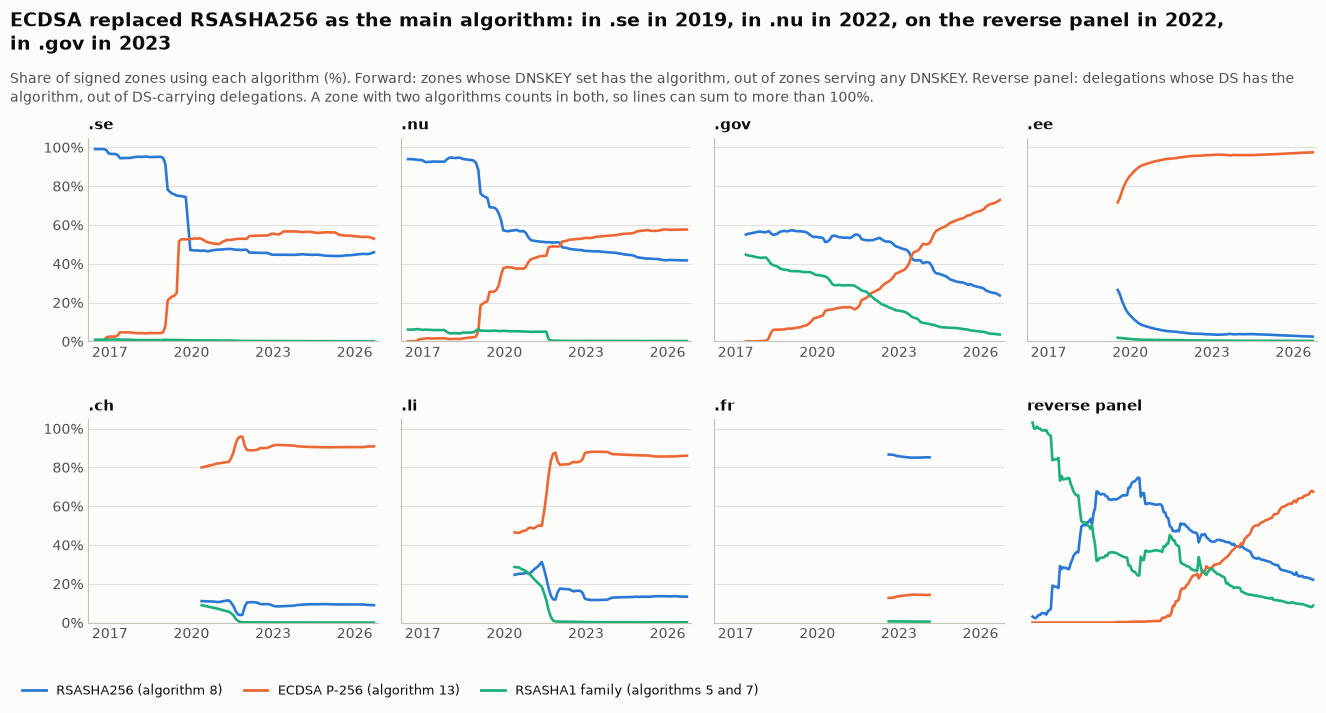

**How to read it.** Each panel is one corpus. Blue is the old RSA-with-SHA-256 algorithm, orange the newer ECDSA, green the deprecated RSA-with-SHA-1 family. Orange stays above blue from 2019-12 in .se, 2022-02 in .nu, 2022-09 in reverse panel, 2023-06 in .gov; it is already above when the corpus starts in .ee, .ch, .li. In .se, .nu and .ch the switch happens in a few large steps, which is consistent with a few large operators re-signing many zones at once; the zone files do not record who signed, so this cannot be confirmed. The reverse panel (bottom right, note its longer time axis) has a much slower, smoother move. The panel's RSASHA1 line starts slightly above 100% (103% in 2011-05) because a delegation carrying both algorithm 5 and algorithm 7 DS records counts once in each; the panel then held at most 100 signed delegations. These are the lines the release and default-change tests in section 3 look for bends in.

In [9]:
_s57, _, _d57 = series_full("alg5_7", PANEL)
_over = _s57[_s57 > 100].dropna()
RSA_NOTE = ("" if _over.empty else
            f"The panel's RSASHA1 line starts slightly above 100% ({_over.max():.0f}% in {_over.idxmax()}) because a "
            "delegation carrying both algorithm 5 and algorithm 7 DS records counts once in each; the panel then held "
            f"at most {int(_d57[_over.index].max()):,} signed delegations.")
ALG = [("alg8", S1, "RSASHA256 (algorithm 8)"), ("alg13", S2, "ECDSA P-256 (algorithm 13)"),
       ("alg5_7", S3, "RSASHA1 family (algorithms 5 and 7)")]
def crossover(src):
    # first month from which the ECDSA share stays above the RSASHA256 share; None if never; "start" if from the start
    a8, a13 = series("alg8", src), series("alg13", src)
    if a8 is None or a13 is None:
        return None
    d = (a13 - a8).dropna()
    if d.empty or (d <= 0).iloc[-1]:
        return None
    last_below = d[d <= 0].index.max() if (d <= 0).any() else None
    if last_below is None:
        return "start"
    return d.index[d.index > last_below][0]


XO = {src: crossover(src) for src in TLDS + [PANEL]}
xo_dated = sorted(((m, src) for src, m in XO.items() if m not in (None, "start")), key=lambda t: t[0])
fig, axes = tld_grid(len(TLDS) + 1, 4, 13.5, 3.2, sharey=True)
frame(fig, "ECDSA replaced RSASHA256 as the main algorithm: " + ", ".join(
          f"{'on the ' if src == PANEL else 'in '}{SRC[src]} in {m[:4]}" for m, src in xo_dated),
      "Share of signed zones using each algorithm (%). Forward: zones whose DNSKEY set has the algorithm, out of "
      "zones serving any DNSKEY. Reverse panel: delegations whose DS has the algorithm, out of DS-carrying "
      "delegations. A zone with two algorithms counts in both, so lines can sum to more than 100%.",
      bottom=0.95, hspace=0.38, wspace=0.08)
for ax, src in zip(axes.flat, TLDS + [PANEL]):
    for obs, col, _ in ALG:
        s = series(obs, src)
        if s is None:
            continue
        s = s.dropna()
        ax.plot([m2y(m, start=(src == PANEL)) for m in s.index], s.values, color=col, lw=1.9)
    ax.set_title(SRC[src], loc="left", fontweight="bold")
    ax.set_xlim(PANEL_XLIM if src == PANEL else FWD_XLIM)
    ax.set_ylim(0, 105)
    pct_axis(ax); year_axis(ax, 5); style(ax)
axes.flat[-1].axis("off")
legend_below(fig, [Line2D([], [], color=c, lw=2, label=l) for _, c, l in ALG])
save(fig, "algorithm_shares")
say("**How to read it.** Each panel is one corpus. Blue is the old RSA-with-SHA-256 algorithm, orange the newer "
    "ECDSA, green the deprecated RSA-with-SHA-1 family. Orange stays above blue from "
    + ", ".join(f"{m} in {SRC[src]}" for m, src in xo_dated)
    + (("; it is already above when the corpus starts in " + ", ".join(SRC[k] for k, v in XO.items() if v == "start"))
       if any(v == "start" for v in XO.values()) else "")
    + ". In .se, .nu and .ch the switch happens in a few large steps, which is consistent with a few large operators "
    "re-signing many zones at once; the zone files do not record who signed, so this cannot be confirmed. "
    "The reverse panel (bottom right, note its longer time axis) has a much slower, smoother move. "
    + RSA_NOTE + " "
    "These are the lines the release and default-change tests in section 3 look for bends in.")

## 2b. Adoption: does software change how many domains are signed?

Here adoption is the team's measure, the % of domains with at least one DS, DNSKEY or RRSIG record: the lines of the
first chart in section 2 (and, for the reverse panel, DS only, because a reverse zone file holds no DNSKEY or RRSIG).
The tests are the same as for feature use: does the line leave its own trend after a program's releases, or after a
default change that could change whether zones get signed? A result is **unusual** when the move is bigger than after
9 of 10 random months or shifted release schedules. DS, DNSKEY and RRSIG move almost together, so one real movement
usually shows up as two or three unusual tests; the headline counts therefore count each program and corpus once, on
DS.

In [10]:
say("**Measurement breaks.** " + ("; ".join(f"{SRC.get(b_['source'], b_['source'])} {b_['first']} to {b_['last']}"
                                           for b_ in BREAKS) if BREAKS else NA)
    + ". In these months the list of zones being measured changed ("
    + "; ".join(f"{SRC.get(b_['source'], b_['source'])} {b_['first'][:4]}: "
                f"{'grew' if b_.get('denominator_change', 0) > 0 else 'shrank'} "
                f"{abs(b_.get('denominator_change', 0)):.0%}" for b_ in BREAKS)
    + "), so the adoption share jumped or dipped without any domain being signed. A test whose "
    "window crosses such a break can look unusual for that reason alone. Phase 7 therefore reruns every test with the "
    "break months left out; both versions are given below.")

**Measurement breaks.** .se 2017-05 to 2017-11; .se 2018-10 to 2019-01; .nu 2017-06 to 2017-09; .nu 2018-06 to 2019-02; .gov 2018-02 to 2018-03. In these months the list of zones being measured changed (.se 2017: grew 25%; .se 2018: shrank 17%; .nu 2017: grew 27%; .nu 2018: shrank 49%; .gov 2018: grew 351%), so the adoption share jumped or dipped without any domain being signed. A test whose window crosses such a break can look unusual for that reason alone. Phase 7 therefore reruns every test with the break months left out; both versions are given below.

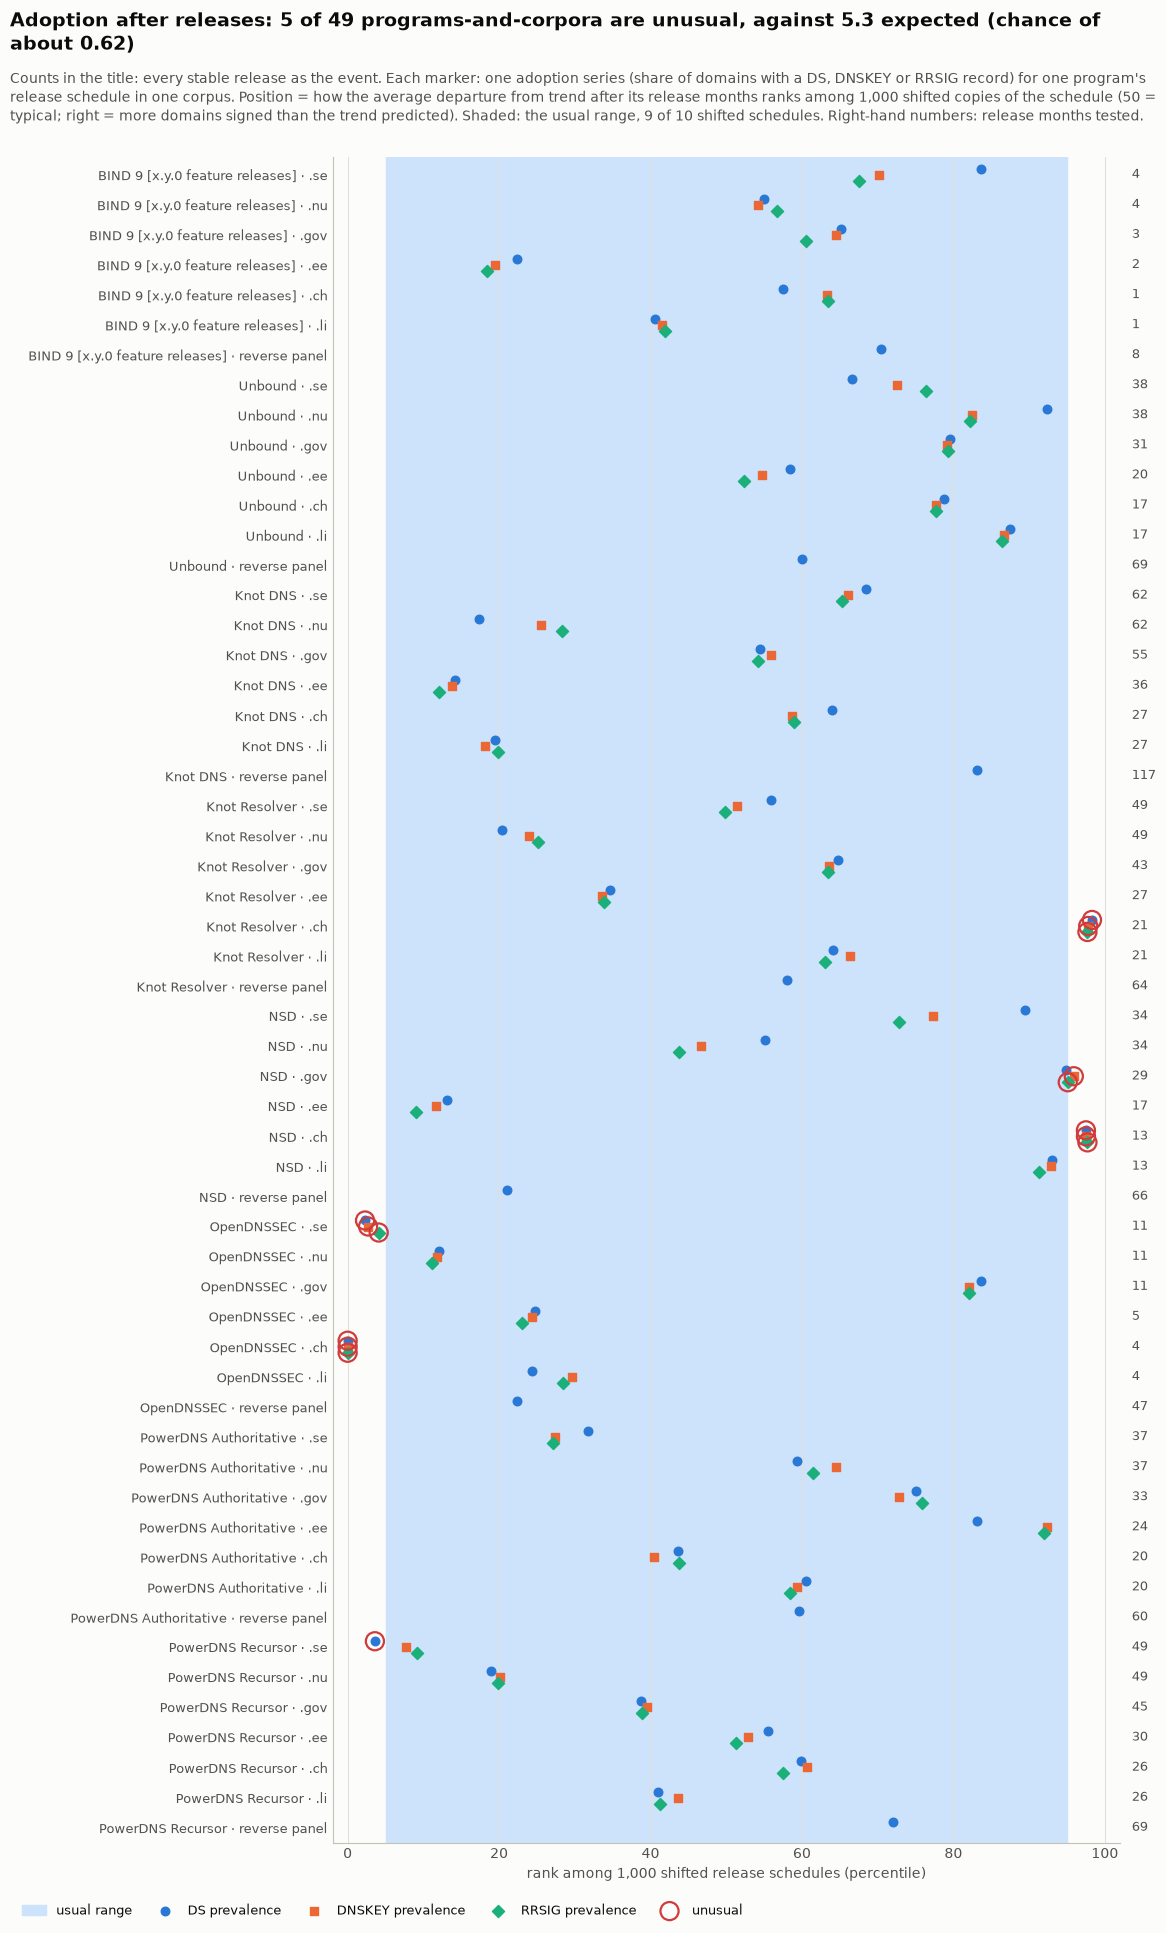

**How to read it.** Each row is one program in one corpus; the three markers are its DS, DNSKEY and RRSIG adoption lines, which move almost together. A red ring marks an unusual result. Per test (secondary): 15 of 133 are unusual; treated as independent tests that would look borderline (chance about 0.47), but the unusual results are only 6 movements: Knot Resolver in .ch (DNSKEY, DS, RRSIG; more domains signed than predicted, over 21 release months); NSD in .ch (DNSKEY, DS, RRSIG; more domains signed than predicted, over 13 release months); NSD in .gov (DNSKEY, RRSIG; more domains signed than predicted, over 29 release months); OpenDNSSEC in .ch (DNSKEY, DS, RRSIG; fewer domains signed than predicted, over 4 release months); OpenDNSSEC in .se (DNSKEY, DS, RRSIG; fewer domains signed than predicted, over 11 release months); PowerDNS Recursor in .se (DS; fewer domains signed than predicted, over 49 release months). Their directions disagree, so they do not add up to 'releases raise adoption'. Counted once per program and corpus, on DS (Phase 7's headline): 5 of 49 against 5.3 expected (a chance of about 0.62); without .gov 5 of 42 against 4.5 expected (a chance of about 0.48); with the break months left out 4 of 49 against 5.3 expected (a chance of about 0.79), with a different set of unusual pairs (kresd .ch, kresd .se, nsd .ch, opendnssec .ch). Pairs in a corpus with a measurement break: opendnssec .se, pdns-rec .se. BIND 9's x.y.0 feature releases, shown separately: 0 of 19 unusual. Not tested (46 cells, besides .fed.us): 27 because the series is too short; 19 because releases fill more than 75% of the testable window.

In [11]:
t = Q1P[is_step(Q1P) & (Q1P.status == "tested") & (Q1P.source != "fed.us")].copy()
if t.empty:
    say(f"**Release schedules against adoption:** {NA}.")
else:
    t["es"] = es_of(t)
    order_p = {p_: i for i, p_ in enumerate(NAME)}
    t["pair"] = [f"{NAME[p_]}{es_label(e_)} · {SRC[s_]}" for p_, e_, s_ in zip(t.program, t.es, t.source)]
    t["k"] = [(order_p.get(p_, 99), e_, TLDS.index(s_) if s_ in TLDS else 99) for p_, e_, s_ in
              zip(t.program, t.es, t.source)]
    pairs = sorted(t.pair.unique(), key=lambda x: t[t.pair == x].k.iloc[0])
    ypos = {p_: i for i, p_ in enumerate(pairs)}
    ta = t[t.es == ALL_REL]             # the headline count: every stable release; BIND 9 x.y.0 is reported apart
    n_, o_ = len(ta), int(ta.beats_chance_mean.astype(bool).sum())
    u_ = ta[ta.beats_chance_mean.astype(bool)]
    tb = t[t.es != ALL_REL]
    bxt = (f" BIND 9's x.y.0 feature releases, shown separately: {int(tb.beats_chance_mean.astype(bool).sum())} of "
           f"{len(tb)} unusual." if len(tb) else "")
    exp_ = jget(J7, "q1_per_program_releases", "prevalence", "aggregate", "step12", "expected_by_calibrated_rate")
    fig, ax = plt.subplots(figsize=(12.5, max(4.0, 2.6 + 0.30 * len(pairs))))
    uq = unit(UQ1, "step12")
    frame(fig, (f"Adoption after releases: {uq['outside_90pct_null']} of {uq['units']} programs-and-corpora are "
                f"unusual, against {uq['expected']:.1f} expected (chance of about {uq['p_at_least_observed']:.2f})"
                if uq else f"Adoption after releases: {o_} of {n_} tests are unusual"),
          "Counts in the title: every stable release as the event. Each marker: one adoption series (share of domains "
          "with a DS, DNSKEY or RRSIG record) for one program's release "
          "schedule in one corpus. Position = how the average departure from trend after its release months ranks among "
          f"{DRAWS:,} shifted copies of the schedule (50 = typical; right = more domains signed than the trend "
          "predicted). Shaded: the usual range, 9 of 10 shifted schedules. Right-hand numbers: release months tested.",
          bottom=0.95, left=0.27, right=0.90)
    ax.axvspan(5, 95, color=RAMP[0], zorder=0)
    mk = {"ds_prev": ("o", S1, -0.2), "dnskey_prev": ("s", S2, 0.0), "rrsig_prev": ("D", S3, 0.2)}
    for obs, (m_, c_, dy) in mk.items():
        g_ = t[t.observable == obs]
        ax.scatter(g_.percentile, [ypos[p_] + dy for p_ in g_.pair], marker=m_, color=c_, s=38, zorder=3,
                   label=f"{PNAME[obs]} prevalence")
    uu_ = t[t.beats_chance_mean.astype(bool)]
    ax.scatter(uu_.percentile, [ypos[p_] + mk[o][2] for p_, o in zip(uu_.pair, uu_.observable)], s=170,
               facecolor="none", edgecolor=RED, lw=1.6, zorder=4, label="unusual")
    for p_ in pairs:
        ax.text(1.015, ypos[p_], f"{int(t[t.pair == p_].release_months_tested.max())}",
                transform=ax.get_yaxis_transform(), va="center", fontsize=9, color=INK_2)
    ax.set_yticks(range(len(pairs))); ax.set_yticklabels(pairs, fontsize=9)
    ax.set_xlim(-2, 102); ax.set_ylim(len(pairs) - 0.5, -0.6)
    ax.set_xlabel(f"rank among {DRAWS:,} shifted release schedules (percentile)")
    style(ax, grid="x")
    h_, l_ = ax.get_legend_handles_labels()
    legend_below(fig, [Patch(color=RAMP[0], label="usual range")] + h_, ncol=5)
    save(fig, "adoption_release_tests")
    grp = u_.groupby(["program", "source"])
    lines = []
    for (p_, s_), g_ in grp:
        lines.append(f"{NAME[p_]} in {SRC[s_]} ({', '.join(PNAME[o] for o in g_.observable)}; "
                     f"{'more' if g_.percentile.median() > 50 else 'fewer'} domains signed than predicted, over "
                     f"{int(g_.release_months_tested.max())} release months)")
    un = Q1P[is_step(Q1P) & (Q1P.status != "tested") & (Q1P.source != "fed.us")]
    c_ = reason_counts(un)
    tail_ = binom_tail(o_, n_, (exp_ or 0.1 * n_) / n_)
    say("**How to read it.** Each row is one program in one corpus; the three markers are its DS, DNSKEY and RRSIG "
        "adoption lines, which move almost together. A red ring marks an unusual result. "
        f"Per test (secondary): {o_} of {n_} are unusual; treated as independent tests that would look borderline "
        f"(chance about {tail_:.2f}), but the unusual results are only {grp.ngroups} movements: "
        + "; ".join(lines) + ". Their directions disagree, so they do not add up to 'releases raise adoption'."
        + (f" Counted once per program and corpus, on DS (Phase 7's headline): {unit_txt(unit(UQ1, 'step12'), 'outside_90pct_null')}; "
           f"without .gov {unit_txt(unit(UQ1, 'step12_without_gov'), 'outside_90pct_null')}; with the break months left "
           f"out {unit_txt(unit(UQ1, 'step12_breaks_masked'), 'outside_90pct_null')}, with a different set of unusual "
           f"pairs ({', '.join((unit(UQ1, 'step12_breaks_masked') or {}).get('units_outside', []))}).")
        + (f" Pairs in a corpus with a measurement break: {', '.join(x for x in (uq or {}).get('units_outside', []) if x.split(' ')[-1].lstrip('.') in BREAK_SRC)}."
           if uq else "")
        + bxt + " "
        + (f"Not tested ({len(un)} cells, besides .fed.us): " + "; ".join(
            f"{v} because {k}" for k, v in sorted(c_.items(), key=lambda kv: -kv[1])) + "." if len(un) else ""))

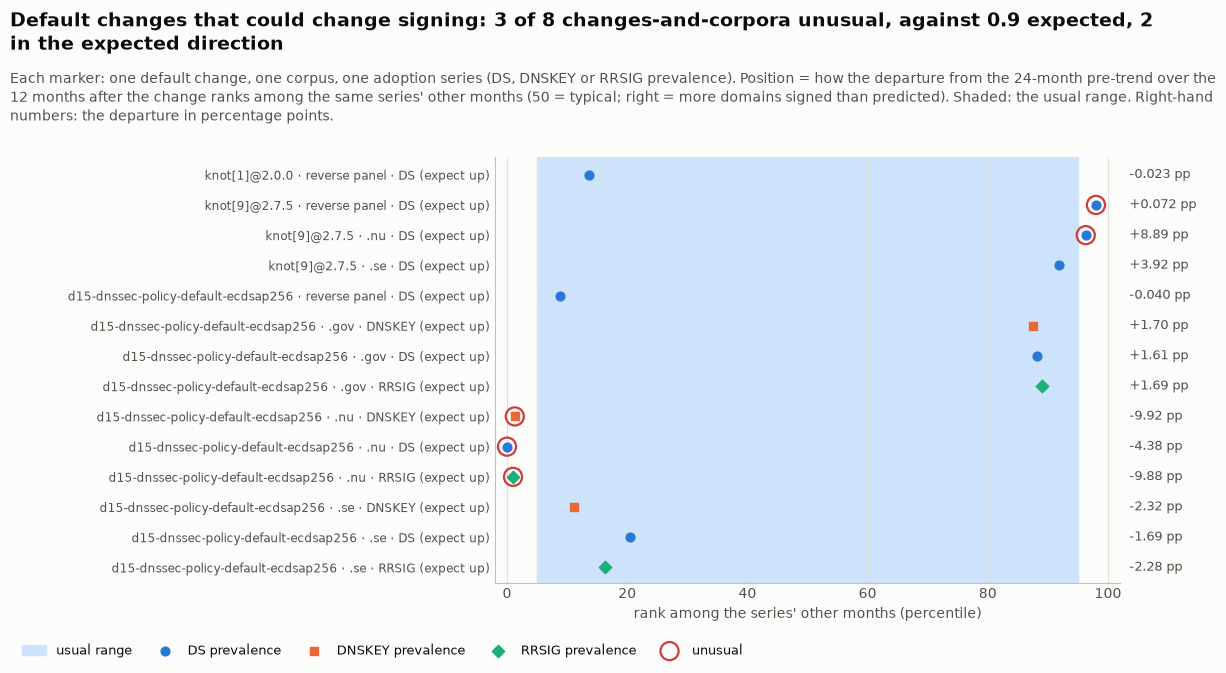

**How to read it.** A marker far right means more domains were signed after the change than the trend predicted; far left, fewer. Counted once per change and corpus (Phase 7's headline): 3 of 8 against 0.9 expected (a chance of about 0.05) (d15-dnssec-policy-default-ecdsap256 .nu ds_prev, knot[9]@2.7.5 panel ds_prev, knot[9]@2.7.5 .nu ds_prev); without .gov 3 of 7 against 0.8 expected (a chance of about 0.04); with the break months left out only 3 can still be tested, 1 of 3 against 0.3 expected (a chance of about 0.31). Per test (secondary): 5 of 14. Unusual results by default change: d15-dnssec-policy-default-ecdsap256: 3 test(s), 3 against the expected direction (.nu); knot[9]@2.7.5: 2 test(s), 0 against the expected direction (.nu, reverse panel). A pre-trend that was already rising steeply can make an ordinary year after it look like a fall, so a result against the expected direction says more about the trend than about the default.

**Which default changes count here, and why.** Phase 7 read every default change and kept only those that could change whether a zone gets signed, gets a DS at its parent, or is served with its DNSSEC records:

* **d15-dnssec-policy-default-ecdsap256** (BIND 9, 2020-02-12; DS, DNSKEY, RRSIG, expected up): built-in dnssec-policy 'default' makes signing a one-line configuration with automatic key management. 10 step tests.
* **knot[1]@2.0.0** (Knot DNS, 2015-06-26; DS, DNSKEY, RRSIG, expected up): first built-in KASP policy: Knot generates and manages keys itself instead of needing keys made with another tool. 1 step test.
* **knot[9]@2.7.5** (Knot DNS, 2019-01-07; DS, expected up): a keymgr-generated KSK is ready at once, so DS submission can proceed immediately; a weak effect, only for KSKs made by hand with keymgr. 3 step tests.
* **nsd[0]@2.0.0** (NSD, 2004-02-12; RRSIG, expected up): DNSSEC answer composition compiled in by default: RRSIGs are added to answers for DO queries. no step test (no before-period: series valid from 2016-06, needs 2002-02).
* **nsd[1]@2.2.0** (NSD, 2005-01-10; RRSIG, expected down): DNSSEC compiled out by default on trunk. no step test (no before-period: series valid from 2016-06, needs 2003-01).
* **nsd[2]@2.3.0** (NSD, 2005-05-02; RRSIG, expected up): DNSSEC compiled in by default again. no step test (no before-period: series valid from 2016-06, needs 2003-05).
* **nsd[5]@3.2.6** (NSD, 2010-07-20; RRSIG, expected up): --disable-dnssec removed: every NSD build serves DNSSEC. no step test (no before-period: series valid from 2016-06, needs 2008-07).

Left out: 147 rows, of which 79 validator-only rows (validation defaults, trust anchors, validator limits: they do not change what zones publish); 39 rows that change a parameter of zones that are signed anyway (algorithm, digest, key size, NSEC3, timing); 8 rows where a default makes some configurations fail to sign (one rule excludes the whole class); and 21 rows read one by one (for example a change of the default algorithm of a key the operator still has to ask for). The full list is in `software_vs_adoption_prevalence_excluded.csv`.

**Sudden jumps.** Phase 7 also looked for months in which the number of signed domains jumps or drops sharply: 3 of 59 sudden jumps or drops in the number of signed domains follow a default change that could cause them within 3 months, against 2.5 expected; leaving out the 2 jumps that only undo a one-month dip, 2 of 57 against 2.3. No kind of jump lines up more often than chance.

In [12]:
st = Q2P[(Q2P.test == "step12") & (Q2P.status == "tested")].copy()
if st.empty:
    say(f"**Default changes against adoption:** {NA}.")
else:
    st["lab"] = [f"{r.row_id} · {SRC[r.source]} · {PNAME[r.observable]} (expect {'up' if r.expected_direction > 0 else 'down'})"
                 for r in st.itertuples()]
    st = st.sort_values(["timing_date", "row_id", "source", "observable"])
    n_ = len(st)
    u_ = st[st.outside_90_band.astype(bool)]
    e_ = jget(J7, "q2_default_change_events", "prevalence", "summary", "step12", "expected_outside_discrete")
    fig, ax = plt.subplots(figsize=(12.5, max(4.0, 2.6 + 0.30 * n_)))
    uq2 = unit(UQ2, "step12")
    frame(fig, (f"Default changes that could change signing: {uq2['outside_90_band']} of {uq2['units']} changes-and-corpora "
                f"unusual, against {uq2['expected_discrete']:.1f} expected, {uq2['in_expected_direction']} in the expected "
                "direction" if uq2 else f"Default changes that could change signing: {len(u_)} of {n_} tests unusual"),
          "Each marker: one default change, one corpus, one adoption series (DS, DNSKEY or RRSIG prevalence). Position = "
          f"how the departure from the {PRE}-month pre-trend over the {POST} months after the change ranks among the "
          "same series' other months (50 = typical; right = more domains signed than predicted). Shaded: the usual "
          "range. Right-hand numbers: the departure in percentage points.", bottom=0.95, left=0.40, right=0.90)
    y = np.arange(n_)
    ax.axvspan(5, 95, color=RAMP[0], zorder=0)
    mk = {"ds_prev": ("o", S1), "dnskey_prev": ("s", S2), "rrsig_prev": ("D", S3)}
    for obs, (m_, c_) in mk.items():
        sel = (st.observable == obs).values
        ax.scatter(st.percentile[sel], y[sel], marker=m_, color=c_, s=40, zorder=3, label=f"{PNAME[obs]} prevalence")
    sel = st.outside_90_band.astype(bool).values
    ax.scatter(st.percentile[sel], y[sel], s=170, facecolor="none", edgecolor=RED, lw=1.6, zorder=4, label="unusual")
    for yi, r in zip(y, st.itertuples()):
        ax.text(1.015, yi, pp(r.observed), transform=ax.get_yaxis_transform(), va="center", fontsize=9, color=INK_2)
    ax.set_yticks(y); ax.set_yticklabels(st.lab, fontsize=8.8)
    ax.set_xlim(-2, 102); ax.set_ylim(n_ - 0.5, -0.6)
    ax.set_xlabel("rank among the series' other months (percentile)")
    style(ax, grid="x")
    h_, l_ = ax.get_legend_handles_labels()
    legend_below(fig, [Patch(color=RAMP[0], label="usual range")] + h_, ncol=5)
    save(fig, "adoption_default_changes")
    by_row = u_.groupby("row_id")
    say("**How to read it.** A marker far right means more domains were signed after the change than the trend "
        "predicted; far left, fewer. "
        + f"Counted once per change and corpus (Phase 7's headline): {unit_txt(uq2, 'outside_90_band')}"
        + (f" ({', '.join(uq2['units_outside'])})" if uq2 and uq2.get('units_outside') else "")
        + f"; without .gov {unit_txt(unit(UQ2, 'step12_without_gov'), 'outside_90_band')}; with the break months left "
        f"out only {(unit(UQ2, 'step12_breaks_masked') or {}).get('units', NA)} can still be tested, "
        f"{unit_txt(unit(UQ2, 'step12_breaks_masked'), 'outside_90_band')}. "
        + f"Per test (secondary): {len(u_)} of {n_}. Unusual results by default change: "
        + ("; ".join(f"{rid}: {len(g_)} test(s), {int((~g_.in_expected_direction.astype(bool)).sum())} against the "
                     f"expected direction ({', '.join(sorted({SRC[x] for x in g_.source}))})" for rid, g_ in by_row)
           if len(u_) else "none")
        + ". A pre-trend that was already rising steeply can make an ordinary year after it look like a fall, so a "
        "result against the expected direction says more about the trend than about the default.")

# why these rows: the mapping, row by row, from Phase 7's prevalence mapping
inc = PMAP.drop_duplicates("row_id") if len(PMAP) else PMAP
lines = []
for r in inc.itertuples():
    obs_ = ", ".join(PNAME.get(o, o) for o in PMAP[PMAP.row_id == r.row_id].observable)
    tested = len(Q2P[(Q2P.row_id == r.row_id) & (Q2P.test == "step12") & (Q2P.status == "tested")])
    note = f"{tested} step test{'s' if tested != 1 else ''}" if tested else "no step test (" + (
        Q2P[(Q2P.row_id == r.row_id) & (Q2P.test == "step12")].reason.dropna().astype(str).str.split(" in ").str[0]
        .value_counts().index[0] if len(Q2P[(Q2P.row_id == r.row_id) & (Q2P.test == "step12")].reason.dropna())
        else NA) + ")"
    lines.append(f"* **{r.row_id}** ({NAME.get(r.program, r.program)}, {r.timing_date}; {obs_}, expected "
                 f"{'up' if r.expected_direction > 0 else 'down'}): {r.reason}. {note}.")
exc = PEXC.reason.astype(str)
cats = {"validator-only rows (validation defaults, trust anchors, validator limits: they do not change what zones "
        "publish)": exc.str.startswith("validator-only").sum(),
        "rows that change a parameter of zones that are signed anyway (algorithm, digest, key size, NSEC3, timing)":
        exc.str.startswith("changes a parameter").sum(),
        "rows where a default makes some configurations fail to sign (one rule excludes the whole class)":
        exc.str.startswith("configuration-now-fails").sum()}
other = len(PEXC) - sum(cats.values())
say("**Which default changes count here, and why.** Phase 7 read every default change and kept only those that could "
    "change whether a zone gets signed, gets a DS at its parent, or is served with its DNSSEC records:\n\n"
    + "\n".join(lines) + "\n\n"
    + f"Left out: {len(PEXC)} rows, of which " + "; ".join(f"{int(v)} {k}" for k, v in cats.items())
    + f"; and {other} rows read one by one (for example a change of the default algorithm of a key the operator "
    "still has to ask for). The full list is in `software_vs_adoption_prevalence_excluded.csv`.")

say(f"**Sudden jumps.** Phase 7 also looked for months in which the number of signed domains jumps or drops sharply: "
    + q4_txt())

## 3. One section per program

Every program section has the same layout:

1. **Release cadence strip.** Each blue tick is one stable, publicly shipped release. Diamonds above are the
   program's default changes: filled orange when the change leaves a trace in zone data (an "observable"),
   hollow grey when it does not (for example, a validator setting, which the zone files cannot see). The two
   bars at the bottom show when each corpus can see anything.
2. **Default changes: the event study.** For each default change that leaves a trace, and each corpus, one dot:
   the step test's percentile against its 1,000 placebo months. The shaded band is the 90% chance band.
3. **Releases: the program-level test.** Does the share bend after this program's releases more than after
   shifted, fake schedules? First the per-release dots for up to three series, then the summary for every
   series tested.
4. **CVE fix latency.** How many days before (negative) or after (positive) NVD publication the fix shipped.
5. **Verdict** in a few sentences: first the program's **adoption** result (section 2b's tests for this program),
   then its **feature use** result (everything else in the section).

In [13]:
def short_id(prog, rid):
    if prog == "bind9":
        return rid.split("-")[0]
    if prog == "pdns-rec":
        if rid.startswith("nsec3-max-iterations-"):
            return "cap-" + rid.rsplit("-", 1)[1]
        return rid if len(rid) <= 22 else rid[:21] + "…"
    i = rid.find("[")
    return rid[i:].replace("@", " ") if i >= 0 else rid


def cadence_strip(prog):
    rel = RELEASES[prog]
    ry = np.array([d2y(d) for _, d in rel])
    rows = DEF4[(DEF4.program == prog) & (DEF4.is_default_change == True)].copy()  # noqa: E712
    mapped = set(MAP[MAP.program == prog].row_id)
    rows["y"] = rows.timing_date.map(d2y)
    rows["obs"] = rows.row_id.isin(mapped)
    x0 = math.floor(min(ry.min(), rows.y.min() if len(rows) else ry.min(), 2011.3)) - 0.3
    x1 = 2026.9
    # group rows shipped on the same day into one label, then stack labels in lanes so none overlap
    groups = []
    for date, g in rows.sort_values(["timing_date", "row_id"]).groupby("timing_date", sort=True):
        ids = [short_id(prog, r) for r in g.sort_values("obs", ascending=False).row_id]
        pref = {}
        for i_ in ids:
            pref.setdefault(i_.split("-")[0] if prog == "pdns-rec" else i_, []).append(i_)
        # collapse only a family of three or more same-prefix keys (pdns-rec's keytrap-* rows); list everything else
        lab_ = ", ".join(f"{k} ×{len(v)}" if len(v) >= 3 else ", ".join(v) for k, v in pref.items())
        groups.append((d2y(date), bool(g.obs.any()), lab_, g.obs.tolist(), g))
    W = 13.0
    chars_per_year = (W * 0.86 * 72 / (8.2 * 0.62)) / (x1 - x0)
    lanes_end = []
    placed = []
    for y, anyobs, lab, _, g in groups:
        need = (len(lab) + 2) / chars_per_year
        left_side = y + need > x1          # near the right edge: write the label to the left of the marker
        a_, b_ = (y - need, y) if left_side else (y, y + need)
        for li, end in enumerate(lanes_end):
            if a_ > end:
                lanes_end[li] = b_
                break
        else:
            li = len(lanes_end)
            lanes_end.append(b_)
        placed.append((y, li, lab, anyobs, left_side))
    nl = max(1, len(lanes_end))
    H = 2.9 + 0.30 * nl
    fig, ax = plt.subplots(figsize=(W, H))
    n_obs = int(rows.obs.sum())
    frame(fig, f"{NAME[prog]}: {len(rel)} stable releases, {len(rows)} default changes, "
               f"{n_obs} of them visible in zone data",
          "Each blue tick is one stable, publicly shipped release (tag commit date, UTC). Diamonds are default "
          "changes at their first stable release, labelled with their row id: filled orange = leaves a trace in "
          "zone data and is tested below; hollow grey = not observable in zone data. Bottom bars: months each "
          "corpus covers.", bottom=0.45, left=0.13)
    ax.scatter(ry, np.zeros_like(ry), marker="|", s=260, color=S1, lw=1.1, alpha=0.75, zorder=3)
    for y, li, lab, anyobs, left_side in placed:
        yy = 1.0 + li * 0.62
        ax.plot([y, y], [0.25, yy], color=GRID, lw=0.8, zorder=1)
        ax.scatter([y], [yy], marker="D", s=46, zorder=4,
                   facecolor=S2 if anyobs else SURFACE, edgecolor=S2 if anyobs else MUTED, lw=1.3)
        off = 0.012 * (x1 - x0)
        ax.text(y - off if left_side else y + off, yy, lab, fontsize=8.2, va="center",
                ha="right" if left_side else "left", color=INK if anyobs else INK_2)
    cov = [(-1.0, m2y(FWD_START, True), m2y(FWD_END, True) + 1 / 12,
            f"forward TLDs ({FWD_START} to {FWD_END}; see the coverage box)"),
           (-1.7, m2y(PANEL_START, True), m2y(PANEL_END, True) + 1 / 12,
            f"reverse panel (signed delegations {PANEL_START} to {PANEL_END})")]
    for yy, a, b, lab in cov:
        ax.plot([max(a, x0), b], [yy, yy], color=RAMP[1], lw=7, solid_capstyle="butt", zorder=2)
        ax.text(max(a, x0) + 0.08, yy - 0.34, lab, fontsize=8.2, color=INK_2, va="center")
    ax.set_yticks([-1.35, 0, 1.0 + (nl - 1) * 0.31])
    ax.set_yticklabels(["corpus\ncoverage", f"releases\n(n = {len(rel)})", "default\nchanges"])
    ax.set_ylim(-2.25, 1.0 + (nl - 1) * 0.62 + 0.55)
    ax.set_xlim(x0, x1)
    year_axis(ax, 12); style(ax, grid="x")
    ax.spines["left"].set_visible(False)
    save(fig, f"{prog}_cadence")
    cad = next((r for r in jget(J4, "q7_release_cadence", "per_program", default=[]) if r["program"] == prog), {})
    fam = [g_ for _, g_ in rows.groupby("timing_date") if prog == "pdns-rec" and len(g_) >= 3]
    fam_txt = "".join(f" The label '{short_id(prog, g_.row_id.iloc[0]).split('-')[0]} ×{len(g_)}' stands for "
                      + ", ".join(sorted(g_.row_id)) + "." for g_ in fam)
    say(fam_txt.strip() + (" " if fam_txt else "") + f"**How to read it.** Time runs left to right. {NAME[prog]} shipped {len(rel)} stable public releases "
        f"on {fmtv(cad.get('n_release_days_utc'))} different days; with parallel branches counted once, the median gap "
        f"between releases is {fmtv(cad.get('median_days_between_collapsed'), 'g')} days. Of its {len(rows)} default changes, "
        f"{n_obs} can be seen in zone data at all; only those can be tested against the zone data, and only when they "
        f"fall inside a covered stretch of a corpus with 24 months of data before them.")

In [14]:
OBS_SHORT = {k: v["label"] for k, v in jget(J7, "observable_mapping", "observables", default={}).items()}


OBS_NAME = {"alg1": "RSAMD5 share", "alg3_6": "DSA share", "alg5": "RSASHA1 (alg. 5) share",
            "alg5_7": "RSASHA1 family (alg. 5, 7) share", "alg7": "alg. 7 share", "alg8": "RSASHA256 (alg. 8) share",
            "alg8_13": "alg. 8 + 13 share", "alg12": "GOST share", "alg13": "ECDSA P-256 (alg. 13) share",
            "digest1": "SHA-1 DS share", "digest2": "SHA-256 DS share", "digest4": "SHA-384 DS share",
            "rsa1024": "1024-bit RSA key share", "rsa_lt1024": "RSA keys under 1024 bits",
            "nsec3param": "NSEC3PARAM zones", "optout": "NSEC3 opt-out names", "iter0": "NSEC3 names, 0 iterations",
            "iter5": "NSEC3 names, 5 iterations", "iter10": "NSEC3 names, 10 iterations",
            "iter_gt0": "NSEC3 names, over 0 iterations", "iter_gt50": "NSEC3 names, over 50 iterations",
            "iter_gt100": "NSEC3 names, over 100 iterations", "iter_gt150": "NSEC3 names, over 150 iterations",
            "iter_gt256": "NSEC3 names, over 256 iterations", "iter_gt500": "NSEC3 names, over 500 iterations",
            "iter_gt2500": "NSEC3 names, over 2500 iterations", "cds": "zones publishing CDS"}


def q2_table(prog):
    '''One row per mapped default change: what it is, and the step test in each corpus.'''
    mp = MAP[MAP.program == prog]
    if mp.empty:
        say(f"No default change of {NAME[prog]} maps to anything the zone data records, so there is nothing to "
            "test here. This is not a null result: the data simply cannot see these changes.")
        return
    st = Q2[(Q2.program == prog) & (Q2.test == "step12")]
    out = []
    for _, r in mp.iterrows():
        e = st[(st.row_id == r.row_id) & (st.observable == r.observable)]
        cells = []
        for src in TLDS + [PANEL]:
            x = e[e.source == src]
            if x.empty:
                continue
            x = x.iloc[0]
            if x.status == "tested":
                cells.append(f"{SRC[src]} {x.percentile:.0f}{' (outside)' if x.outside_90_band else ''}")
        untested = e[e.status != "tested"]
        reasons = sorted(set(untested.reason.dropna().str.replace(r" in [a-z. ,_-]+$", "", regex=True)))
        out.append({"row": r.row_id, "first stable release": r.timing_date,
                    "what it changes": OBS_SHORT.get(r.observable, r.observable),
                    "expected": "up" if r.expected_direction > 0 else "down",
                    "on upgrade / opt-in": f"{'yes' if r.applies_on_upgrade else 'no'} / {'yes' if r.opt_in else 'no'}",
                    "step test percentile, per corpus": "; ".join(cells) if cells else "no test",
                    "why some corpora have no test": "; ".join(reasons)[:160]})
    display(pd.DataFrame(out).style.hide(axis="index").set_properties(**{"text-align": "left"}))


def q2_dotplot(prog):
    if MAP[MAP.program == prog].empty:
        return      # q2_table has already said that nothing is observable
    st = Q2[(Q2.program == prog) & (Q2.test == "step12") & (Q2.status == "tested")].copy()
    if st.empty:
        say(f"**No default-change chart for {NAME[prog]}:** none of its mapped default changes has 24 months of "
            "data before it and 12 after in any corpus, so the step test could not run.")
        return
    st["lab"] = [f"{r.row_id if prog == 'pdns-rec' else short_id(prog, r.row_id)} ({'expect up' if r.expected_direction > 0 else 'expect down'})"
                 f" · {SRC[r.source]}" for r in st.itertuples()]
    st = st.sort_values(["timing_date", "row_id", "source"], ascending=[False, False, True])
    n = len(st)
    fig, ax = plt.subplots(figsize=(12.5, max(3.6, 2.4 + 0.30 * n)))
    frame(fig, f"{NAME[prog]}: {int(st.outside_90_band.sum())} of {n} default-change events fall outside the "
               f"chance band, against about {0.1 * n:.1f} by chance",
          "Each dot: one default change in one corpus. Position = percentile of the step statistic (average gap "
          f"between the share and its extended {PRE}-month pre-trend over the {POST} months after) among {DRAWS:,} placebo "
          "months of the same series. Right-hand numbers: the gap itself, in percentage points.",
          bottom=0.95, left=0.30, right=0.90)
    y = np.arange(n)
    ax.axvspan(5, 95, color=RAMP[0], zorder=0)
    col = [RED if o else S1 for o in st.outside_90_band]
    ax.scatter(st.percentile, y, s=55, color=col, zorder=3)
    for yi, (_, r) in zip(y, st.iterrows()):
        ax.text(1.015, yi, pp(r.observed), transform=ax.get_yaxis_transform(), va="center",
                fontsize=9, color=INK_2)
    ax.set_yticks(y); ax.set_yticklabels(st.lab, fontsize=9)
    ax.set_xlim(-2, 102); ax.set_ylim(-0.7, n - 0.3)
    ax.set_xlabel("percentile among 1,000 placebo months (50 = typical month)")
    style(ax, grid="x")
    legend_below(fig, [Patch(color=RAMP[0], label="90% chance band (5th to 95th percentile of placebo months)"),
                       Line2D([], [], marker="o", ls="", color=S1, label="inside the band"),
                       Line2D([], [], marker="o", ls="", color=RED, label="outside the band")])
    save(fig, f"{prog}_default_changes")
    out = st[st.outside_90_band]
    txt = (f"**How to read it.** A dot far right means the share ended up *higher* than its own trend predicted, "
           f"far left *lower*. Only dots outside the shaded band are unusual, and even with no effect anywhere about "
           f"1 in 10 lands outside. Here {len(out)} of {n} are outside, against {0.1 * n:.1f} expected by chance.")
    if len(out):
        txt += " Outside: " + "; ".join(
            f"{r.row_id} in {SRC[r.source]} at percentile {r.percentile:.1f} ({pp(r.observed)}{near0(r.observed)}, "
            f"{'in' if r.in_expected_direction else 'against'} the expected direction)" for r in out.itertuples()) + "."
    say(txt)

In [15]:
def q1_release_dots(prog, max_series=3):
    t = Q1[(Q1.program == prog) & is_step(Q1) & (Q1.status == "tested")].copy()
    if t.empty:
        return False
    t["es"] = es_of(t)
    rank = {PANEL: 0, "se": 1, "nu": 2, "gov": 3, "ee": 4, "ch": 5, "li": 6}
    t["r"] = t.source.map(rank)
    t = t.sort_values(["beats_chance_mean", "r", "release_months_tested"], ascending=[False, True, False])
    pick = t.drop_duplicates("observable").head(max_series)
    defaults = MAP[MAP.program == prog]
    def_months = {d[:7] for d in defaults.timing_date}
    k = len(pick)
    n_out = int((pick.share_release_months_outside_band * pick.release_months_tested).round().sum())
    n_all = int(pick.release_months_tested.sum())
    fig, axes = plt.subplots(k, 1, figsize=(12.5, 1.9 + 2.25 * k), sharex=True, squeeze=False)
    kind_ = "feature-release" if set(pick.es) != {ALL_REL} else "release"
    k_out = int(pick.beats_chance_mean.astype(bool).sum())
    if k == 1:
        r0 = pick.iloc[0]
        ttl_ = (f"{NAME[prog]}: after its {kind_.replace('-', ' ')}s, {OBS_NAME.get(r0.observable, r0.observable)} in {SRC[r0.source]} "
                + ("departs from trend more than under shifted schedules" if r0.beats_chance_mean else
                   "departs from trend no more than under shifted schedules") + f" (percentile {r0.percentile:.1f})")
    else:
        ttl_ = (f"{NAME[prog]}: after its {kind_.replace('-', ' ')}s, {k_out} of the {k} series shown depart from trend beyond the "
                f"chance band (every tested series: next chart)")
    frame(fig, ttl_,
          ("Each dot: one month with a feature release (x.y.0)" if kind_ == "feature-release" else "Each dot: one month with a stable release")
          + " (reverse panel: plotted at the first label after the release). Height = step statistic for that month: the average gap "
          f"(percentage points) between the share over the next {POST} months and the straight line through the {PRE} "
          "months before. Shaded: 90% of the same statistic over every testable month of the series. Reverse panel: "
          "a dot at label M covers changes made during calendar month M-1 and after.",
          bottom=0.75, left=0.08, hspace=0.55)
    for ax, (_, row) in zip(axes[:, 0], pick.iterrows()):
        pr = Q1R[(Q1R.program == prog) & (Q1R.test == row.test) & (Q1R.observable == row.observable)
                 & (Q1R.source == row.source) & (es_of(Q1R) == row.es)].copy()
        pr["month"] = pr.released.str[:7]
        pr = pr.drop_duplicates("month")
        start = row.source == PANEL
        x = np.array([m2y(m, start) for m in pr.month])
        ax.axhspan(row.band_lo, row.band_hi, color=RAMP[0], zorder=0)
        ax.axhline(0, color=BASELINE, lw=0.8, zorder=1)
        c = [RED if o else S1 for o in pr.outside_90_band]
        ax.scatter(x, pr.value, s=22, color=c, zorder=3)
        dm = pr[pr.month.isin(def_months)]
        if len(dm):
            ax.scatter([m2y(m, start) for m in dm.month], dm.value, s=110, facecolor="none", edgecolor=S2,
                       lw=1.6, zorder=4)
        verdict = "outside" if row.beats_chance_mean else "inside"
        ax.set_title(f"{OBS_NAME.get(row.observable, row.observable)} — {SRC[row.source]}"
                     + es_label(row.es) + ".   Mean over releases: "
                     f"percentile {row.percentile:.1f} among {DRAWS:,} shifted schedules ({verdict} the 90% band)",
                     loc="left", fontsize=9.6, color=INK)
        ax.set_ylabel("gap, pp")
        style(ax)
    year_axis(axes[-1, 0], 10)
    legend_below(fig, [Patch(color=RAMP[0], label="90% of all testable months"),
                       Line2D([], [], marker="o", ls="", color=S1, label="release month, inside"),
                       Line2D([], [], marker="o", ls="", color=RED, label="release month, outside"),
                       Line2D([], [], marker="o", ls="", mfc="none", mec=S2, mew=1.6, ms=10,
                              label="month of a tested default change")], ncol=4)
    save(fig, f"{prog}_release_dots")
    parts = []
    for _, row in pick.iterrows():
        pr = Q1R[(Q1R.program == prog) & (Q1R.test == row.test) & (Q1R.observable == row.observable)
                 & (Q1R.source == row.source) & (es_of(Q1R) == row.es)]
        tiny = (f"; every gap in this series is under {NEAR0:g} pp, so the share barely moves and an 'outside' result "
                "here is a ranking artefact, not a real change") if len(pr) and pr.value.abs().max() < NEAR0 else ""
        parts.append(f"{OBS_NAME[row.observable]} in {SRC[row.source]}: {row.share_release_months_outside_band:.0%} of "
                     f"{int(row.release_months_tested)} release months outside the band, against "
                     f"{row.null_mean_share_outside:.0%} under shifted schedules{tiny}")
    say("**How to read it.** If releases pushed feature use, the dots would sit mostly above (or below) the shaded "
        "band. Dots scattered across it, with a few outside, is what any random set of months looks like. "
        + "; ".join(parts) + ". Neighbouring dots form smooth waves because consecutive months share 11 of "
        "their 12 after-months; that is why the test shifts the whole schedule instead of counting dots, and why the "
        "title reports the test, not the dots. An orange ring marks a release month that is also the month of a "
        "tested default change. "
        "Series with a result outside the band are shown first. Series shown: up to three, one per observable, the reverse panel first where "
        "tested; every tested series is in the next chart.")
    return True


def q1_summary(prog):
    t = Q1[(Q1.program == prog) & is_step(Q1) & (Q1.status == "tested")].copy()
    if t.empty:
        return
    t["es"] = es_of(t)
    t["lab"] = [f"{OBS_NAME.get(o, o)} · {SRC[s]}" + es_label(e) for o, s, e in zip(t.observable, t.source, t.es)]
    t = t.sort_values(["es", "observable", "source"], ascending=False)
    n = len(t)
    fig, ax = plt.subplots(figsize=(12.5, max(3.6, 2.4 + 0.29 * n)))
    frame(fig, f"{NAME[prog]}: {int(t.beats_chance_mean.sum())} of {n} release-schedule tests fall outside the "
               f"chance band, against about {0.1 * n:.1f} by chance",
          "Each dot: one series (what is measured · corpus). Position = percentile of the mean step statistic over "
          f"the program's release months, among {DRAWS:,} copies of the release schedule shifted in time. Right-hand "
          "numbers: release months tested.", bottom=0.95, left=0.43, right=0.92)
    y = np.arange(n)
    ax.axvspan(5, 95, color=RAMP[0], zorder=0)
    ax.scatter(t.percentile, y, s=55, color=[RED if b else S1 for b in t.beats_chance_mean], zorder=3)
    for yi, m in zip(y, t.release_months_tested):
        ax.text(1.015, yi, f"{int(m)}", transform=ax.get_yaxis_transform(), va="center", fontsize=9, color=INK_2)
    ax.set_yticks(y); ax.set_yticklabels(t.lab, fontsize=8.8)
    ax.set_xlim(-2, 102); ax.set_ylim(-0.7, n - 0.3)
    ax.set_xlabel("percentile among 1,000 shifted release schedules (50 = typical)")
    style(ax, grid="x")
    legend_below(fig, [Patch(color=RAMP[0], label="90% of shifted schedules"),
                       Line2D([], [], marker="o", ls="", color=S1, label="inside"),
                       Line2D([], [], marker="o", ls="", color=RED, label="outside")])
    save(fig, f"{prog}_release_tests")
    out = t[t.beats_chance_mean]
    s = (f"**How to read it.** One dot per series tested. Dots in the band mean that the months right after "
         f"{NAME[prog]} releases look like any other months. {len(out)} of {n} are outside, against {0.1 * n:.1f} "
         "expected by chance.")
    if len(out):
        s += " Outside: " + "; ".join(f"{OBS_NAME[r.observable]} in {SRC[r.source]} "
                                      f"({pval(r.p_two_sided)})" for r in out.itertuples()) + "."
    say(s)


def q1_untestable(prog):
    t = Q1[(Q1.program == prog) & is_step(Q1) & (Q1.status != "tested") & (Q1.source != "fed.us")]
    for es, part in t.groupby(es_of(t)):
        c = reason_counts(part)
        say(f"**Series not tested{es_label(es)}** ({len(part)}, besides .fed.us, which is never signed): "
            + "; ".join(f"{v} because {k}" for k, v in sorted(c.items(), key=lambda kv: -kv[1])) + ".")


def occupancy(prog):
    '''BIND 9: why no program-level test. A calendar of months that contain a stable release.'''
    rel = RELEASES[prog]
    months = {d[:7] for _, d in rel}
    years = list(range(2011, 2027))
    grid = np.array([[1 if f"{y}-{m:02d}" in months else 0 for m in range(1, 13)] for y in years], dtype=float)
    fig, ax = plt.subplots(figsize=(12.5, 3.9))
    inwin = [f"{y}-{m:02d}" for y in range(int(FWD_START[:4]), int(FWD_END[:4]) + 1) for m in range(1, 13)]
    inwin = [m for m in inwin if FWD_START <= m <= FWD_END]
    share = sum(m in months for m in inwin) / len(inwin)
    frame(fig, f"{NAME[prog]} ships in almost every month, so its every-release schedule cannot be tested; "
               "its x.y.0 feature releases can (next charts)",
          f"Each square is one calendar month; filled = at least one stable public {NAME[prog]} release that month. "
          f"In the forward corpus window {FWD_START} to {FWD_END}, {share:.0%} of months have a release.",
          bottom=0.55, left=0.06)
    ax.imshow(grid.T, aspect="auto", cmap=plt.matplotlib.colors.ListedColormap([GRID, S1]), vmin=0, vmax=1,
              extent=(years[0] - 0.5, years[-1] + 0.5, 12.5, 0.5))
    ax.set_yticks([1, 4, 7, 10]); ax.set_yticklabels(["Jan", "Apr", "Jul", "Oct"])
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=16))
    style(ax, grid=None)
    for s in ax.spines.values():
        s.set_visible(False)
    legend_below(fig, [Patch(color=S1, label="month with a stable release"),
                       Patch(color=GRID, label="month without")])
    save(fig, f"{prog}_release_months")
    say(f"**How to read it.** The program-level test compares the months after real releases with the months "
        f"after a *shifted* copy of the schedule. When nearly every month already holds a release, every shifted "
        f"copy covers nearly the same months, so there is nothing to compare against. Phase 7 therefore requires "
        f"releases to fill at most 75% of a series' testable window; {NAME[prog]} exceeds that in every series. "
        "This is a limit of the method, not evidence either way.")

In [16]:
def cve_strip(prog):
    c = CVE6[(CVE6.program == prog) & (CVE6.group == "included") & CVE6.latency_days.notna()].copy()
    per = next((r for r in jget(J4, "q6_cve_latency", "per_program", default=[]) if r["program"] == prog), {})
    if c.empty:
        say(f"**No CVE latency chart for {NAME[prog]}:** it has no included CVE with a fix release and an NVD "
            "date (OpenDNSSEC's only CVE, CVE-2012-5582, has no fix commit in the repository).")
        return
    c["x"] = c.stable_date.map(d2y)
    lo, hi = -200, 100
    c["yc"] = c.latency_days.clip(lo, hi)
    fig, ax = plt.subplots(figsize=(12.5, 4.2))
    med = per["latency_days_median"]
    frame(fig, f"{NAME[prog]}: only {per['n_latency']} CVE fixes can be dated; median {med:+g} days from NVD "
               f"publication" if per["n_latency"] < 10 else
               f"{NAME[prog]} usually ships security fixes before NVD publishes the CVE "
               f"(median {med:+g} days, n = {per['n_latency']})" if med < 0 else
               f"{NAME[prog]}: CVE fixes ship a median {med:+g} days after NVD publication (n = {per['n_latency']})",
          "Each dot: one CVE. Height = fix latency in days, the first stable release carrying the fix minus the NVD "
          "publication date; below the line = fixed before the CVE was public at NVD. Values beyond -200 or +100 "
          "days are drawn as triangles at the edge.", bottom=0.55)
    ax.axhline(0, color=INK_2, lw=1)
    known = c.dnssec_related.astype(str)
    groups = [("True", S2, "DNSSEC-related CVE"), ("False", S1, "other CVE"), ("not classified", S1, "CVE (DNSSEC classification not recorded)")]
    handles = []
    for key, col, lab in groups:
        gg = c[known == key]
        if gg.empty:
            continue
        inside = gg[(gg.latency_days >= lo) & (gg.latency_days <= hi)]
        ax.scatter(inside.x, inside.yc, s=26, color=col, alpha=0.8, zorder=3)
        low, high = gg[gg.latency_days < lo], gg[gg.latency_days > hi]
        ax.scatter(low.x, low.yc, s=40, color=col, marker="v", zorder=3)
        ax.scatter(high.x, high.yc, s=40, color=col, marker="^", zorder=3)
        handles.append(Line2D([], [], marker="o", ls="", color=col, label=f"{lab} (n = {len(gg)})"))
    ax.axhline(med, color=S3, lw=1.6, ls="--", zorder=2)
    handles.append(Line2D([], [], color=S3, ls="--", lw=1.6, label=f"median {med:+g} days"))
    n0 = int((c.latency_days == 0).sum())
    if n0 >= 5:
        ax.text(0.005, 4, f"{n0} CVEs overlap at 0 days", transform=ax.get_yaxis_transform(), va="bottom",
                ha="left", fontsize=9, color=INK)
    ax.set_ylim(lo - 15, hi + 15)
    ax.set_ylabel("days from NVD publication to fix")
    year_axis(ax, 12); style(ax)
    legend_below(fig, handles)
    save(fig, f"{prog}_cve_latency")
    n_edge = int(((c.latency_days < lo) | (c.latency_days > hi)).sum())
    iqr = per["latency_days_iqr"]
    s = (f"**How to read it.** Negative days are normal for embargoed security releases: the vendor tags the "
         f"fix a few days before the CVE goes public. The middle half of {NAME[prog]}'s fixes lie between "
         f"{iqr[0]:+g} and {iqr[1]:+g} days. {n_edge} CVE(s) fall beyond the axis and are drawn at the edge.")
    n0 = int((c.latency_days == 0).sum())
    if n0:
        s += (f" {n0} of {len(c)} CVEs were fixed in a release dated the same day NVD published them, so they sit on "
              "the zero line on top of each other.")
    if per.get("n_latency", 99) < 10:
        s += (f" With n = {per.get('n_latency')} this median says little; for Knot it mostly measures NVD's delay in "
              "publishing old CVEs, not the vendor's speed.")
    say(s)

In [17]:
KEY_EVENTS = {
    "bind9": [("d15-dnssec-policy-default-ecdsap256", "the opt-in ECDSA policy default of 9.16.0"),
              ("d20-dnssec-cds-sha2-only", "SHA-2-only CDS handling"),
              ("d21-signzone-nsec3-iterations-0", "the zero-iteration dnssec-signzone default")],
    "knot": [("knot[1]@2.0.0", "the RSASHA256 default of 2.0.0"), ("knot[2]@2.1.0", "the first ECDSA signing default, 2.1.0"),
             ("knot[14]@3.2.0", "the zero-iteration NSEC3 default of 3.2.0")],
    "pdns-auth": [("pdns-auth[7]@4.0.0", "the ECDSA default of 4.0.0"), ("pdns-auth[11]@4.6.0", "the opt-in zero-iteration default of 4.6.0")],
    "unbound": [("unbound[20]@1.13.2", "the NSEC3 cap of 150")],
    "kresd": [("kresd[9]@5.3.1", "the NSEC3 cap of 150")],
    "pdns-rec": [("nsec3-max-iterations-150", "the NSEC3 cap of 150")],
    "opendnssec": [("opendnssec[13]@2.1.0", "SHA-256-only DS export in 2.1.0")],
}


def exp_dir(prog, obs):
    m = MAP[(MAP.program == prog) & (MAP.observable == obs)]
    return None if m.empty else int(np.sign(m.expected_direction.iloc[0]))


def headline(prog):
    # one plain sentence: does adoption follow this program? generated from the step-test results
    if MAP[MAP.program == prog].empty:
        return (f"The zone data cannot show whether feature use follows {NAME[prog]}: none of its default changes "
                "changes a feature the zone files record.")
    q1t = Q1[(Q1.program == prog) & is_step(Q1) & (Q1.status == "tested") & (Q1.source != "fed.us")]
    q2t = Q2[(Q2.program == prog) & (Q2.test == "step12") & (Q2.status == "tested")]
    n, k = len(q1t) + len(q2t), int(q1t.beats_chance_mean.astype(bool).sum() + q2t.outside_90_band.astype(bool).sum())
    if n == 0:
        return f"No feature-use test of {NAME[prog]} could run, so the data cannot say whether feature use follows it."
    o2 = q2t[q2t.outside_90_band.astype(bool)]
    tiny = int((o2.observed.abs() < NEAR0).sum())
    against = int((~o2.in_expected_direction.astype(bool)).sum())
    for r in q1t[q1t.beats_chance_mean.astype(bool)].itertuples():
        pr = Q1R[(Q1R.program == prog) & (Q1R.test == r.test) & (Q1R.observable == r.observable) & (Q1R.source == r.source)
                 & (es_of(Q1R) == (r.event_set if "event_set" in Q1.columns and isinstance(r.event_set, str) else ALL_REL))]
        tiny += int(len(pr) > 0 and pr.value.abs().max() < NEAR0)
        d = exp_dir(prog, r.observable)
        against += int(d is not None and (r.percentile > 50) != (d > 0))
    ptail = binom_tail(k, n)
    if ptail < 0.05:
        return (f"Some {NAME[prog]} feature-use results fall outside the band more often than chance ({k} of {n} tests, against "
                f"about {0.1 * n:.1f}); they are timing, not attribution, and are listed below.")
    s_ = (f"Feature use does not shift after {NAME[prog]}'s releases or default changes more often than chance: {k} of "
          f"{n} tests fall outside the band, against about {0.1 * n:.1f}.")
    if k:
        bits = []
        if tiny:
            bits.append(f"{tiny} on series that barely move (under {NEAR0:g} pp)")
        if against:
            bits.append(f"{against} against the direction the program's defaults would push")
        if bits:
            s_ += " Of the results outside the band, " + " and ".join(bits) + "."
    return s_


def prev_line(prog):
    # adoption (prevalence) result for one program, read from Phase 7's prevalence rows
    q = Q1P[(Q1P.program == prog) & is_step(Q1P) & (Q1P.source != "fed.us")].copy()
    if q.empty and Q2P[Q2P.program == prog].empty:
        return f"**Adoption (share of domains signed).** {NA}."
    q["es"] = es_of(q)
    parts = []
    for es, g_ in q.groupby("es", sort=True):
        t_ = g_[g_.status == "tested"]
        lab = "release schedule" + es_label(es)
        if t_.empty:
            c = reason_counts(g_)
            parts.append(f"{lab}: no test ({max(c, key=c.get) if c else NA})")
            continue
        u = t_[t_.beats_chance_mean.astype(bool)]
        txt = f"{lab}: {len(u)} of {len(t_)} tests unusual, about {0.1 * len(t_):.1f} expected"
        if len(u):
            txt += " (" + "; ".join(f"{PNAME[r.observable]} in {SRC[r.source]}, "
                                   f"{'more' if r.percentile > 50 else 'fewer'} domains signed than the trend predicted"
                                   for r in u.itertuples()) + ")"
        parts.append(txt)
    d = Q2P[(Q2P.program == prog) & (Q2P.test == "step12")]
    dt = d[d.status == "tested"]
    rows_ = PMAP[PMAP.program == prog].row_id.unique() if "row_id" in PMAP.columns else []
    if len(dt):
        u = dt[dt.outside_90_band.astype(bool)]
        txt = f"default changes that could change signing: {len(u)} of {len(dt)} tests unusual"
        if len(u):
            txt += " (" + "; ".join(f"{r.row_id}, {PNAME[r.observable]} in {SRC[r.source]}, {pp(r.observed)}, "
                                   f"{'in' if r.in_expected_direction else 'against'} the expected direction"
                                   for r in u.itertuples()) + ")"
        parts.append(txt)
    elif len(rows_):
        c = reason_counts(d[d.status != "tested"])
        parts.append(f"its {len(rows_)} default change(s) that could change signing have no step test "
                     f"({max(c, key=c.get) if c else NA})")
    else:
        parts.append("none of its default changes could change whether zones get signed")
    return "**Adoption (share of domains signed, section 2b).** " + "; ".join(parts) + "."


def verdict(prog):
    out = [prev_line(prog), "**Feature use.** " + headline(prog)]
    # releases
    if MAP[MAP.program == prog].empty:
        out.append(f"Nothing to test for feature use: no {NAME[prog]} default change alters a feature the zone files "
                   "record, so there is no feature-use test of its defaults or releases. This is 'not observable', not "
                   "'no effect'; its adoption result is above.")
    q1p = Q1[(Q1.program == prog) & is_step(Q1) & (Q1.source != "fed.us")].copy()
    q1p["es"] = es_of(q1p)
    for es, part in q1p.groupby("es", sort=True):
        t = part[part.status == "tested"]
        if t.empty:
            c = reason_counts(part)
            top_ = max(c, key=c.get) if c else "there is no series"
            out.append(f"**Releases{es_label(es) or ' (every stable release)'}.** No test ran on this schedule: most "
                       f"series fail because {top_}. This is a limit of the method, not evidence either way.")
            continue
        o = t[t.beats_chance_mean.astype(bool)]
        s_ = (f"**Releases{es_label(es)}.** {len(o)} of {len(t)} program-level step tests fall outside the chance "
              f"band, against about {0.1 * len(t):.1f} by chance.")
        if len(o):
            bits = []
            for r in o.itertuples():
                d = exp_dir(prog, r.observable)
                hi = r.percentile > 50
                way = ("higher" if hi else "lower") + " than under shifted schedules"
                if d is not None:
                    way += ", " + ("in" if hi == (d > 0) else "against") + " the direction its defaults push"
                pr = Q1R[(Q1R.program == prog) & (Q1R.test == r.test) & (Q1R.observable == r.observable)
                         & (Q1R.source == r.source) & (es_of(Q1R) == es)]
                if len(pr) and pr.value.abs().max() < NEAR0:
                    way += f"; every gap is under {NEAR0:g} pp, so the share barely moved"
                bits.append(f"{OBS_NAME.get(r.observable, r.observable)} in {SRC[r.source]}, {pval(r.p_two_sided)} ({way})")
            s_ += " Outside: " + "; ".join(bits) + "."
            if len(o) >= 2 and len(o) > 0.15 * len(t) and set(o.source) <= {"se", "nu"}:
                s_ += (" All of them are in .se and .nu, whose zones moved between algorithms and NSEC3 settings in a "
                       "few large steps; every program that released often in those years sits over the same steps.")
        out.append(s_)
    # default changes
    st = Q2[(Q2.program == prog) & (Q2.test == "step12")]
    tt = st[st.status == "tested"]
    if len(tt):
        o = tt[tt.outside_90_band.astype(bool)]
        s_ = (f"**Default changes.** {len(o)} of {len(tt)} step tests fall outside the chance band, against about "
              f"{0.1 * len(tt):.1f} by chance.")
        if len(o):
            s_ += " Outside: " + "; ".join(
                f"{r.row_id} in {SRC[r.source]}, {pp(r.observed)} at percentile {r.percentile:.1f}, "
                f"{'in' if r.in_expected_direction else 'against'} the expected direction{near0(r.observed)}"
                for r in o.itertuples()) + "."
        big = tt[(~tt.outside_90_band.astype(bool)) & (tt.observed.abs() >= 10)]
        if len(big):
            s_ += (" Large moves can still sit inside the band of a volatile series: " + "; ".join(
                f"{r.row_id} in {SRC[r.source]}, {pp(r.observed)}" for r in big.itertuples()) + ".")
        out.append(s_)
    elif not MAP[MAP.program == prog].empty:
        c = reason_counts(st[st.status != "tested"])
        out.append("**Default changes.** No step test ran. Most common reasons: " + "; ".join(
            f"{k} ({v})" for k, v in sorted(c.items(), key=lambda kv: -kv[1])[:3]) + ".")
    ev = []
    for rid, what in KEY_EVENTS.get(prog, []):
        e = st[st.row_id == rid]
        te = e[e.status == "tested"]
        if len(te):
            ev.append(f"{what} ({rid}): percentile " + ", ".join(f"{r.percentile:.0f} in {SRC[r.source]}"
                                                     for r in te.itertuples()))
        elif len(e):
            ev.append(f"{what} ({rid}): no step test ({e.reason.dropna().iloc[0] if e.reason.notna().any() else NA})")
    if ev:
        out.append("**Key default changes.** " + "; ".join(ev) + ".")
    # reverse ledger
    g3 = Q3[(Q3.scope == "all RIRs") & (Q3.status == "tested") & Q3.programs.astype(str).str.contains(prog, regex=False)
            & ~Q3.group.str.startswith("all default")]
    if len(g3):
        out.append("**Reverse ledger (section 5).** " + "; ".join(
            f"{r.group}: large-action p = {r.p_large_ge_observed:.3f}, block-level p = {r.p_block_ge_observed:.3f}"
            + (f" ({block_caveat(r.group)})" if min(r.p_large_ge_observed, r.p_block_ge_observed) < 0.10
               and block_caveat(r.group) else "")
            for r in g3.itertuples()) + ".")
    per = next((r for r in jget(J4, "q6_cve_latency", "per_program", default=[]) if r["program"] == prog), {})
    if per.get("n_latency"):
        out.append(f"**Security fixes.** Median {per['latency_days_median']:+g} days from NVD publication "
                   f"(n = {per['n_latency']}).")
    else:
        nofix = CVE6[(CVE6.program == prog)]
        out.append("**Security fixes.** No datable CVE fix"
                   + (f" ({', '.join(nofix.cve)} has no fix commit)" if 0 < len(nofix) <= 3 else "") + ".")
    say("\n\n".join(out))

### 3.1 BIND 9

BIND 9 is an authoritative server, a validating resolver and a signer (`dnssec-keygen`, `dnssec-signzone`,
`dnssec-policy`). It is the only program here whose default changes cover signing algorithms, key sizes, DS digests
and NSEC3 at once, so it has the most to test. It also ships more often than any other program.

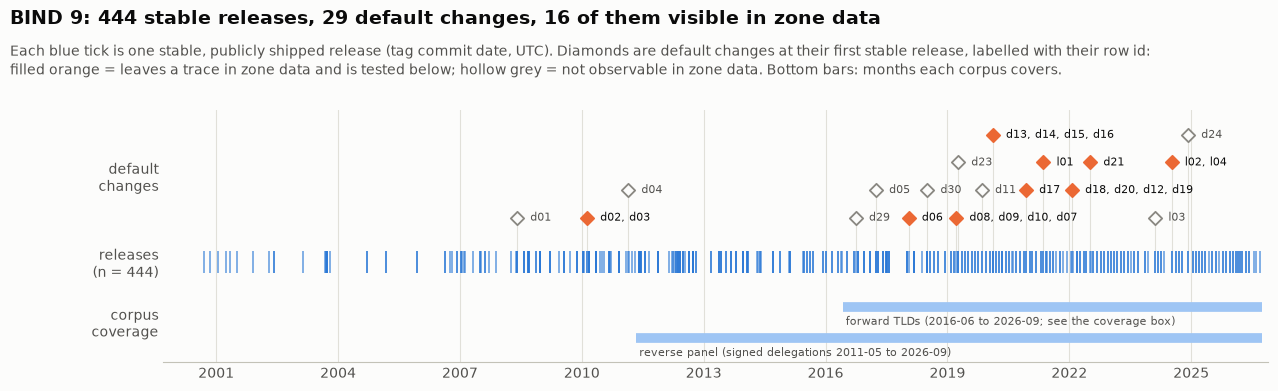

**How to read it.** Time runs left to right. BIND 9 shipped 444 stable public releases on 242 different days; with parallel branches counted once, the median gap between releases is 30 days. Of its 29 default changes, 16 can be seen in zone data at all; only those can be tested against the zone data, and only when they fall inside a covered stretch of a corpus with 24 months of data before them.

In [18]:
cadence_strip("bind9")

#### Default changes of BIND 9 and what the step test found

row,first stable release,what it changes,expected,on upgrade / opt-in,"step test percentile, per corpus",why some corpora have no test
d02-keygen-default-alg-rsasha1,2010-02-16,RSASHA1 (algorithm 5) share,up,yes / no,no test,"no before-period: series valid from 2011-05, needs 2008-03; no before-period: series valid from 2016-06, needs 2008-02; no before-period: series valid from 2017"
d03-signzone-nsec3-iterations-100-to-10,2010-02-16,NSEC3 owner names with 10 iterations (forward only),up,yes / no,no test,"no before-period: series valid from 2016-06, needs 2008-02; no before-period: series valid from 2017-05, needs 2008-02; no before-period: series valid from 2019"
d06-keygen-no-default-alg,2018-01-17,RSASHA1 (algorithm 5) share,down,yes / no,reverse panel 86,"no before-period: series valid from 2016-06, needs 2016-01; no before-period: series valid from 2017-05, needs 2016-01; no before-period: series valid from 2019"
d08-rsamd5-removed,2019-03-20,RSAMD5 (algorithm 1) share of signed zones / delegations,down,yes / no,.se 28; .nu 92,"no before-period: series valid from 2019-07, needs 2017-03; no month with at least 30; the value is absent in every month of the window 2017-04..2020-03; the va"
d09-gost-removed,2019-03-20,ECC-GOST (algorithm 12) share,down,yes / no,no test,no month with at least 30; the value is absent in every month of the window 2017-03..2020-02; the value is absent in every month of the window 2017-04..2020-03;
d10-dsa-removed,2019-03-20,"DSA (algorithms 3, 6) share",down,yes / no,.se 76,"no before-period: series valid from 2020-05, needs 2017-03; no before-period: series valid from 2022-08, needs 2017-03; no month with at least 30; the value is"
d13-ds-cds-sha1-dropped,2020-02-12,SHA-1 DS (digest 1) share of DS-carrying delegations,down,yes / no,.se 16; .nu 18; .gov 58; reverse panel 75,"no before-period: series valid from 2020-05, needs 2018-02; no before-period: series valid from 2022-08, needs 2018-02; no month with at least 30; the value nev"
d14-keygen-rsa-zsk-2048,2020-02-12,"1024-bit RSA keys, share of names with an RSA key (forward only)",down,yes / no,.se 19; .nu 35; .gov 66,"no before-period: series valid from 2019-07, needs 2018-02; no before-period: series valid from 2020-05, needs 2018-02; no before-period: series valid from 2022"
d15-dnssec-policy-default-ecdsap256,2020-02-12,ECDSAP256SHA256 (algorithm 13) share,up,no / yes,.se 13; .nu 11; .gov 62; reverse panel 7,"no before-period: series valid from 2019-07, needs 2018-02; no before-period: series valid from 2020-05, needs 2018-02; no before-period: series valid from 2022"
d16-dnssec-policy-default-key-size-2048,2020-02-12,"1024-bit RSA keys, share of names with an RSA key (forward only)",down,no / yes,.se 16; .nu 32; .gov 65,"no before-period: series valid from 2019-07, needs 2018-02; no before-period: series valid from 2020-05, needs 2018-02; no before-period: series valid from 2022"


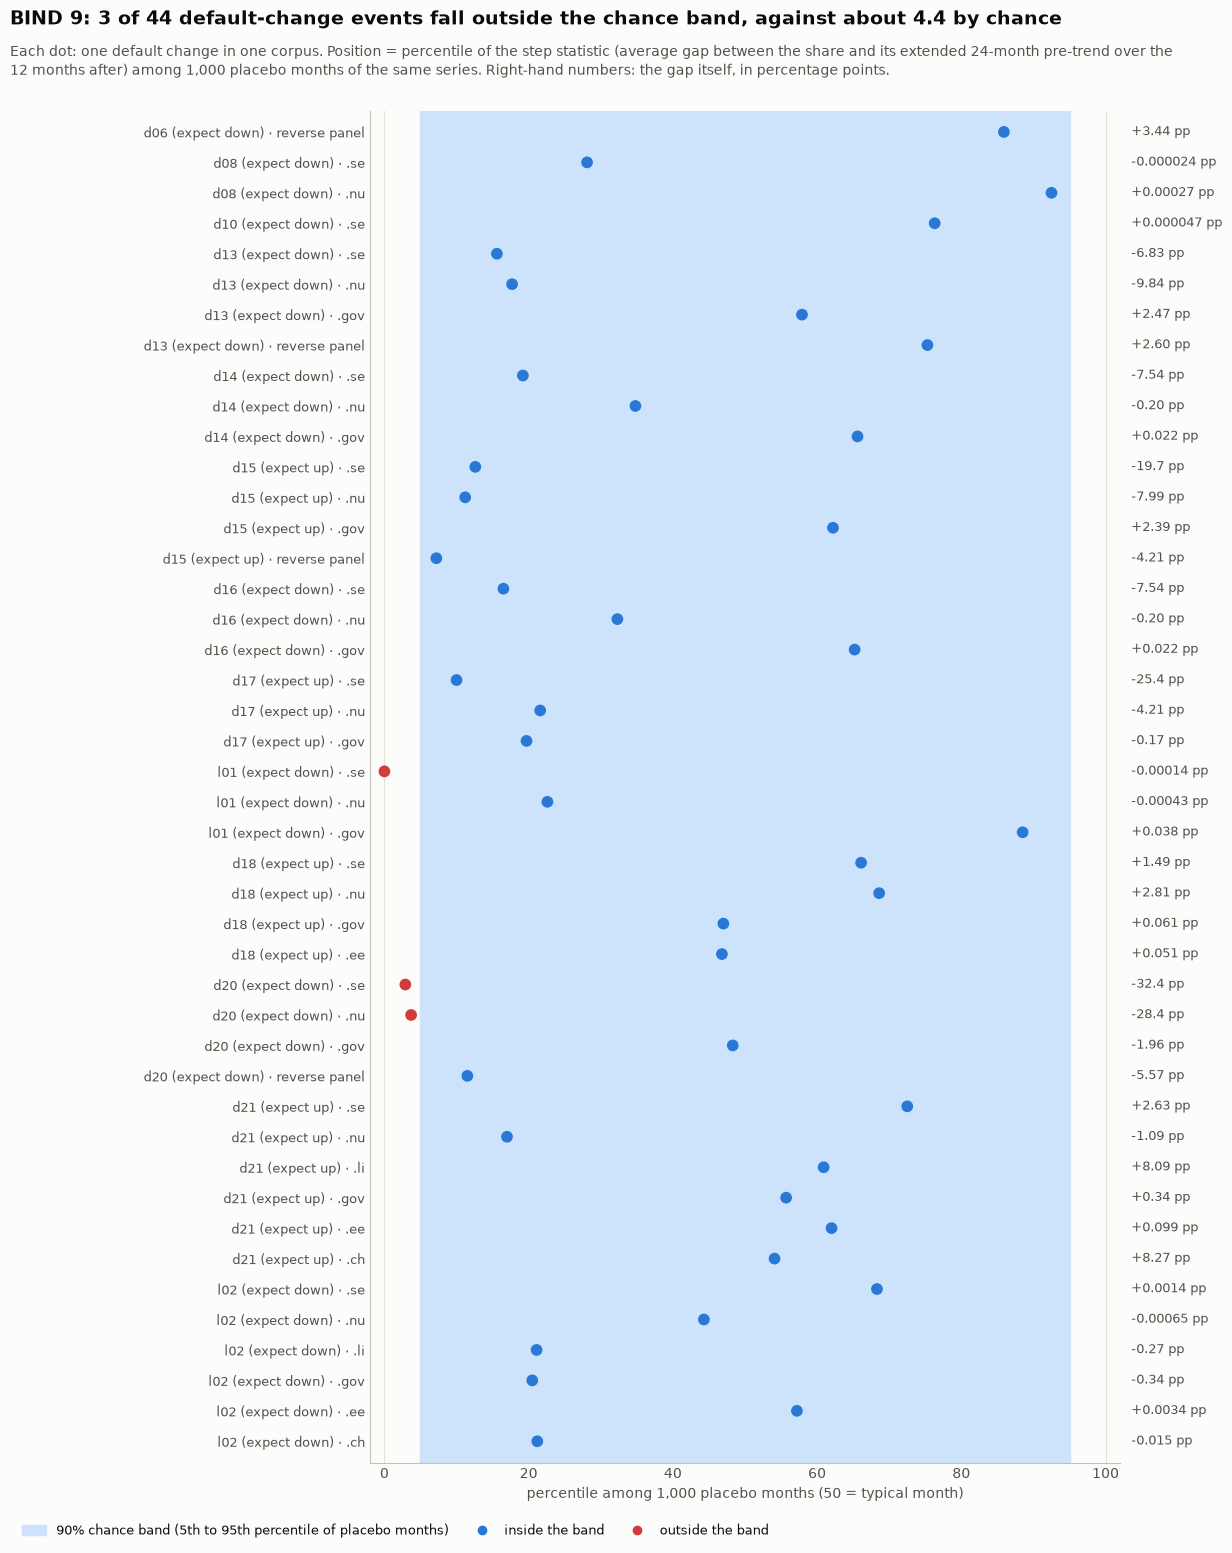

**How to read it.** A dot far right means the share ended up *higher* than its own trend predicted, far left *lower*. Only dots outside the shaded band are unusual, and even with no effect anywhere about 1 in 10 lands outside. Here 3 of 44 are outside, against 4.4 expected by chance. Outside: d20-dnssec-cds-sha2-only in .nu at percentile 3.7 (-28.4 pp, in the expected direction); d20-dnssec-cds-sha2-only in .se at percentile 2.9 (-32.4 pp, in the expected direction); l01-nsec3-max-iterations-150 in .se at percentile 0.0 (-0.00014 pp, a change of under 0.01 percentage points; the share barely moved, in the expected direction).

In [19]:
q2_table("bind9")
q2_dotplot("bind9")

#### Does feature use shift after BIND 9's releases?

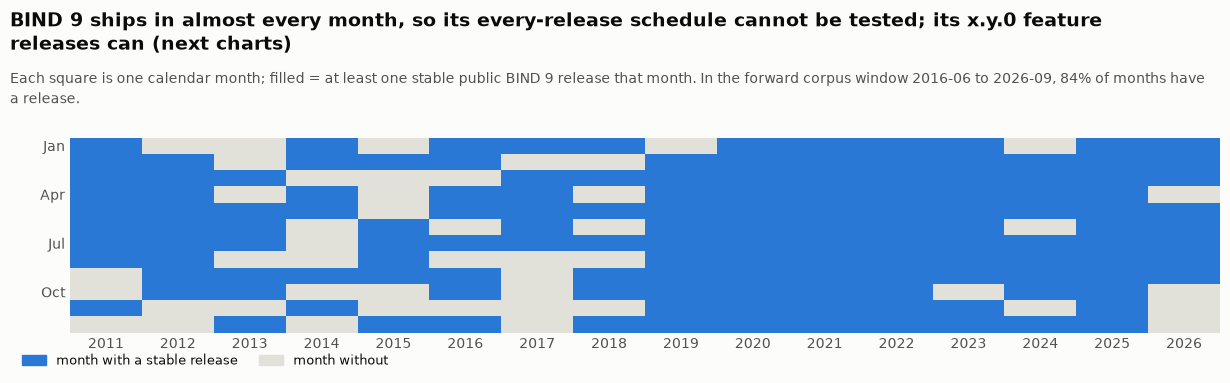

**How to read it.** The program-level test compares the months after real releases with the months after a *shifted* copy of the schedule. When nearly every month already holds a release, every shifted copy covers nearly the same months, so there is nothing to compare against. Phase 7 therefore requires releases to fill at most 75% of a series' testable window; BIND 9 exceeds that in every series. This is a limit of the method, not evidence either way.

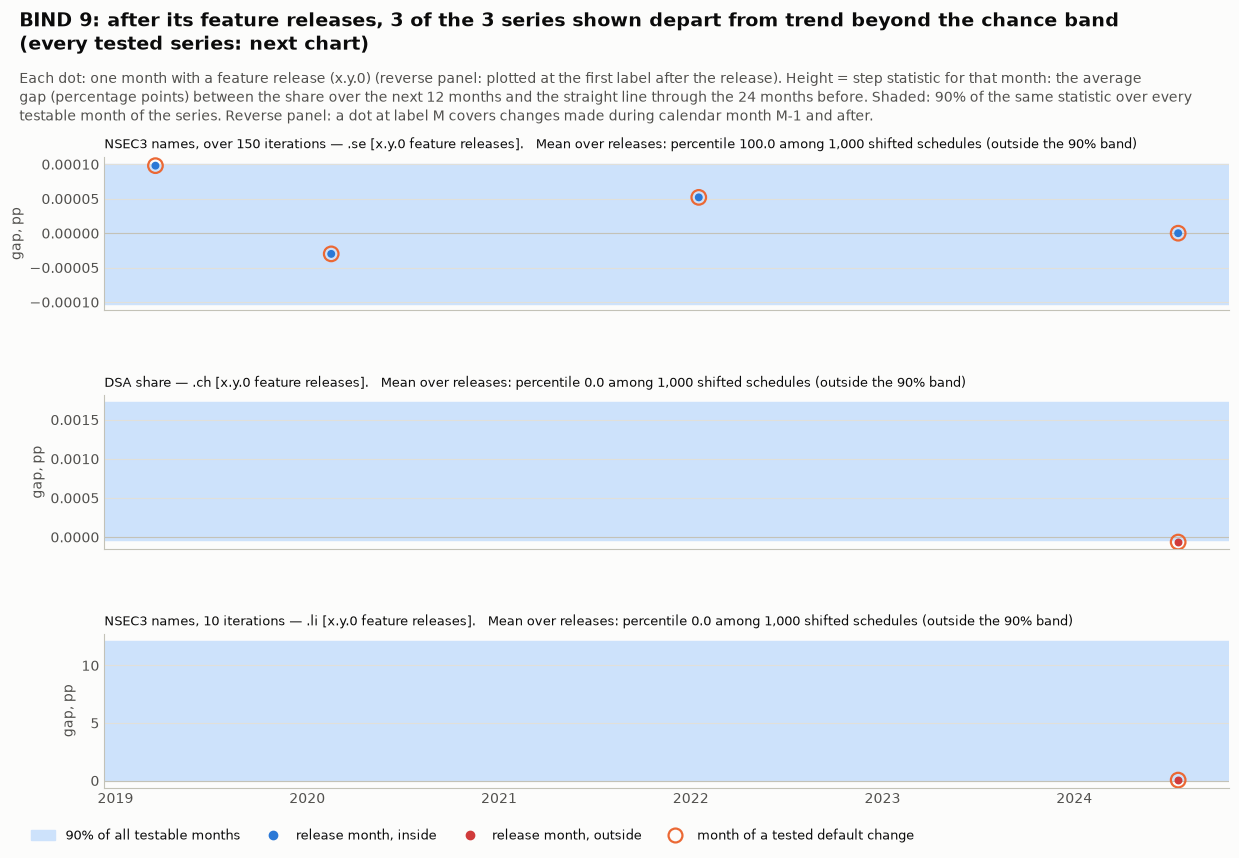

**How to read it.** If releases pushed feature use, the dots would sit mostly above (or below) the shaded band. Dots scattered across it, with a few outside, is what any random set of months looks like. NSEC3 names, over 150 iterations in .se: 0% of 4 release months outside the band, against 12% under shifted schedules; every gap in this series is under 0.01 pp, so the share barely moves and an 'outside' result here is a ranking artefact, not a real change; DSA share in .ch: 100% of 1 release months outside the band, against 12% under shifted schedules; every gap in this series is under 0.01 pp, so the share barely moves and an 'outside' result here is a ranking artefact, not a real change; NSEC3 names, 10 iterations in .li: 100% of 1 release months outside the band, against 12% under shifted schedules. Neighbouring dots form smooth waves because consecutive months share 11 of their 12 after-months; that is why the test shifts the whole schedule instead of counting dots, and why the title reports the test, not the dots. An orange ring marks a release month that is also the month of a tested default change. Series with a result outside the band are shown first. Series shown: up to three, one per observable, the reverse panel first where tested; every tested series is in the next chart.

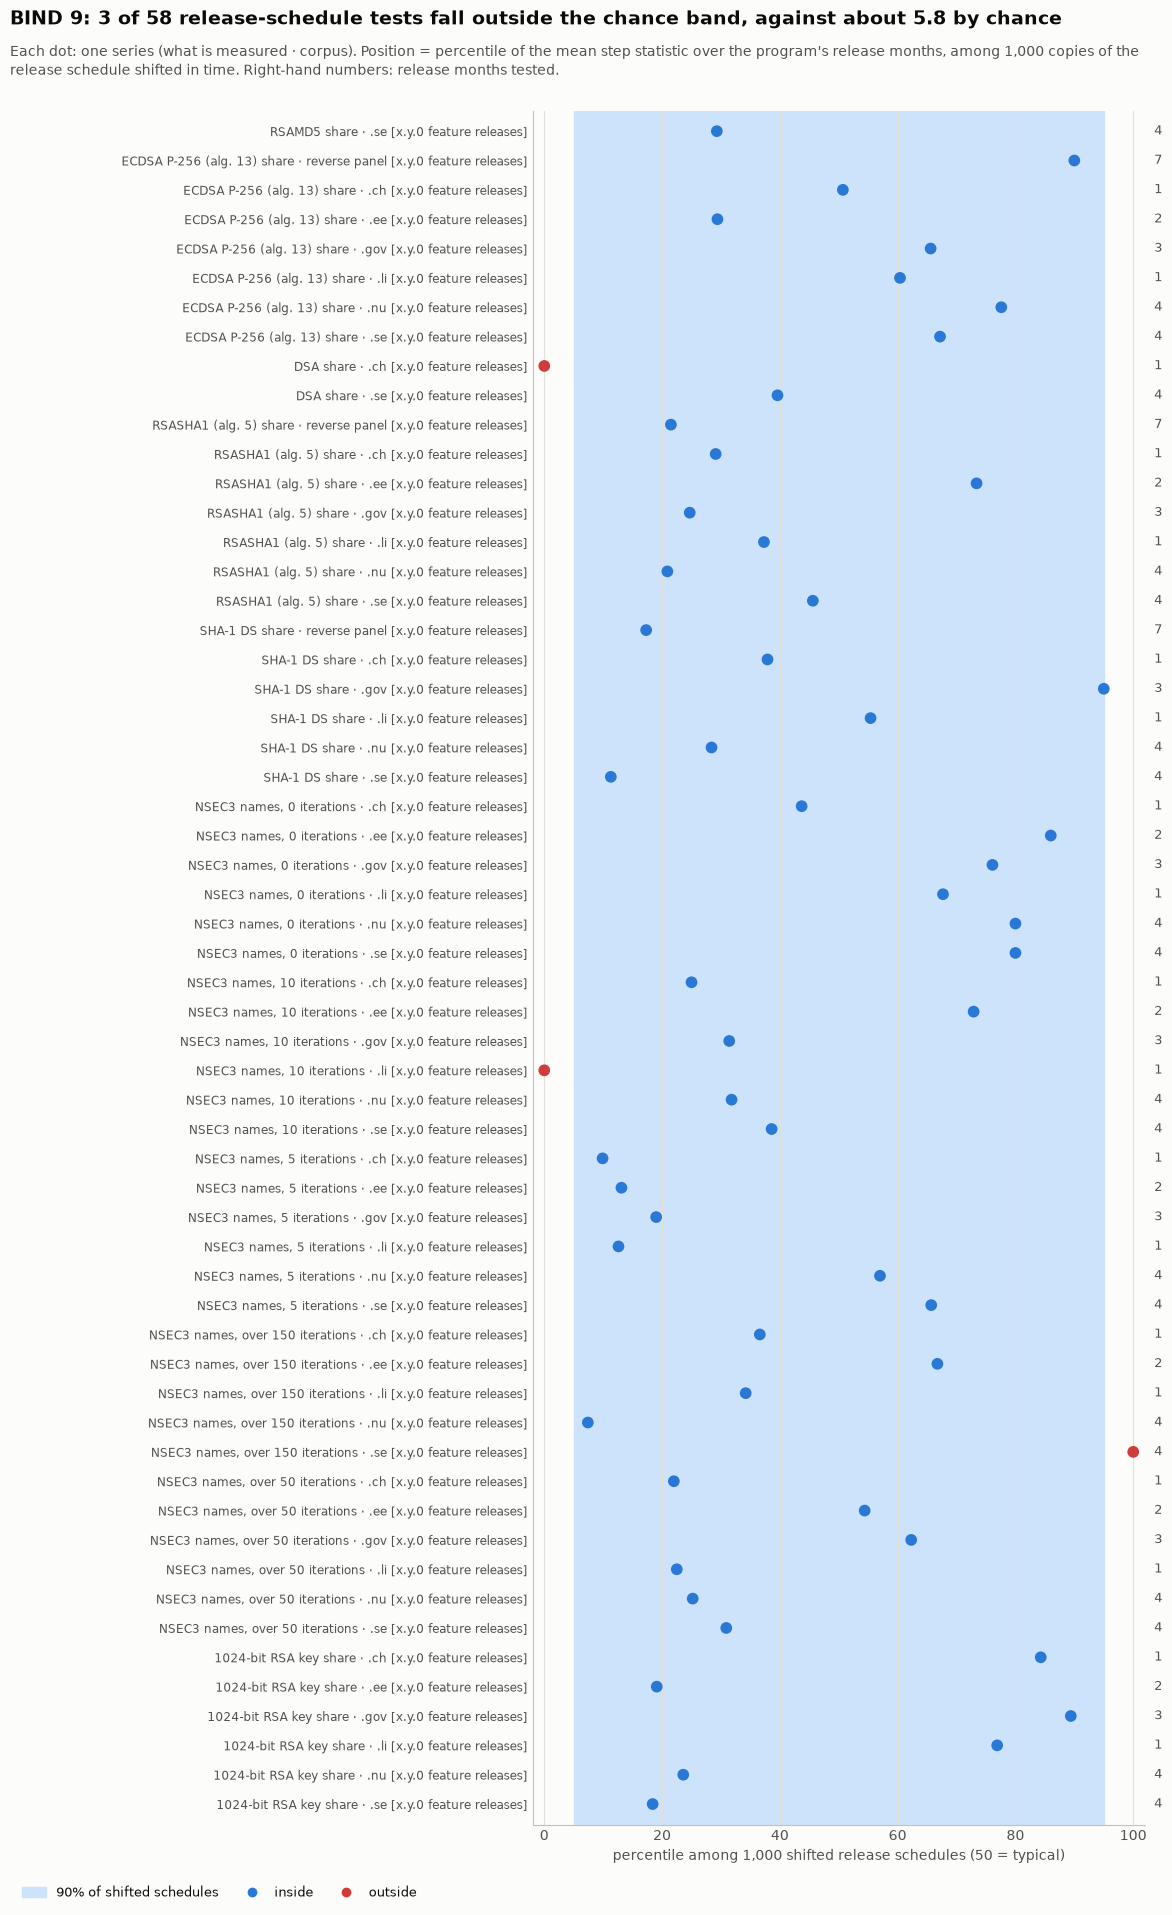

**How to read it.** One dot per series tested. Dots in the band mean that the months right after BIND 9 releases look like any other months. 3 of 58 are outside, against 5.8 expected by chance. Outside: NSEC3 names, over 150 iterations in .se (p < 0.001); NSEC3 names, 10 iterations in .li (p < 0.001); DSA share in .ch (p < 0.001).

**Series not tested** (90, besides .fed.us, which is never signed): 58 because releases fill more than 75% of the testable window; 19 because the value never appears in that corpus; 10 because the series is too short; 3 because the value is present in fewer than 12 months.

**Series not tested [x.y.0 feature releases]** (32, besides .fed.us, which is never signed): 19 because the value never appears in that corpus; 10 because the series is too short; 3 because the value is present in fewer than 12 months.

In [20]:
occupancy("bind9")
q1_release_dots("bind9")
q1_summary("bind9")
q1_untestable("bind9")

#### BIND 9: CVE fix latency

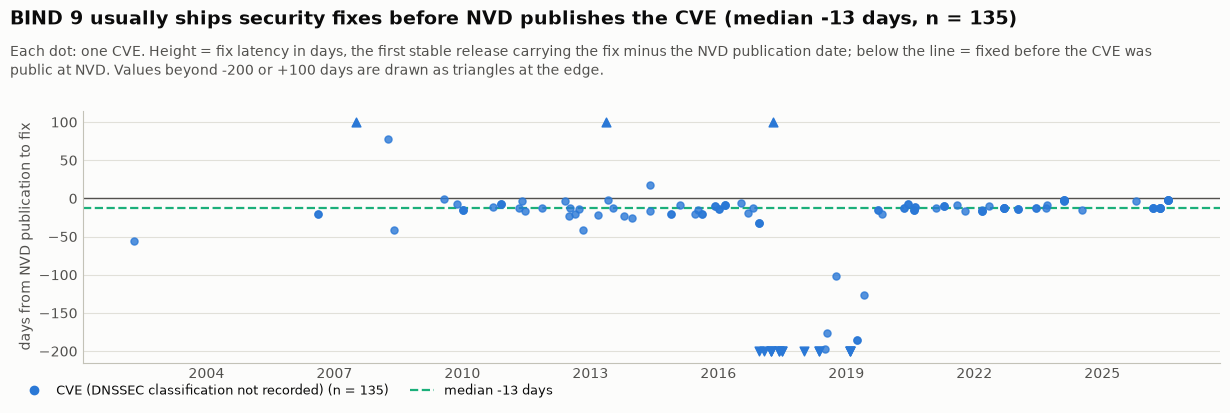

**How to read it.** Negative days are normal for embargoed security releases: the vendor tags the fix a few days before the CVE goes public. The middle half of BIND 9's fixes lie between -21 and -9 days. 18 CVE(s) fall beyond the axis and are drawn at the edge.

In [21]:
cve_strip("bind9")

#### Verdict for BIND 9

In [22]:
verdict("bind9")

**Adoption (share of domains signed, section 2b).** release schedule: no test (releases fill more than 75% of the testable window); release schedule [x.y.0 feature releases]: 0 of 19 tests unusual, about 1.9 expected; default changes that could change signing: 3 of 10 tests unusual (d15-dnssec-policy-default-ecdsap256, DS in .nu, -4.38 pp, against the expected direction; d15-dnssec-policy-default-ecdsap256, DNSKEY in .nu, -9.92 pp, against the expected direction; d15-dnssec-policy-default-ecdsap256, RRSIG in .nu, -9.88 pp, against the expected direction).

**Feature use.** Feature use does not shift after BIND 9's releases or default changes more often than chance: 6 of 102 tests fall outside the band, against about 10.2. Of the results outside the band, 3 on series that barely move (under 0.01 pp) and 2 against the direction the program's defaults would push.

**Releases (every stable release).** No test ran on this schedule: most series fail because releases fill more than 75% of the testable window. This is a limit of the method, not evidence either way.

**Releases [x.y.0 feature releases].** 3 of 58 program-level step tests fall outside the chance band, against about 5.8 by chance. Outside: DSA share in .ch, p < 0.001 (lower than under shifted schedules, in the direction its defaults push; every gap is under 0.01 pp, so the share barely moved); NSEC3 names, 10 iterations in .li, p < 0.001 (lower than under shifted schedules, against the direction its defaults push); NSEC3 names, over 150 iterations in .se, p < 0.001 (higher than under shifted schedules, against the direction its defaults push; every gap is under 0.01 pp, so the share barely moved).

**Default changes.** 3 of 44 step tests fall outside the chance band, against about 4.4 by chance. Outside: d20-dnssec-cds-sha2-only in .se, -32.4 pp at percentile 2.9, in the expected direction; d20-dnssec-cds-sha2-only in .nu, -28.4 pp at percentile 3.7, in the expected direction; l01-nsec3-max-iterations-150 in .se, -0.00014 pp at percentile 0.0, in the expected direction, a change of under 0.01 percentage points; the share barely moved. Large moves can still sit inside the band of a volatile series: d15-dnssec-policy-default-ecdsap256 in .se, -19.7 pp; d17-nsec3param-default-in-policy in .se, -25.4 pp.

**Key default changes.** the opt-in ECDSA policy default of 9.16.0 (d15-dnssec-policy-default-ecdsap256): percentile 13 in .se, 11 in .nu, 62 in .gov, 7 in reverse panel; SHA-2-only CDS handling (d20-dnssec-cds-sha2-only): percentile 3 in .se, 4 in .nu, 48 in .gov, 12 in reverse panel; the zero-iteration dnssec-signzone default (d21-signzone-nsec3-iterations-0): percentile 72 in .se, 17 in .nu, 56 in .gov, 62 in .ee, 54 in .ch, 61 in .li.

**Reverse ledger (section 5).** d02-keygen-default-alg-rsasha1: large-action p = 0.224, block-level p = 0.630; d15-dnssec-policy-default-ecdsap256: large-action p = 0.787, block-level p = 0.237.

**Security fixes.** Median -13 days from NVD publication (n = 135).

### 3.2 Unbound

Unbound is a validating resolver. It does not sign, so none of its defaults changes what a zone publishes. Only its
NSEC3 iteration caps map to zone data, and only indirectly: a validator cap might push zone operators to lower their
iteration counts.

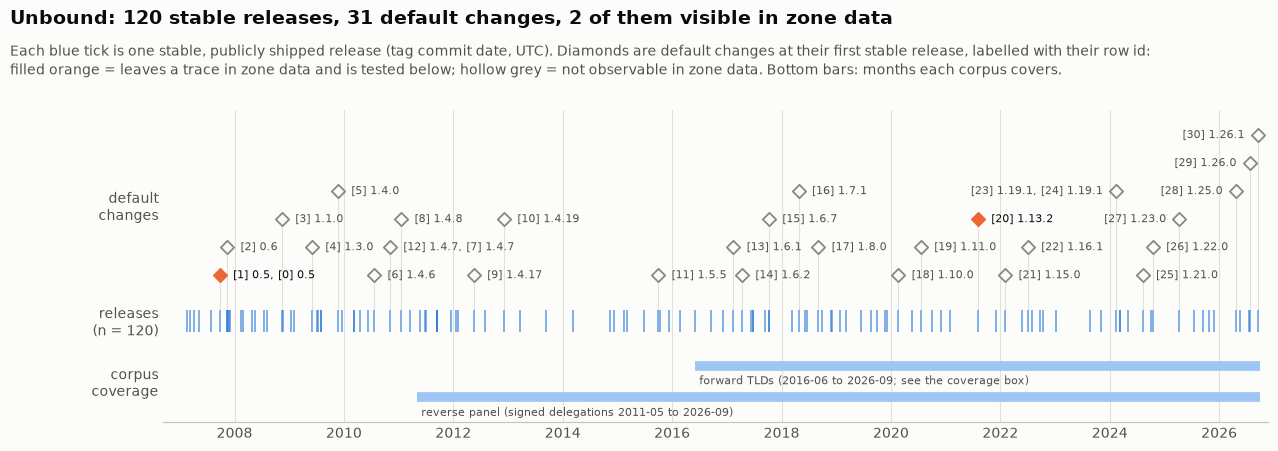

**How to read it.** Time runs left to right. Unbound shipped 120 stable public releases on 118 different days; with parallel branches counted once, the median gap between releases is 56 days. Of its 31 default changes, 2 can be seen in zone data at all; only those can be tested against the zone data, and only when they fall inside a covered stretch of a corpus with 24 months of data before them.

In [23]:
cadence_strip("unbound")

#### Default changes of Unbound and what the step test found

row,first stable release,what it changes,expected,on upgrade / opt-in,"step test percentile, per corpus",why some corpora have no test
unbound[1]@0.5,2007-09-25,NSEC3 owner names above 150 iterations (forward only),down,yes / no,no test,"no before-period: series valid from 2016-06, needs 2005-09; no before-period: series valid from 2017-05, needs 2005-09; no before-period: series valid from 2019"
unbound[20]@1.13.2,2021-08-05,NSEC3 owner names above 150 iterations (forward only),down,yes / no,.se 13; .nu 10; .gov 74; .ee 87,"no before-period: series valid from 2020-05, needs 2019-08; no before-period: series valid from 2022-08, needs 2019-08; no month with at least 30"


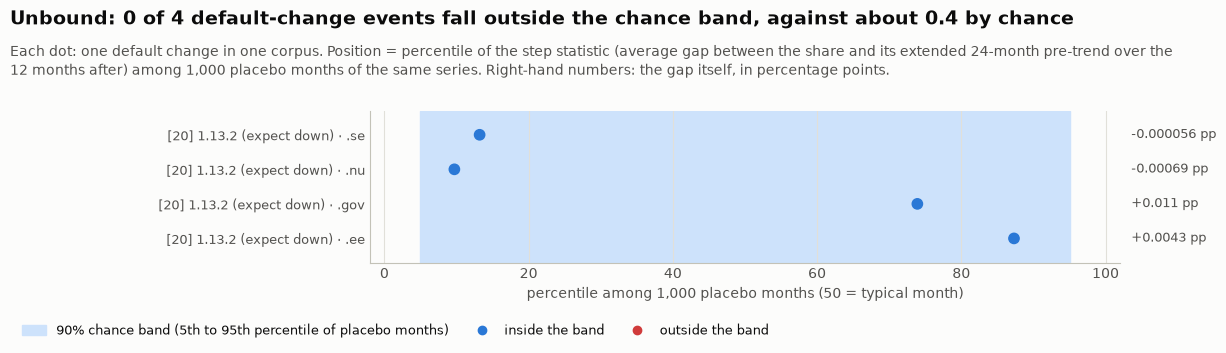

**How to read it.** A dot far right means the share ended up *higher* than its own trend predicted, far left *lower*. Only dots outside the shaded band are unusual, and even with no effect anywhere about 1 in 10 lands outside. Here 0 of 4 are outside, against 0.4 expected by chance.

In [24]:
q2_table("unbound")
q2_dotplot("unbound")

#### Does feature use shift after Unbound's releases?

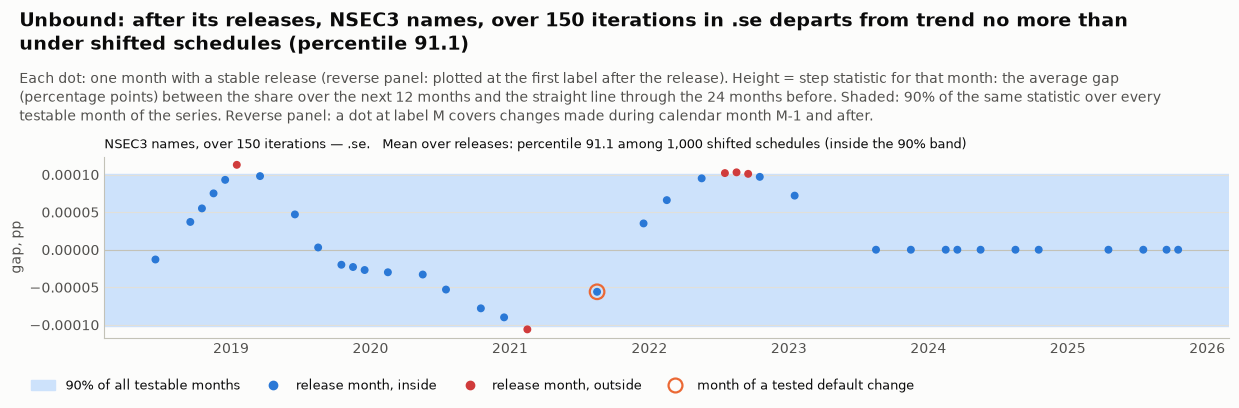

**How to read it.** If releases pushed feature use, the dots would sit mostly above (or below) the shaded band. Dots scattered across it, with a few outside, is what any random set of months looks like. NSEC3 names, over 150 iterations in .se: 13% of 38 release months outside the band, against 11% under shifted schedules; every gap in this series is under 0.01 pp, so the share barely moves and an 'outside' result here is a ranking artefact, not a real change. Neighbouring dots form smooth waves because consecutive months share 11 of their 12 after-months; that is why the test shifts the whole schedule instead of counting dots, and why the title reports the test, not the dots. An orange ring marks a release month that is also the month of a tested default change. Series with a result outside the band are shown first. Series shown: up to three, one per observable, the reverse panel first where tested; every tested series is in the next chart.

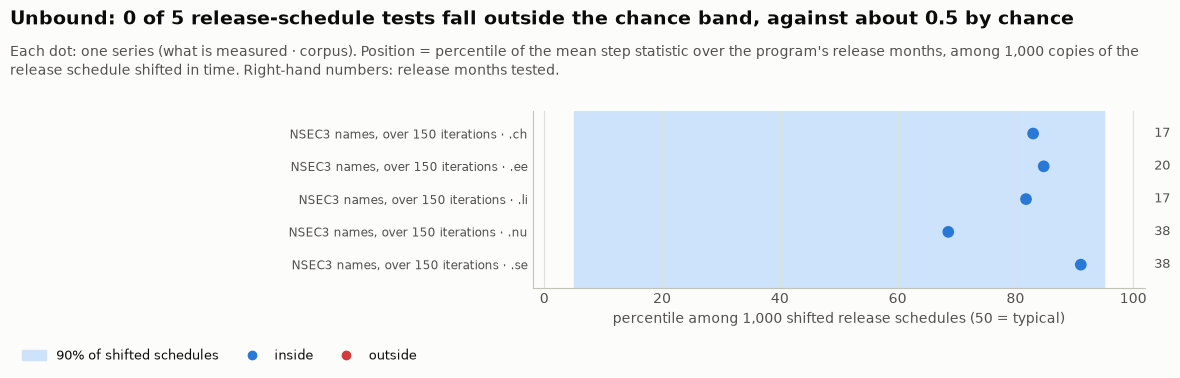

**How to read it.** One dot per series tested. Dots in the band mean that the months right after Unbound releases look like any other months. 0 of 5 are outside, against 0.5 expected by chance.

**Series not tested** (2, besides .fed.us, which is never signed): 1 because the value is present in fewer than 12 months; 1 because the series is too short.

In [25]:
q1_release_dots("unbound")
q1_summary("unbound")
q1_untestable("unbound")

#### Unbound: CVE fix latency

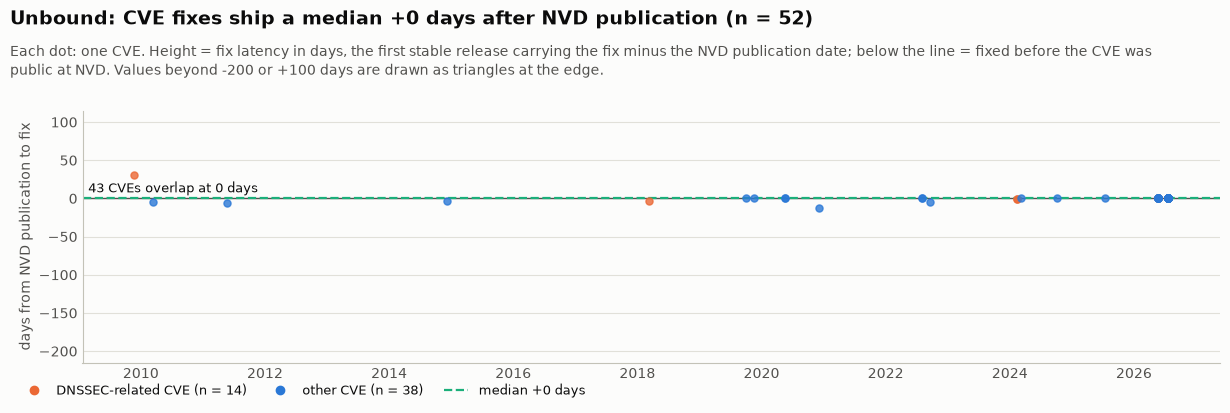

**How to read it.** Negative days are normal for embargoed security releases: the vendor tags the fix a few days before the CVE goes public. The middle half of Unbound's fixes lie between +0 and +0 days. 0 CVE(s) fall beyond the axis and are drawn at the edge. 43 of 52 CVEs were fixed in a release dated the same day NVD published them, so they sit on the zero line on top of each other.

In [26]:
cve_strip("unbound")

#### Verdict for Unbound

In [27]:
verdict("unbound")

**Adoption (share of domains signed, section 2b).** release schedule: 0 of 19 tests unusual, about 1.9 expected; none of its default changes could change whether zones get signed.

**Feature use.** Feature use does not shift after Unbound's releases or default changes more often than chance: 0 of 9 tests fall outside the band, against about 0.9.

**Releases.** 0 of 5 program-level step tests fall outside the chance band, against about 0.5 by chance.

**Default changes.** 0 of 4 step tests fall outside the chance band, against about 0.4 by chance.

**Key default changes.** the NSEC3 cap of 150 (unbound[20]@1.13.2): percentile 13 in .se, 10 in .nu, 74 in .gov, 87 in .ee.

**Security fixes.** Median +0 days from NVD publication (n = 52).

### 3.3 Knot DNS

Knot DNS is an authoritative server and signer. Its default changes include the first ECDSA signing default of any
program (2.1.0, 2016-01) and a zero-iteration NSEC3 default (3.2.0, 2022-08).

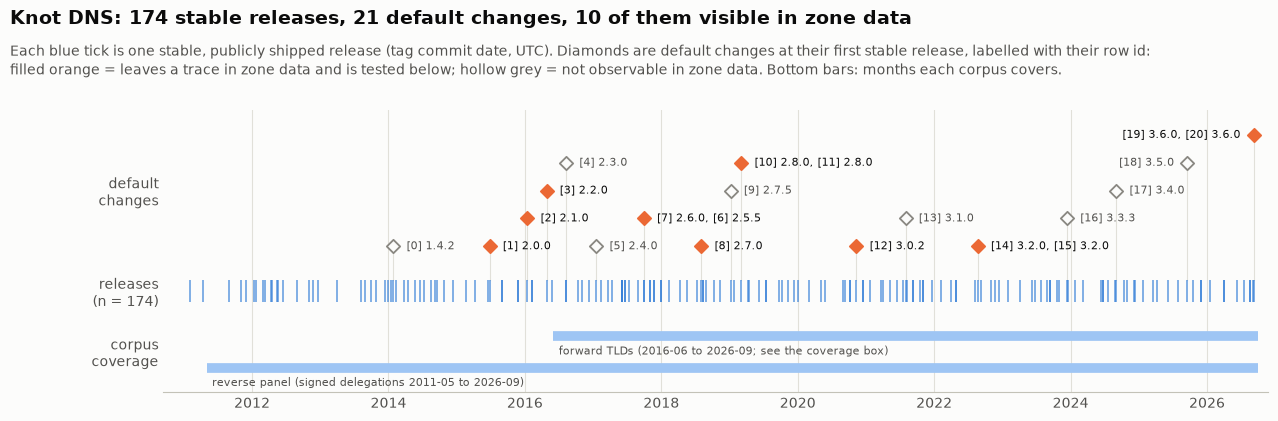

**How to read it.** Time runs left to right. Knot DNS shipped 174 stable public releases on 157 different days; with parallel branches counted once, the median gap between releases is 34 days. Of its 21 default changes, 10 can be seen in zone data at all; only those can be tested against the zone data, and only when they fall inside a covered stretch of a corpus with 24 months of data before them.

In [28]:
cadence_strip("knot")

#### Default changes of Knot DNS and what the step test found

row,first stable release,what it changes,expected,on upgrade / opt-in,"step test percentile, per corpus",why some corpora have no test
knot[1]@2.0.0,2015-06-26,RSASHA256 (algorithm 8) share,up,no / no,reverse panel 2 (outside),"no before-period: series valid from 2016-06, needs 2013-06; no before-period: series valid from 2017-05, needs 2013-06; no before-period: series valid from 2019"
knot[2]@2.1.0,2016-01-14,ECDSAP256SHA256 (algorithm 13) share,up,no / no,reverse panel 64,"no before-period: series valid from 2016-06, needs 2014-01; no before-period: series valid from 2017-05, needs 2014-01; no before-period: series valid from 2019"
knot[3]@2.2.0,2016-04-26,"1024-bit RSA keys, share of names with an RSA key (forward only)",down,no / no,no test,"no before-period: series valid from 2016-06, needs 2014-04; no before-period: series valid from 2017-05, needs 2014-04; no before-period: series valid from 2019"
knot[7]@2.6.0,2017-09-29,"DSA (algorithms 3, 6) share",down,yes / no,no test,"no before-period: series valid from 2016-06, needs 2015-09; no before-period: series valid from 2020-05, needs 2015-09; no before-period: series valid from 2022"
knot[8]@2.7.0,2018-08-03,"RSA keys under 1024 bits, share of names with an RSA key (forward only)",down,yes / no,.se 79; .nu 2 (outside),"no before-period: series valid from 2017-05, needs 2016-08; no before-period: series valid from 2020-05, needs 2016-08; no before-period: series valid from 2022"
knot[10]@2.8.0,2019-03-05,zones publishing CDS over signed zones (forward only),down,yes / no,.se 48; .nu 52,"no before-period: series valid from 2017-05, needs 2017-03; no before-period: series valid from 2019-07, needs 2017-03; no before-period: series valid from 2020"
knot[11]@2.8.0,2019-03-05,SHA-1 DS (digest 1) share of DS-carrying delegations,down,yes / no,.se 82; .nu 93; reverse panel 22,"no before-period: series valid from 2017-05, needs 2017-03; no before-period: series valid from 2020-05, needs 2017-03; no before-period: series valid from 2022"
knot[12]@3.0.2,2020-11-11,"RSASHA1 family (algorithms 5, 7) share",down,yes / no,.se 58; .nu 13; .gov 33; reverse panel 84,"no before-period: series valid from 2019-07, needs 2018-11; no before-period: series valid from 2020-05, needs 2018-11; no before-period: series valid from 2022"
knot[14]@3.2.0,2022-08-22,"NSEC3 owner names with 0 iterations, share of NSEC3 owner names (forward only)",up,yes / no,.se 74; .nu 17; .gov 57; .ee 65; .ch 58; .li 65,"no before-period: series valid from 2022-08, needs 2020-08; no month with at least 30"
knot[19]@3.6.0,2026-09-08,NSEC3 owner names above 256 iterations (forward only),down,yes / no,no test,"no after-period: series valid to 2024-02, needs 2027-08; no after-period: series valid to 2026-09, needs 2027-08; no month with at least 30; the value never app"


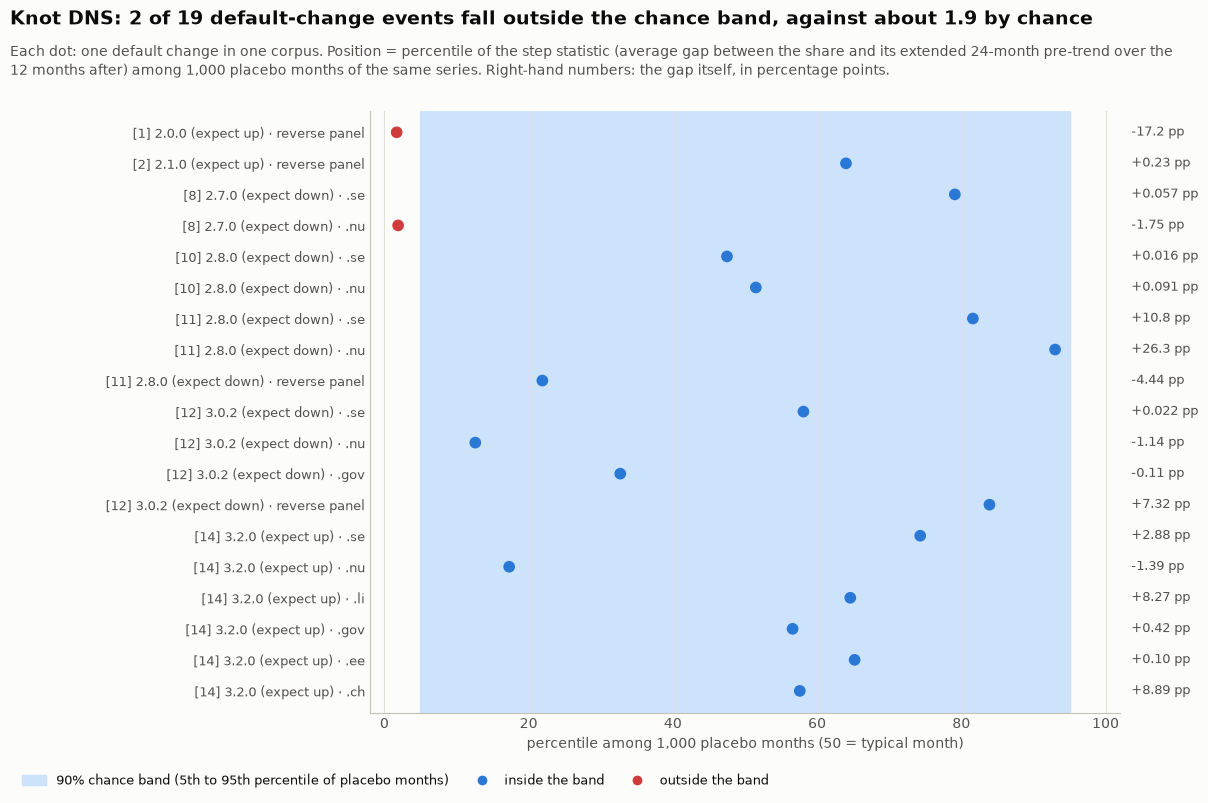

**How to read it.** A dot far right means the share ended up *higher* than its own trend predicted, far left *lower*. Only dots outside the shaded band are unusual, and even with no effect anywhere about 1 in 10 lands outside. Here 2 of 19 are outside, against 1.9 expected by chance. Outside: knot[8]@2.7.0 in .nu at percentile 1.9 (-1.75 pp, in the expected direction); knot[1]@2.0.0 in reverse panel at percentile 1.7 (-17.2 pp, against the expected direction).

In [29]:
q2_table("knot")
q2_dotplot("knot")

#### Does feature use shift after Knot DNS's releases?

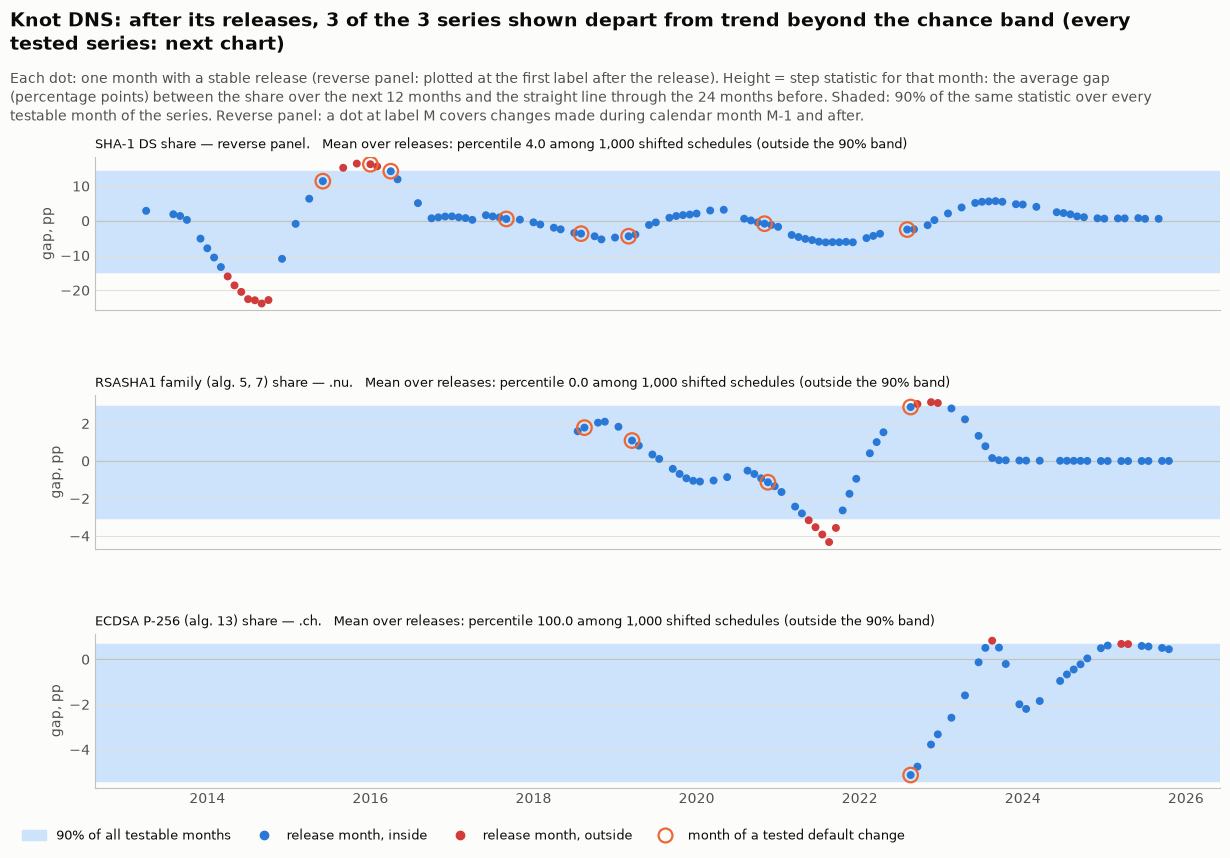

**How to read it.** If releases pushed feature use, the dots would sit mostly above (or below) the shaded band. Dots scattered across it, with a few outside, is what any random set of months looks like. SHA-1 DS share in reverse panel: 11% of 103 release months outside the band, against 11% under shifted schedules; RSASHA1 family (alg. 5, 7) share in .nu: 13% of 62 release months outside the band, against 11% under shifted schedules; ECDSA P-256 (alg. 13) share in .ch: 11% of 27 release months outside the band, against 14% under shifted schedules. Neighbouring dots form smooth waves because consecutive months share 11 of their 12 after-months; that is why the test shifts the whole schedule instead of counting dots, and why the title reports the test, not the dots. An orange ring marks a release month that is also the month of a tested default change. Series with a result outside the band are shown first. Series shown: up to three, one per observable, the reverse panel first where tested; every tested series is in the next chart.

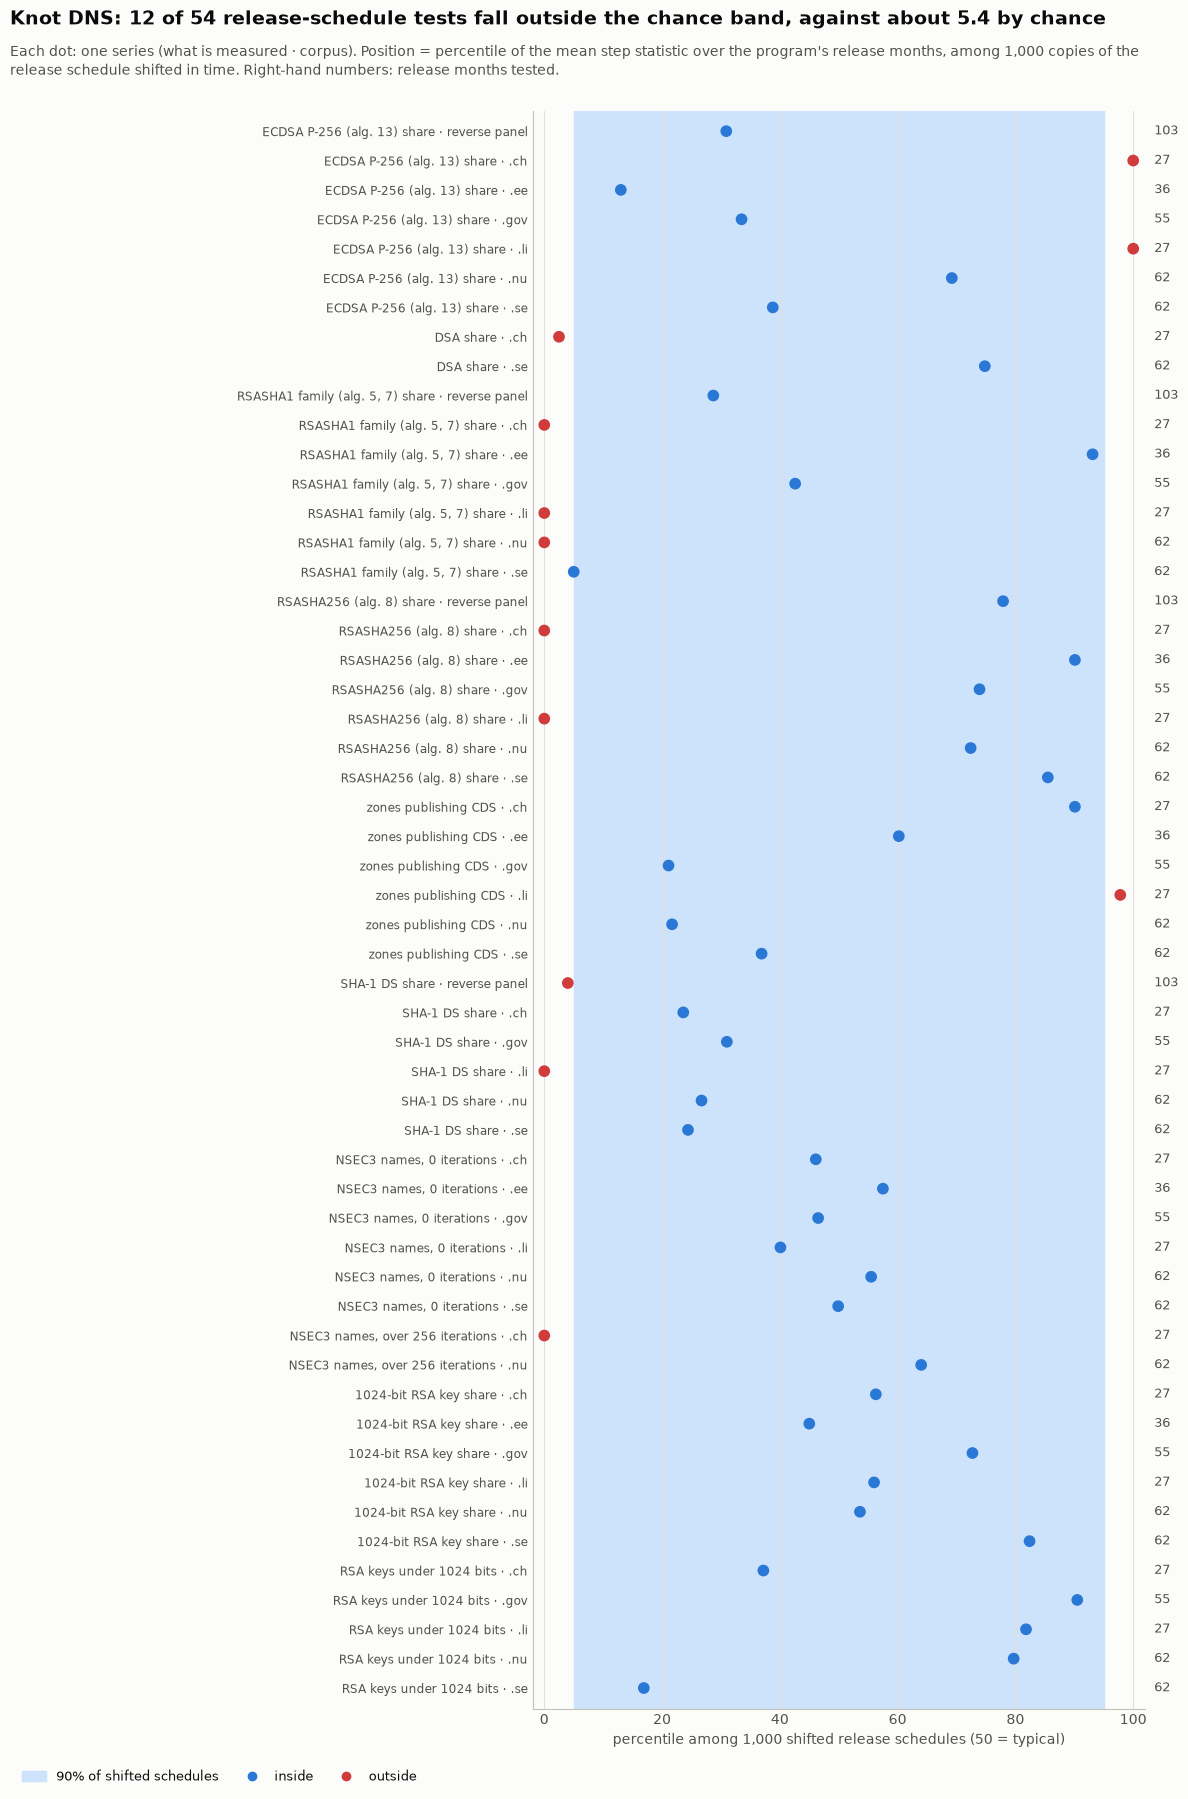

**How to read it.** One dot per series tested. Dots in the band mean that the months right after Knot DNS releases look like any other months. 12 of 54 are outside, against 5.4 expected by chance. Outside: NSEC3 names, over 256 iterations in .ch (p < 0.001); SHA-1 DS share in .li (p < 0.001); SHA-1 DS share in reverse panel (p = 0.080); zones publishing CDS in .li (p = 0.044); RSASHA256 (alg. 8) share in .li (p < 0.001); RSASHA256 (alg. 8) share in .ch (p < 0.001); RSASHA1 family (alg. 5, 7) share in .nu (p < 0.001); RSASHA1 family (alg. 5, 7) share in .li (p < 0.001); RSASHA1 family (alg. 5, 7) share in .ch (p < 0.001); DSA share in .ch (p = 0.050); ECDSA P-256 (alg. 13) share in .li (p < 0.001); ECDSA P-256 (alg. 13) share in .ch (p < 0.001).

**Series not tested** (21, besides .fed.us, which is never signed): 10 because the value never appears in that corpus; 9 because the series is too short; 2 because the value is present in fewer than 12 months.

In [30]:
q1_release_dots("knot")
q1_summary("knot")
q1_untestable("knot")

#### Knot DNS: CVE fix latency

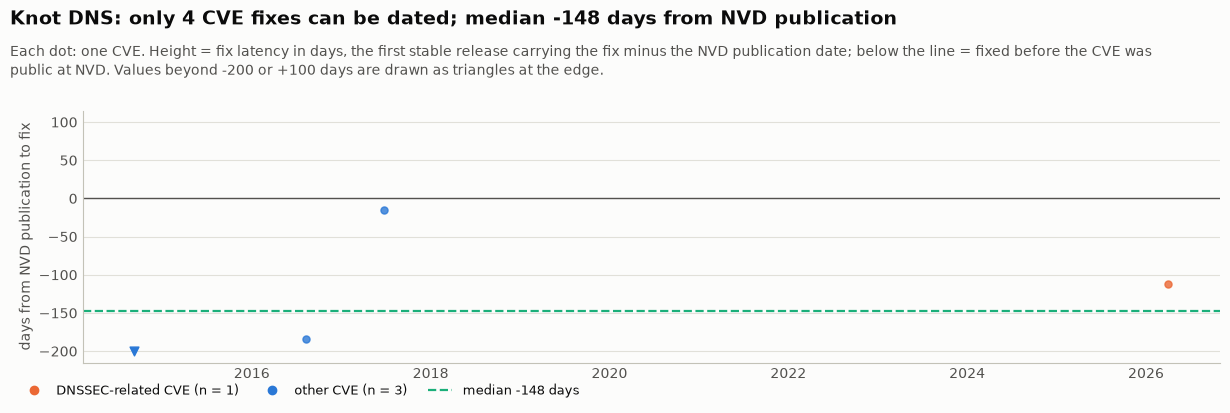

**How to read it.** Negative days are normal for embargoed security releases: the vendor tags the fix a few days before the CVE goes public. The middle half of Knot DNS's fixes lie between -462 and -87.75 days. 1 CVE(s) fall beyond the axis and are drawn at the edge. With n = 4 this median says little; for Knot it mostly measures NVD's delay in publishing old CVEs, not the vendor's speed.

In [31]:
cve_strip("knot")

#### Verdict for Knot DNS

In [32]:
verdict("knot")

**Adoption (share of domains signed, section 2b).** release schedule: 0 of 19 tests unusual, about 1.9 expected; default changes that could change signing: 2 of 4 tests unusual (knot[9]@2.7.5, DS in .nu, +8.89 pp, in the expected direction; knot[9]@2.7.5, DS in reverse panel, +0.072 pp, in the expected direction).

**Feature use.** Some Knot DNS feature-use results fall outside the band more often than chance (14 of 73 tests, against about 7.3); they are timing, not attribution, and are listed below.

**Releases.** 12 of 54 program-level step tests fall outside the chance band, against about 5.4 by chance. Outside: ECDSA P-256 (alg. 13) share in .ch, p < 0.001 (higher than under shifted schedules, in the direction its defaults push); ECDSA P-256 (alg. 13) share in .li, p < 0.001 (higher than under shifted schedules, in the direction its defaults push); DSA share in .ch, p = 0.050 (lower than under shifted schedules, in the direction its defaults push; every gap is under 0.01 pp, so the share barely moved); RSASHA1 family (alg. 5, 7) share in .nu, p < 0.001 (lower than under shifted schedules, in the direction its defaults push); RSASHA1 family (alg. 5, 7) share in .ch, p < 0.001 (lower than under shifted schedules, in the direction its defaults push); RSASHA1 family (alg. 5, 7) share in .li, p < 0.001 (lower than under shifted schedules, in the direction its defaults push); RSASHA256 (alg. 8) share in .ch, p < 0.001 (lower than under shifted schedules, against the direction its defaults push); RSASHA256 (alg. 8) share in .li, p < 0.001 (lower than under shifted schedules, against the direction its defaults push); zones publishing CDS in .li, p = 0.044 (higher than under shifted schedules, against the direction its defaults push); SHA-1 DS share in .li, p < 0.001 (lower than under shifted schedules, in the direction its defaults push); SHA-1 DS share in reverse panel, p = 0.080 (lower than under shifted schedules, in the direction its defaults push); NSEC3 names, over 256 iterations in .ch, p < 0.001 (lower than under shifted schedules, in the direction its defaults push).

**Default changes.** 2 of 19 step tests fall outside the chance band, against about 1.9 by chance. Outside: knot[1]@2.0.0 in reverse panel, -17.2 pp at percentile 1.7, against the expected direction; knot[8]@2.7.0 in .nu, -1.75 pp at percentile 1.9, in the expected direction. Large moves can still sit inside the band of a volatile series: knot[11]@2.8.0 in .se, +10.8 pp; knot[11]@2.8.0 in .nu, +26.3 pp.

**Key default changes.** the RSASHA256 default of 2.0.0 (knot[1]@2.0.0): percentile 2 in reverse panel; the first ECDSA signing default, 2.1.0 (knot[2]@2.1.0): percentile 64 in reverse panel; the zero-iteration NSEC3 default of 3.2.0 (knot[14]@3.2.0): percentile 74 in .se, 17 in .nu, 57 in .gov, 65 in .ee, 58 in .ch, 65 in .li.

**Reverse ledger (section 5).** knot[1]@2.0.0: large-action p = 0.362, block-level p = 0.680.

**Security fixes.** Median -148 days from NVD publication (n = 4).

### 3.4 Knot Resolver

Knot Resolver is a validating resolver. As with Unbound, only its NSEC3 iteration caps map to zone data, indirectly.

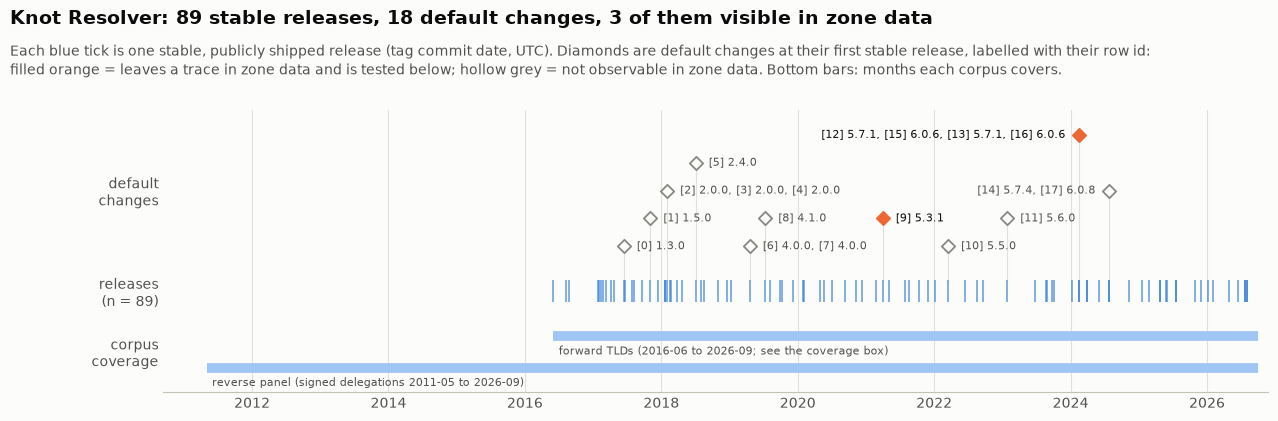

**How to read it.** Time runs left to right. Knot Resolver shipped 89 stable public releases on 82 different days; with parallel branches counted once, the median gap between releases is 37 days. Of its 18 default changes, 3 can be seen in zone data at all; only those can be tested against the zone data, and only when they fall inside a covered stretch of a corpus with 24 months of data before them.

In [33]:
cadence_strip("kresd")

#### Default changes of Knot Resolver and what the step test found

row,first stable release,what it changes,expected,on upgrade / opt-in,"step test percentile, per corpus",why some corpora have no test
kresd[9]@5.3.1,2021-03-31,NSEC3 owner names above 150 iterations (forward only),down,yes / no,.se 3 (outside); .nu 27; .gov 92,"no before-period: series valid from 2019-07, needs 2019-03; no before-period: series valid from 2020-05, needs 2019-03; no before-period: series valid from 2022"
kresd[12]@5.7.1,2024-02-13,NSEC3 owner names above 50 iterations (forward only),down,yes / no,.se 46; .nu 59; .gov 60; .ee 22; .ch 5; .li 5,"no before-period: series valid from 2022-08, needs 2022-02; no month with at least 30"
kresd[15]@6.0.6,2024-02-13,NSEC3 owner names above 50 iterations (forward only),down,yes / no,.se 46; .nu 60; .gov 57; .ee 24; .ch 5 (outside); .li 4 (outside),"no before-period: series valid from 2022-08, needs 2022-02; no month with at least 30"


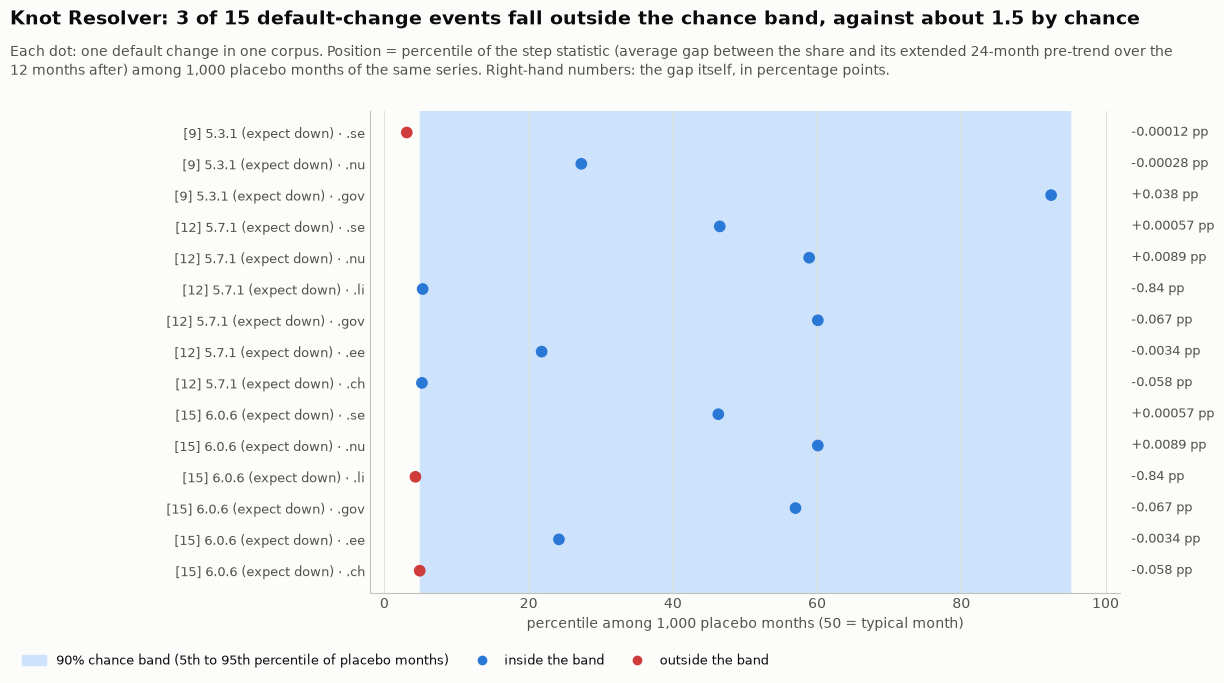

**How to read it.** A dot far right means the share ended up *higher* than its own trend predicted, far left *lower*. Only dots outside the shaded band are unusual, and even with no effect anywhere about 1 in 10 lands outside. Here 3 of 15 are outside, against 1.5 expected by chance. Outside: kresd[15]@6.0.6 in .ch at percentile 4.9 (-0.058 pp, in the expected direction); kresd[15]@6.0.6 in .li at percentile 4.3 (-0.84 pp, in the expected direction); kresd[9]@5.3.1 in .se at percentile 3.1 (-0.00012 pp, a change of under 0.01 percentage points; the share barely moved, in the expected direction).

In [34]:
q2_table("kresd")
q2_dotplot("kresd")

#### Does feature use shift after Knot Resolver's releases?

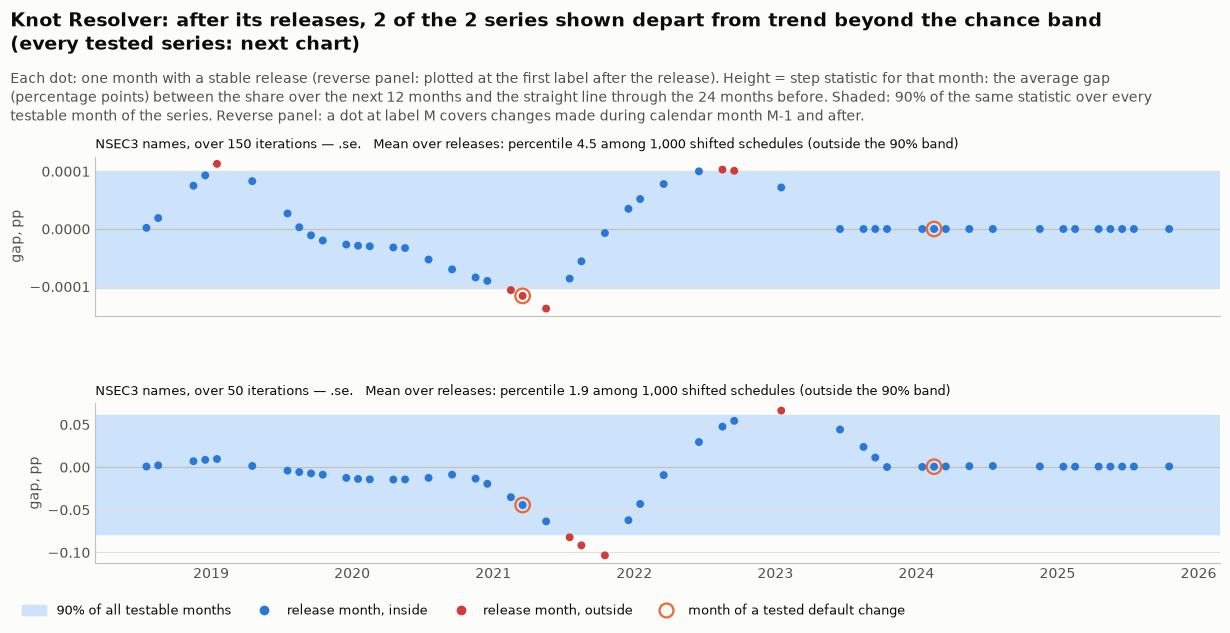

**How to read it.** If releases pushed feature use, the dots would sit mostly above (or below) the shaded band. Dots scattered across it, with a few outside, is what any random set of months looks like. NSEC3 names, over 150 iterations in .se: 12% of 49 release months outside the band, against 11% under shifted schedules; every gap in this series is under 0.01 pp, so the share barely moves and an 'outside' result here is a ranking artefact, not a real change; NSEC3 names, over 50 iterations in .se: 8% of 49 release months outside the band, against 11% under shifted schedules. Neighbouring dots form smooth waves because consecutive months share 11 of their 12 after-months; that is why the test shifts the whole schedule instead of counting dots, and why the title reports the test, not the dots. An orange ring marks a release month that is also the month of a tested default change. Series with a result outside the band are shown first. Series shown: up to three, one per observable, the reverse panel first where tested; every tested series is in the next chart.

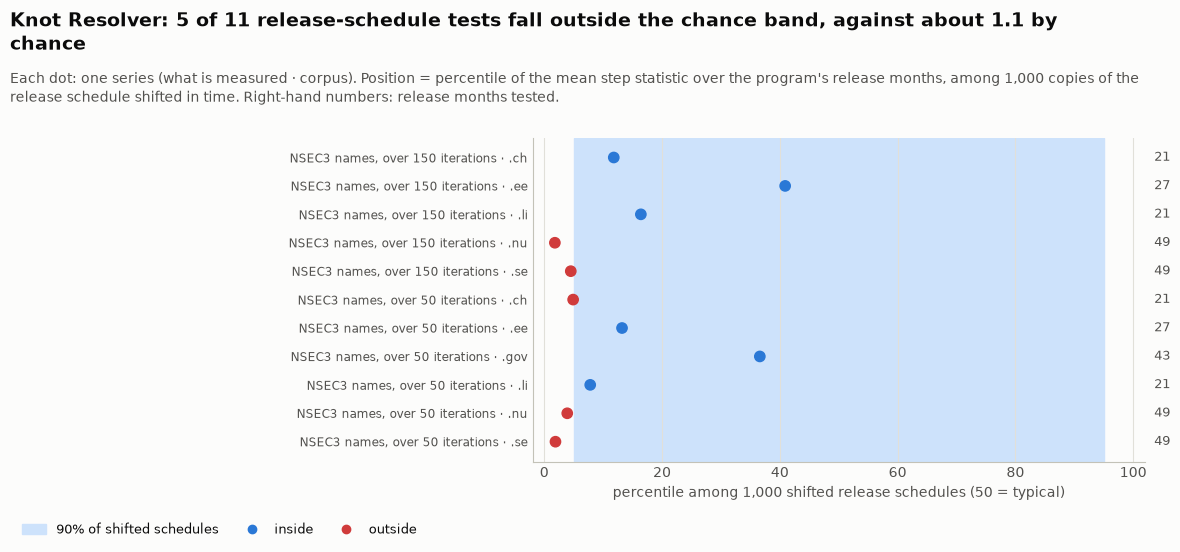

**How to read it.** One dot per series tested. Dots in the band mean that the months right after Knot Resolver releases look like any other months. 5 of 11 are outside, against 1.1 expected by chance. Outside: NSEC3 names, over 50 iterations in .se (p = 0.038); NSEC3 names, over 50 iterations in .nu (p = 0.078); NSEC3 names, over 50 iterations in .ch (p = 0.098); NSEC3 names, over 150 iterations in .se (p = 0.090); NSEC3 names, over 150 iterations in .nu (p = 0.036).

**Series not tested** (3, besides .fed.us, which is never signed): 2 because the series is too short; 1 because the value is present in fewer than 12 months.

In [35]:
q1_release_dots("kresd")
q1_summary("kresd")
q1_untestable("kresd")

#### Knot Resolver: CVE fix latency

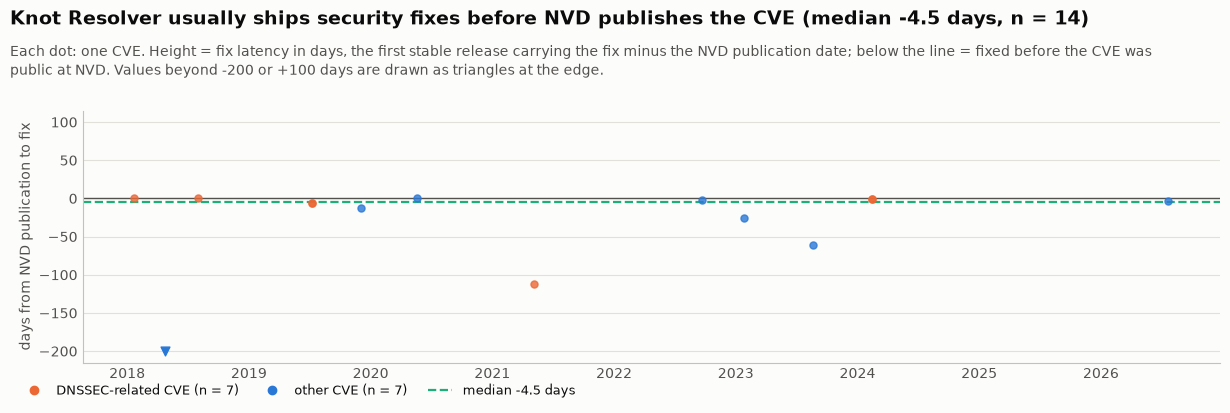

**How to read it.** Negative days are normal for embargoed security releases: the vendor tags the fix a few days before the CVE goes public. The middle half of Knot Resolver's fixes lie between -22.5 and -1 days. 1 CVE(s) fall beyond the axis and are drawn at the edge. 3 of 14 CVEs were fixed in a release dated the same day NVD published them, so they sit on the zero line on top of each other.

In [36]:
cve_strip("kresd")

#### Verdict for Knot Resolver

In [37]:
verdict("kresd")

**Adoption (share of domains signed, section 2b).** release schedule: 3 of 19 tests unusual, about 1.9 expected (DNSKEY in .ch, more domains signed than the trend predicted; DS in .ch, more domains signed than the trend predicted; RRSIG in .ch, more domains signed than the trend predicted); none of its default changes could change whether zones get signed.

**Feature use.** Some Knot Resolver feature-use results fall outside the band more often than chance (8 of 26 tests, against about 2.6); they are timing, not attribution, and are listed below.

**Releases.** 5 of 11 program-level step tests fall outside the chance band, against about 1.1 by chance. Outside: NSEC3 names, over 150 iterations in .se, p = 0.090 (lower than under shifted schedules, in the direction its defaults push; every gap is under 0.01 pp, so the share barely moved); NSEC3 names, over 150 iterations in .nu, p = 0.036 (lower than under shifted schedules, in the direction its defaults push; every gap is under 0.01 pp, so the share barely moved); NSEC3 names, over 50 iterations in .se, p = 0.038 (lower than under shifted schedules, in the direction its defaults push); NSEC3 names, over 50 iterations in .nu, p = 0.078 (lower than under shifted schedules, in the direction its defaults push); NSEC3 names, over 50 iterations in .ch, p = 0.098 (lower than under shifted schedules, in the direction its defaults push).

**Default changes.** 3 of 15 step tests fall outside the chance band, against about 1.5 by chance. Outside: kresd[9]@5.3.1 in .se, -0.00012 pp at percentile 3.1, in the expected direction, a change of under 0.01 percentage points; the share barely moved; kresd[15]@6.0.6 in .ch, -0.058 pp at percentile 4.9, in the expected direction; kresd[15]@6.0.6 in .li, -0.84 pp at percentile 4.3, in the expected direction.

**Key default changes.** the NSEC3 cap of 150 (kresd[9]@5.3.1): percentile 3 in .se, 27 in .nu, 92 in .gov.

**Security fixes.** Median -4.5 days from NVD publication (n = 14).

### 3.5 NSD

NSD is an authoritative server that serves DNSSEC but does not sign. Its default changes are compile-time switches
(for example, DNSSEC support on by default) that no zone file records.

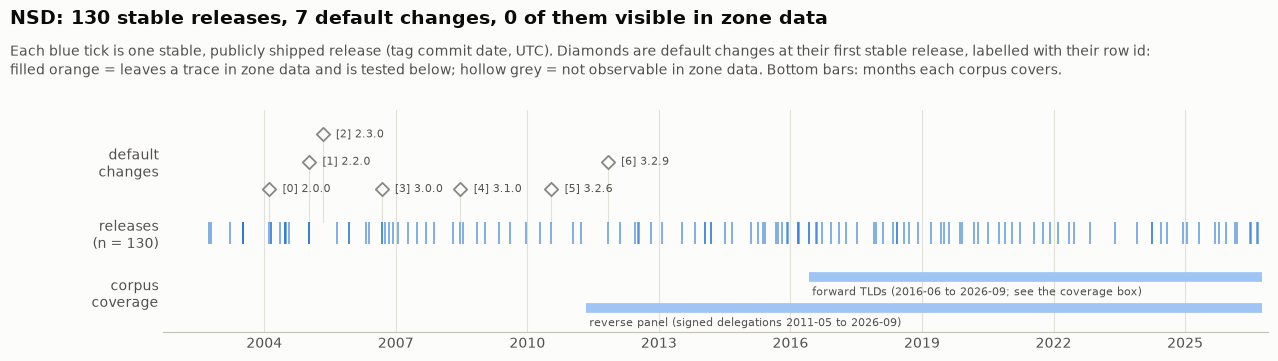

**How to read it.** Time runs left to right. NSD shipped 130 stable public releases on 119 different days; with parallel branches counted once, the median gap between releases is 68.5 days. Of its 7 default changes, 0 can be seen in zone data at all; only those can be tested against the zone data, and only when they fall inside a covered stretch of a corpus with 24 months of data before them.

In [38]:
cadence_strip("nsd")

#### Default changes of NSD and what the step test found

In [39]:
q2_table("nsd")
q2_dotplot("nsd")

No default change of NSD maps to anything the zone data records, so there is nothing to test here. This is not a null result: the data simply cannot see these changes.

#### Does feature use shift after NSD's releases?

NSD has no default change that alters a feature the zone files record, so its release schedule is not tested against any feature-use series. It is tested against adoption: see the verdict below.

#### NSD: CVE fix latency

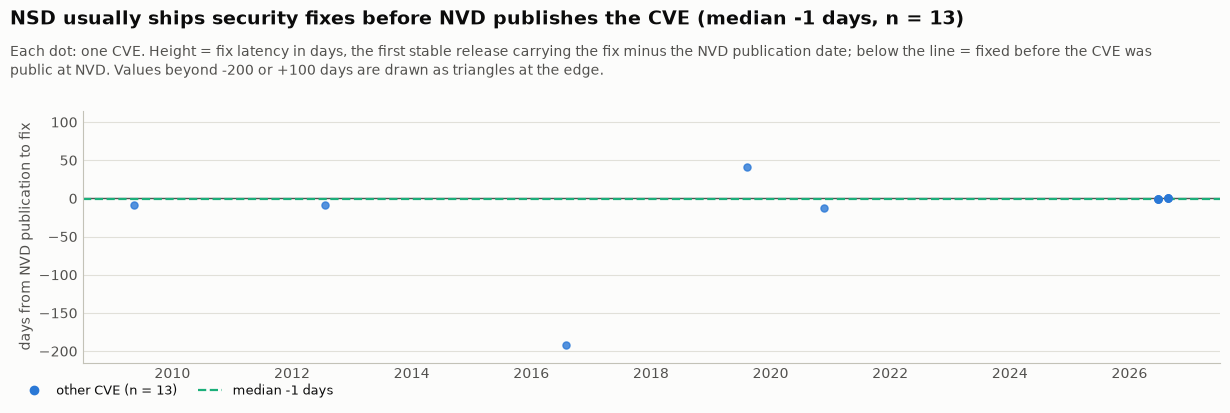

**How to read it.** Negative days are normal for embargoed security releases: the vendor tags the fix a few days before the CVE goes public. The middle half of NSD's fixes lie between -8 and +0 days. 0 CVE(s) fall beyond the axis and are drawn at the edge. 4 of 13 CVEs were fixed in a release dated the same day NVD published them, so they sit on the zero line on top of each other.

In [40]:
cve_strip("nsd")

#### Verdict for NSD

In [41]:
verdict("nsd")

**Adoption (share of domains signed, section 2b).** release schedule: 5 of 19 tests unusual, about 1.9 expected (DNSKEY in .gov, more domains signed than the trend predicted; DNSKEY in .ch, more domains signed than the trend predicted; DS in .ch, more domains signed than the trend predicted; RRSIG in .gov, more domains signed than the trend predicted; RRSIG in .ch, more domains signed than the trend predicted); its 4 default change(s) that could change signing have no step test (there are not enough months before the event).

**Feature use.** The zone data cannot show whether feature use follows NSD: none of its default changes changes a feature the zone files record.

Nothing to test for feature use: no NSD default change alters a feature the zone files record, so there is no feature-use test of its defaults or releases. This is 'not observable', not 'no effect'; its adoption result is above.

**Security fixes.** Median -1 days from NVD publication (n = 13).

### 3.6 OpenDNSSEC

OpenDNSSEC is a signer: a key and signing policy enforcer plus a signing engine. Its most important default change,
the switch from algorithm 7 to 8 (row id 1.2.0b1, first stable release 1.2.0, 2011-03), predates every corpus.

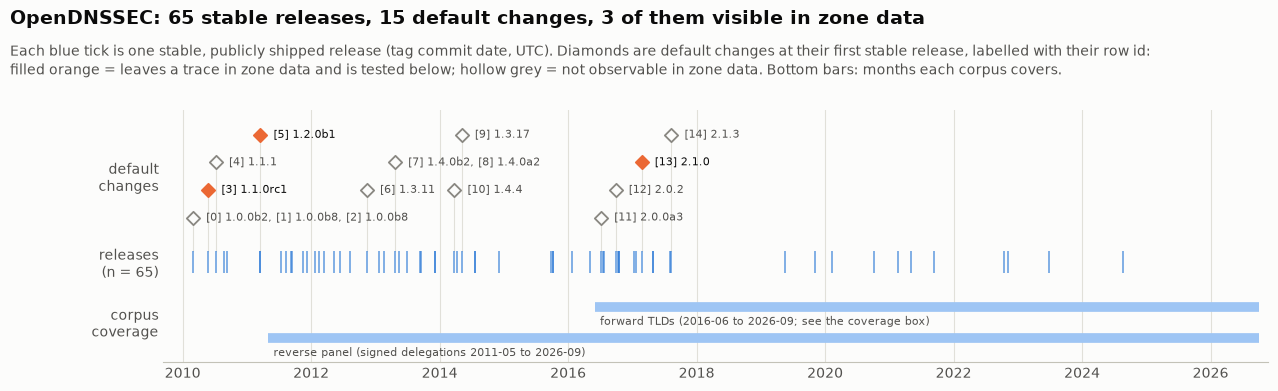

**How to read it.** Time runs left to right. OpenDNSSEC shipped 65 stable public releases on 60 different days; with parallel branches counted once, the median gap between releases is 61 days. Of its 15 default changes, 3 can be seen in zone data at all; only those can be tested against the zone data, and only when they fall inside a covered stretch of a corpus with 24 months of data before them.

In [42]:
cadence_strip("opendnssec")

#### Default changes of OpenDNSSEC and what the step test found

row,first stable release,what it changes,expected,on upgrade / opt-in,"step test percentile, per corpus",why some corpora have no test
opendnssec[3]@1.1.0rc1,2010-05-26,"NSEC3 owner names with the opt-out flag (forward only; owner names, not zones)",down,no / no,no test,"no before-period: series valid from 2016-06, needs 2008-05; no before-period: series valid from 2017-05, needs 2008-05; no before-period: series valid from 2019"
opendnssec[5]@1.2.0b1,2011-03-18,RSASHA256 (algorithm 8) share,up,no / no,no test,"no before-period: series valid from 2011-05, needs 2009-04; no before-period: series valid from 2016-06, needs 2009-03; no before-period: series valid from 2017"
opendnssec[5]@1.2.0b1,2011-03-18,RSASHA1-NSEC3-SHA1 (algorithm 7) share,down,no / no,no test,"no before-period: series valid from 2011-05, needs 2009-04; no before-period: series valid from 2016-06, needs 2009-03; no before-period: series valid from 2017"
opendnssec[13]@2.1.0,2017-02-22,SHA-1 DS (digest 1) share of DS-carrying delegations,down,yes / no,reverse panel 59,"no before-period: series valid from 2016-06, needs 2015-02; no before-period: series valid from 2017-05, needs 2015-02; no before-period: series valid from 2020"


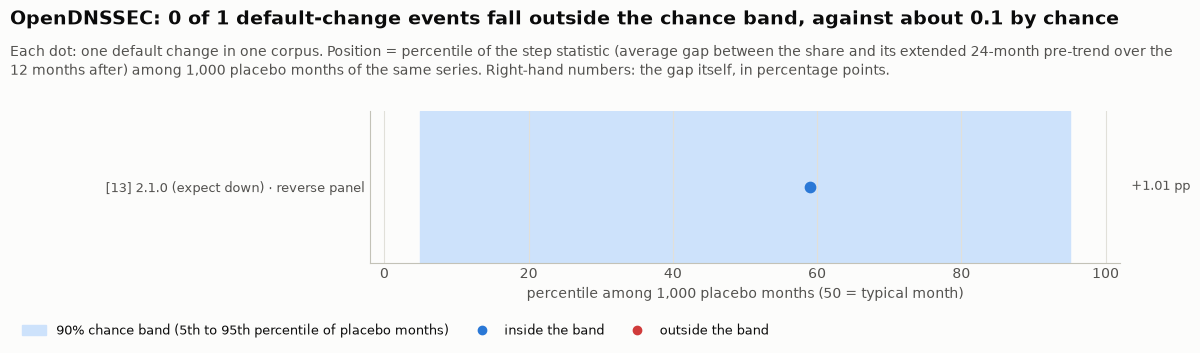

**How to read it.** A dot far right means the share ended up *higher* than its own trend predicted, far left *lower*. Only dots outside the shaded band are unusual, and even with no effect anywhere about 1 in 10 lands outside. Here 0 of 1 are outside, against 0.1 expected by chance.

In [43]:
q2_table("opendnssec")
q2_dotplot("opendnssec")

#### Does feature use shift after OpenDNSSEC's releases?

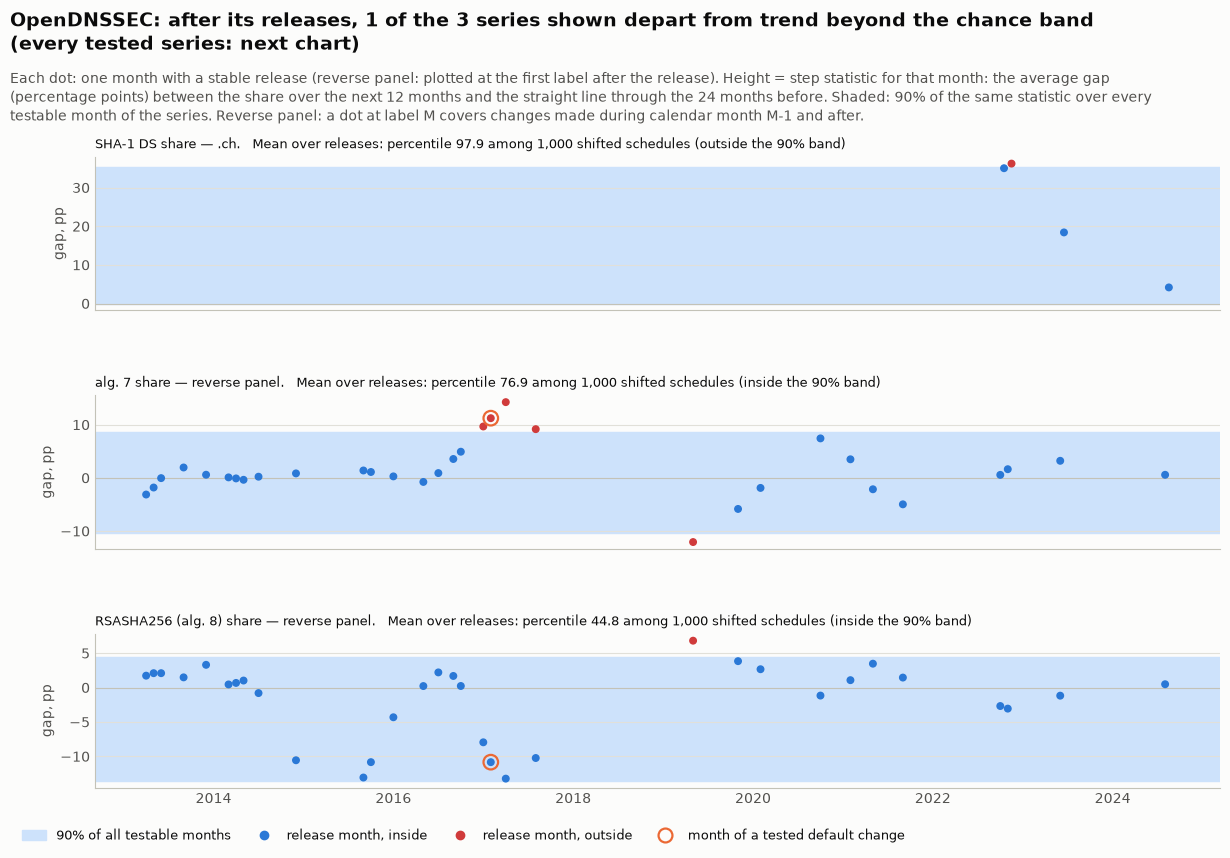

**How to read it.** If releases pushed feature use, the dots would sit mostly above (or below) the shaded band. Dots scattered across it, with a few outside, is what any random set of months looks like. SHA-1 DS share in .ch: 25% of 4 release months outside the band, against 6% under shifted schedules; alg. 7 share in reverse panel: 16% of 32 release months outside the band, against 11% under shifted schedules; RSASHA256 (alg. 8) share in reverse panel: 3% of 32 release months outside the band, against 11% under shifted schedules. Neighbouring dots form smooth waves because consecutive months share 11 of their 12 after-months; that is why the test shifts the whole schedule instead of counting dots, and why the title reports the test, not the dots. An orange ring marks a release month that is also the month of a tested default change. Series with a result outside the band are shown first. Series shown: up to three, one per observable, the reverse panel first where tested; every tested series is in the next chart.

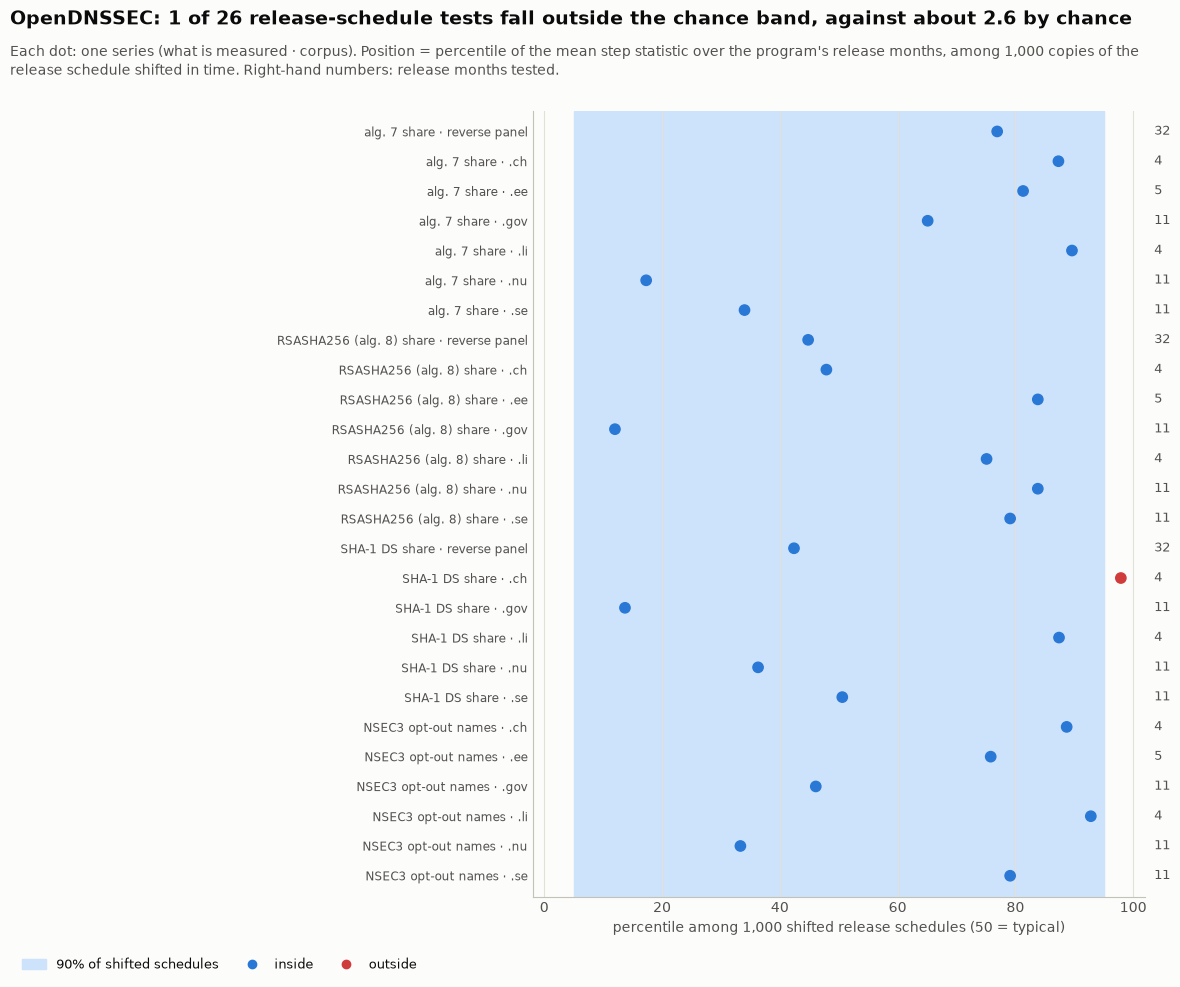

**How to read it.** One dot per series tested. Dots in the band mean that the months right after OpenDNSSEC releases look like any other months. 1 of 26 are outside, against 2.6 expected by chance. Outside: SHA-1 DS share in .ch (p = 0.042).

**Series not tested** (5, besides .fed.us, which is never signed): 4 because the series is too short; 1 because the value never appears in that corpus.

In [44]:
q1_release_dots("opendnssec")
q1_summary("opendnssec")
q1_untestable("opendnssec")

#### OpenDNSSEC: CVE fix latency

In [45]:
cve_strip("opendnssec")

**No CVE latency chart for OpenDNSSEC:** it has no included CVE with a fix release and an NVD date (OpenDNSSEC's only CVE, CVE-2012-5582, has no fix commit in the repository).

#### Verdict for OpenDNSSEC

In [46]:
verdict("opendnssec")

**Adoption (share of domains signed, section 2b).** release schedule: 6 of 19 tests unusual, about 1.9 expected (DNSKEY in .se, fewer domains signed than the trend predicted; DNSKEY in .ch, fewer domains signed than the trend predicted; DS in .se, fewer domains signed than the trend predicted; DS in .ch, fewer domains signed than the trend predicted; RRSIG in .se, fewer domains signed than the trend predicted; RRSIG in .ch, fewer domains signed than the trend predicted); none of its default changes could change whether zones get signed.

**Feature use.** Feature use does not shift after OpenDNSSEC's releases or default changes more often than chance: 1 of 27 tests fall outside the band, against about 2.7. Of the results outside the band, 1 against the direction the program's defaults would push.

**Releases.** 1 of 26 program-level step tests fall outside the chance band, against about 2.6 by chance. Outside: SHA-1 DS share in .ch, p = 0.042 (higher than under shifted schedules, against the direction its defaults push).

**Default changes.** 0 of 1 step tests fall outside the chance band, against about 0.1 by chance.

**Key default changes.** SHA-256-only DS export in 2.1.0 (opendnssec[13]@2.1.0): percentile 59 in reverse panel.

**Reverse ledger (section 5).** opendnssec[5]@1.2.0b1: large-action p = 0.719, block-level p = 0.875.

**Security fixes.** No datable CVE fix (CVE-2012-5582 has no fix commit).

### 3.7 PowerDNS Authoritative

PowerDNS Authoritative serves and signs zones. Its ECDSA default of 4.0.0 (2016-07) is the second ECDSA signing
default after Knot's, and its RSASHA256 default of 3.2 (2013-01) gives the smallest p in section 5, which rests on
one RIPE block that may have changed before the release.

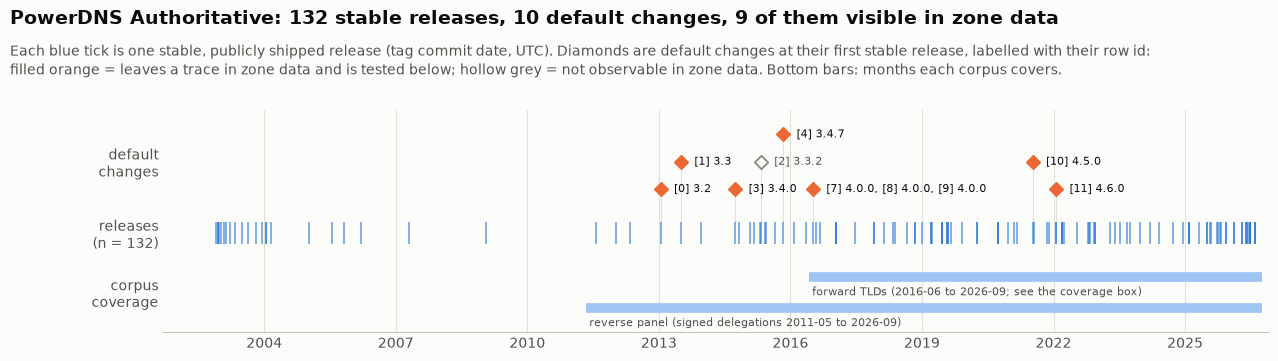

**How to read it.** Time runs left to right. PowerDNS Authoritative shipped 132 stable public releases on 112 different days; with parallel branches counted once, the median gap between releases is 50 days. Of its 10 default changes, 9 can be seen in zone data at all; only those can be tested against the zone data, and only when they fall inside a covered stretch of a corpus with 24 months of data before them.

In [47]:
cadence_strip("pdns-auth")

#### Default changes of PowerDNS Authoritative and what the step test found

row,first stable release,what it changes,expected,on upgrade / opt-in,"step test percentile, per corpus",why some corpora have no test
pdns-auth[0]@3.2,2013-01-17,RSASHA256 (algorithm 8) share,up,no / no,no test,"no before-period: series valid from 2011-05, needs 2011-02; no before-period: series valid from 2016-06, needs 2011-01; no before-period: series valid from 2017"
pdns-auth[1]@3.3,2013-07-05,"NSEC3 owner names with the opt-out flag (forward only; owner names, not zones)",down,no / yes,no test,"no before-period: series valid from 2016-06, needs 2011-07; no before-period: series valid from 2017-05, needs 2011-07; no before-period: series valid from 2019"
pdns-auth[3]@3.4.0,2014-09-30,NSEC3 owner names above 500 iterations (forward only),down,yes / no,no test,"no before-period: series valid from 2016-06, needs 2012-09; no before-period: series valid from 2020-05, needs 2012-09; no month with at least 30; the value nev"
pdns-auth[4]@3.4.7,2015-11-03,NSEC3 owner names above 500 iterations (forward only),down,yes / no,no test,"no before-period: series valid from 2016-06, needs 2013-11; no before-period: series valid from 2020-05, needs 2013-11; no month with at least 30; the value nev"
pdns-auth[7]@4.0.0,2016-07-08,ECDSAP256SHA256 (algorithm 13) share,up,no / no,reverse panel 57,"no before-period: series valid from 2016-06, needs 2014-07; no before-period: series valid from 2017-05, needs 2014-07; no before-period: series valid from 2019"
pdns-auth[8]@4.0.0,2016-07-08,ECDSAP256SHA256 (algorithm 13) share,up,no / no,reverse panel 59,"no before-period: series valid from 2016-06, needs 2014-07; no before-period: series valid from 2017-05, needs 2014-07; no before-period: series valid from 2019"
pdns-auth[9]@4.0.0,2016-07-08,"1024-bit RSA keys, share of names with an RSA key (forward only)",down,no / no,no test,"no before-period: series valid from 2016-06, needs 2014-07; no before-period: series valid from 2017-05, needs 2014-07; no before-period: series valid from 2019"
pdns-auth[10]@4.5.0,2021-07-12,NSEC3 owner names above 100 iterations (forward only),down,yes / no,.se 32; .nu 81; .gov 93; .ee 23,"no before-period: series valid from 2020-05, needs 2019-07; no before-period: series valid from 2022-08, needs 2019-07; no month with at least 30"
pdns-auth[11]@4.6.0,2022-01-24,"NSEC3 owner names with 0 iterations, share of NSEC3 owner names (forward only)",up,no / yes,.se 66; .nu 64; .gov 49; .ee 46,"no before-period: series valid from 2020-05, needs 2020-01; no before-period: series valid from 2022-08, needs 2020-01; no month with at least 30"


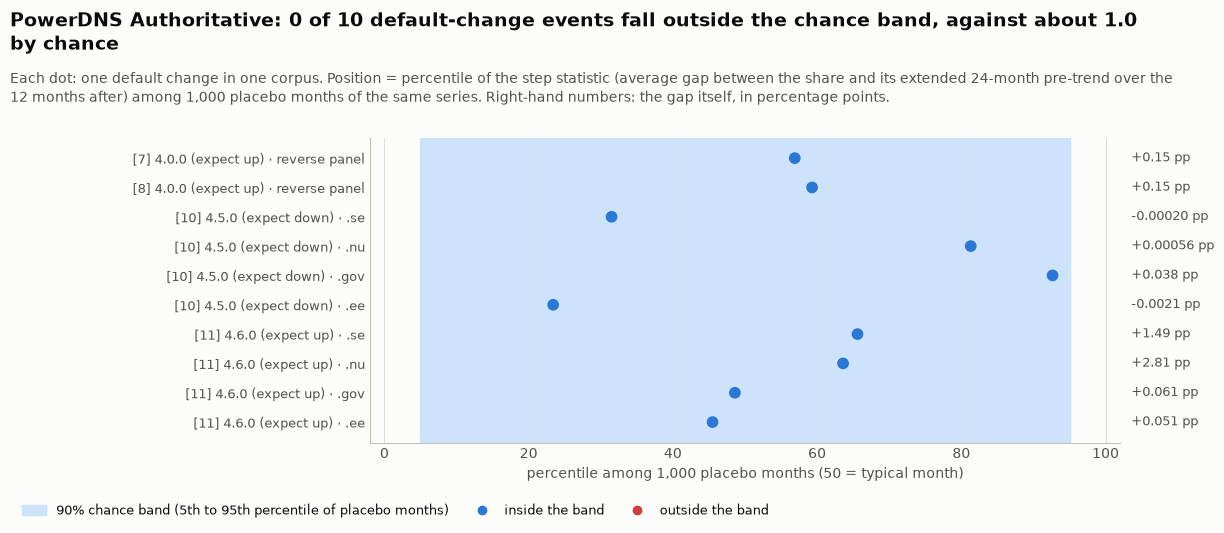

**How to read it.** A dot far right means the share ended up *higher* than its own trend predicted, far left *lower*. Only dots outside the shaded band are unusual, and even with no effect anywhere about 1 in 10 lands outside. Here 0 of 10 are outside, against 1.0 expected by chance.

In [48]:
q2_table("pdns-auth")
q2_dotplot("pdns-auth")

#### Does feature use shift after PowerDNS Authoritative's releases?

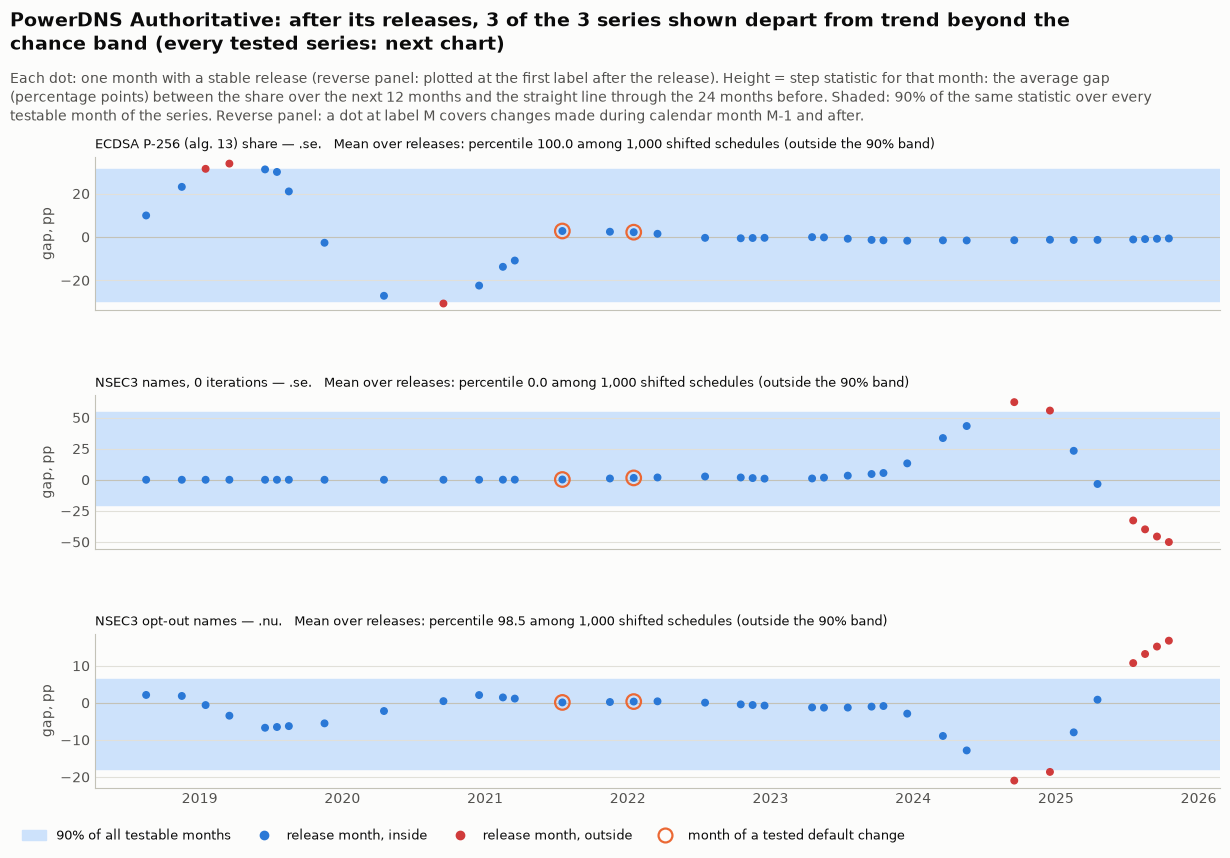

**How to read it.** If releases pushed feature use, the dots would sit mostly above (or below) the shaded band. Dots scattered across it, with a few outside, is what any random set of months looks like. ECDSA P-256 (alg. 13) share in .se: 8% of 37 release months outside the band, against 11% under shifted schedules; NSEC3 names, 0 iterations in .se: 16% of 37 release months outside the band, against 11% under shifted schedules; NSEC3 opt-out names in .nu: 16% of 37 release months outside the band, against 11% under shifted schedules. Neighbouring dots form smooth waves because consecutive months share 11 of their 12 after-months; that is why the test shifts the whole schedule instead of counting dots, and why the title reports the test, not the dots. An orange ring marks a release month that is also the month of a tested default change. Series with a result outside the band are shown first. Series shown: up to three, one per observable, the reverse panel first where tested; every tested series is in the next chart.

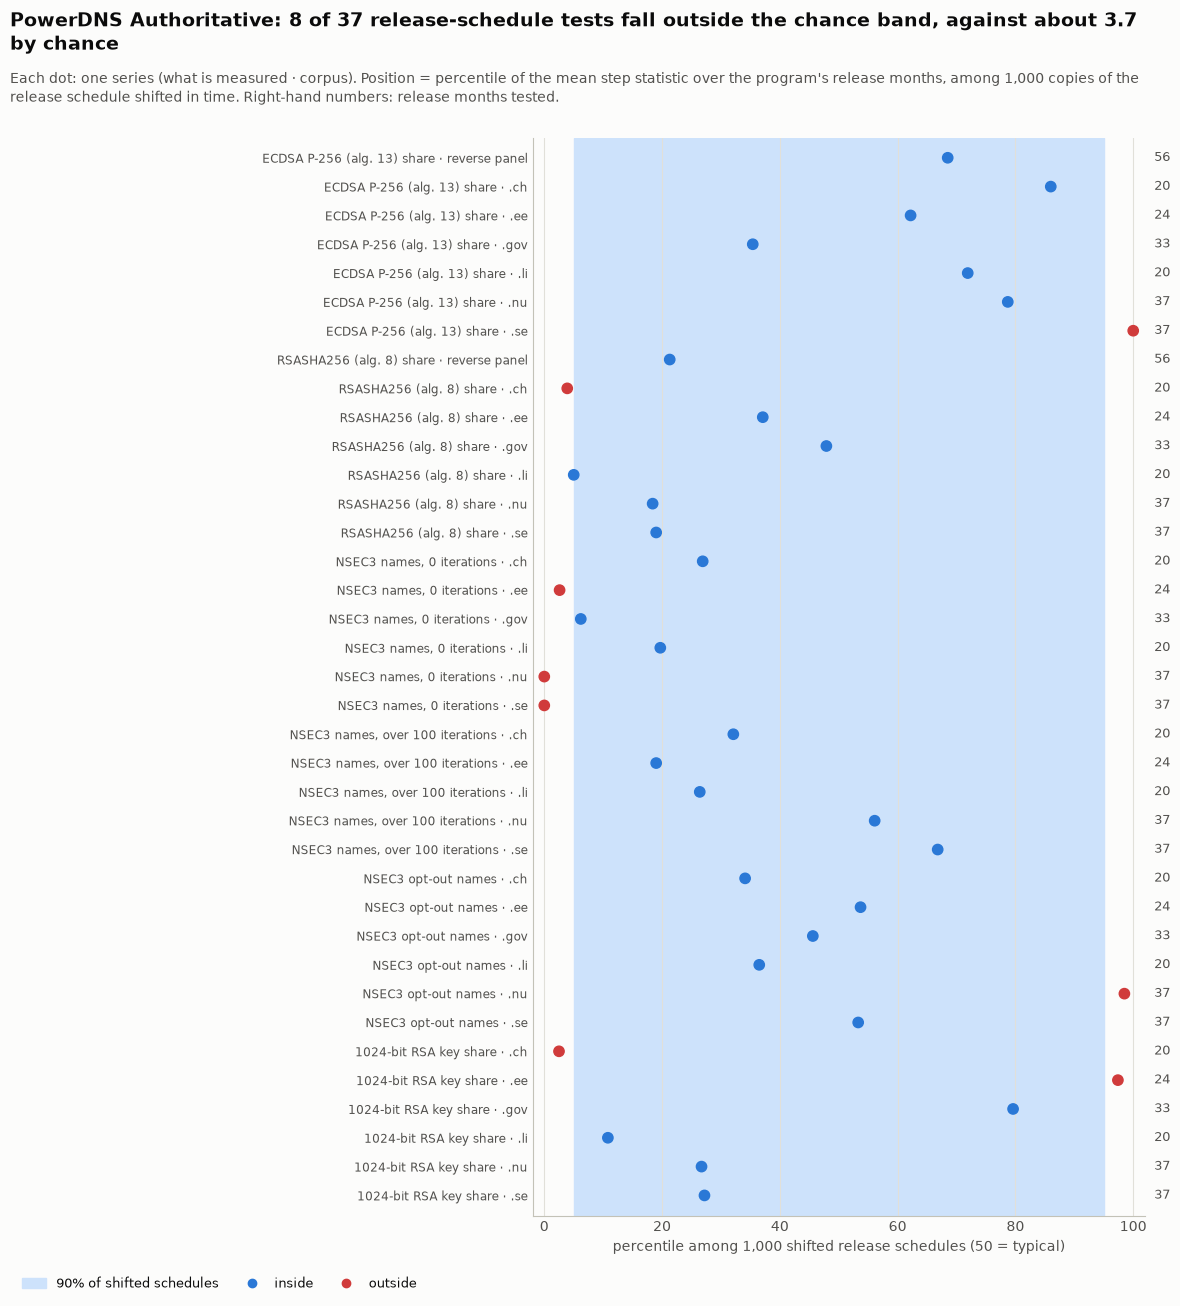

**How to read it.** One dot per series tested. Dots in the band mean that the months right after PowerDNS Authoritative releases look like any other months. 8 of 37 are outside, against 3.7 expected by chance. Outside: 1024-bit RSA key share in .ee (p = 0.052); 1024-bit RSA key share in .ch (p = 0.050); NSEC3 opt-out names in .nu (p = 0.030); NSEC3 names, 0 iterations in .se (p < 0.001); NSEC3 names, 0 iterations in .nu (p < 0.001); NSEC3 names, 0 iterations in .ee (p = 0.052); RSASHA256 (alg. 8) share in .ch (p = 0.078); ECDSA P-256 (alg. 13) share in .se (p < 0.001).

**Series not tested** (14, besides .fed.us, which is never signed): 6 because the series is too short; 5 because the value never appears in that corpus; 3 because the value is present in fewer than 12 months.

In [49]:
q1_release_dots("pdns-auth")
q1_summary("pdns-auth")
q1_untestable("pdns-auth")

#### PowerDNS Authoritative: CVE fix latency

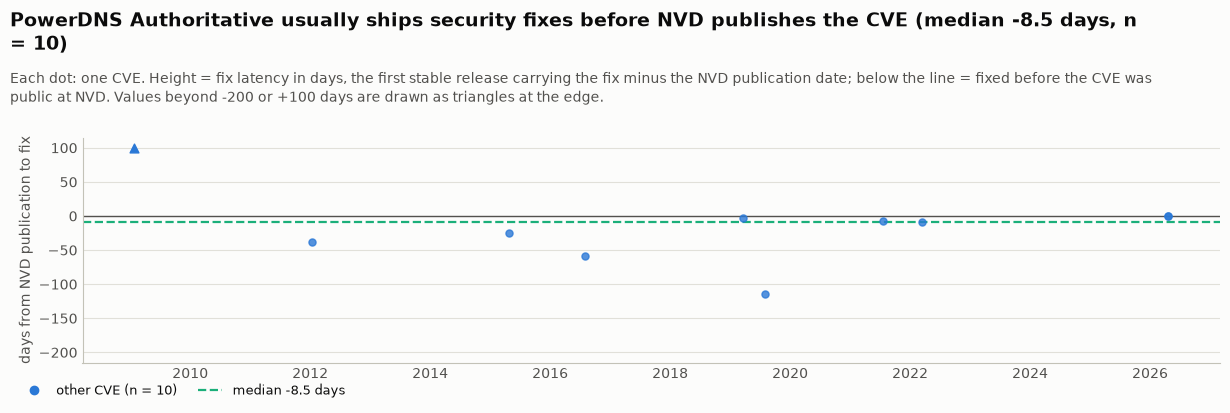

**How to read it.** Negative days are normal for embargoed security releases: the vendor tags the fix a few days before the CVE goes public. The middle half of PowerDNS Authoritative's fixes lie between -34.75 and -0.75 days. 1 CVE(s) fall beyond the axis and are drawn at the edge. 2 of 10 CVEs were fixed in a release dated the same day NVD published them, so they sit on the zero line on top of each other.

In [50]:
cve_strip("pdns-auth")

#### Verdict for PowerDNS Authoritative

In [51]:
verdict("pdns-auth")

**Adoption (share of domains signed, section 2b).** release schedule: 0 of 19 tests unusual, about 1.9 expected; none of its default changes could change whether zones get signed.

**Feature use.** Feature use does not shift after PowerDNS Authoritative's releases or default changes more often than chance: 8 of 47 tests fall outside the band, against about 4.7. Of the results outside the band, 6 against the direction the program's defaults would push.

**Releases.** 8 of 37 program-level step tests fall outside the chance band, against about 3.7 by chance. Outside: ECDSA P-256 (alg. 13) share in .se, p < 0.001 (higher than under shifted schedules, in the direction its defaults push); RSASHA256 (alg. 8) share in .ch, p = 0.078 (lower than under shifted schedules, against the direction its defaults push); NSEC3 names, 0 iterations in .se, p < 0.001 (lower than under shifted schedules, against the direction its defaults push); NSEC3 names, 0 iterations in .nu, p < 0.001 (lower than under shifted schedules, against the direction its defaults push); NSEC3 names, 0 iterations in .ee, p = 0.052 (lower than under shifted schedules, against the direction its defaults push); NSEC3 opt-out names in .nu, p = 0.030 (higher than under shifted schedules, against the direction its defaults push); 1024-bit RSA key share in .ee, p = 0.052 (higher than under shifted schedules, against the direction its defaults push); 1024-bit RSA key share in .ch, p = 0.050 (lower than under shifted schedules, in the direction its defaults push).

**Default changes.** 0 of 10 step tests fall outside the chance band, against about 1.0 by chance.

**Key default changes.** the ECDSA default of 4.0.0 (pdns-auth[7]@4.0.0): percentile 57 in reverse panel; the opt-in zero-iteration default of 4.6.0 (pdns-auth[11]@4.6.0): percentile 66 in .se, 64 in .nu, 49 in .gov, 46 in .ee.

**Reverse ledger (section 5).** pdns-auth[0]@3.2: large-action p = 0.060, block-level p = 0.098 (this is one RIPE block (216.151.in-addr.arpa, 64 of the window's 73 matching delegations) signed during January 2013, possibly before the release on the 17th); pdns-auth[7]@4.0.0: large-action p = 0.669, block-level p = 0.178; pdns-auth[8]@4.0.0: large-action p = 0.658, block-level p = 0.172.

**Security fixes.** Median -8.5 days from NVD publication (n = 10).

### 3.8 PowerDNS Recursor

PowerDNS Recursor is a validating resolver. Its tags rec-4.5.0, rec-4.5.3 and rec-5.0.0 were never shipped publicly
and are left out; only its NSEC3 caps map to zone data, indirectly.

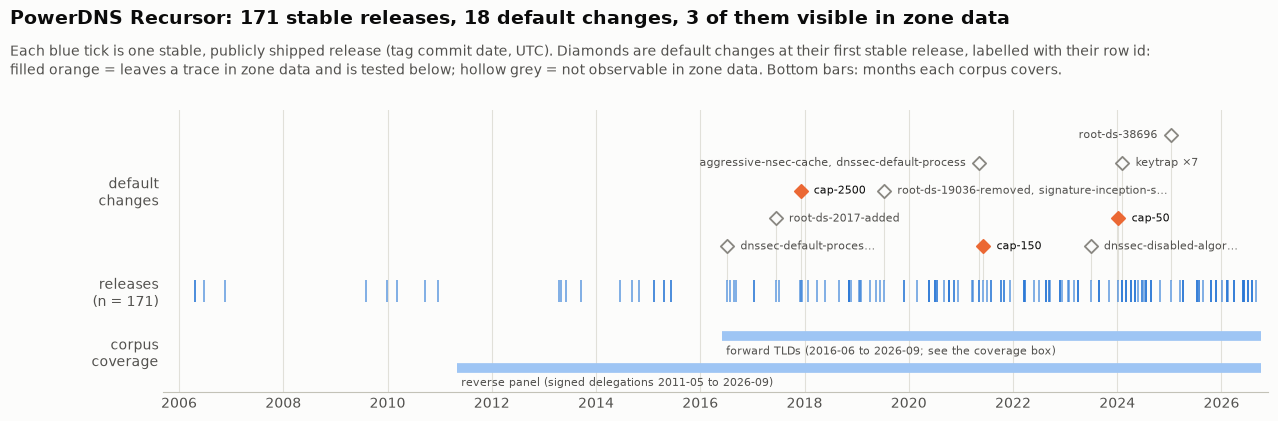

The label 'keytrap ×7' stands for keytrap-aggressive-cache-max-nsec3-hash-cost, keytrap-max-dnskeys, keytrap-max-ds-per-zone, keytrap-max-nsec3-hash-computations-per-query, keytrap-max-nsec3s-per-record, keytrap-max-rrsigs-per-record, keytrap-max-signature-validations-per-query. **How to read it.** Time runs left to right. PowerDNS Recursor shipped 171 stable public releases on 117 different days; with parallel branches counted once, the median gap between releases is 34.5 days. Of its 18 default changes, 3 can be seen in zone data at all; only those can be tested against the zone data, and only when they fall inside a covered stretch of a corpus with 24 months of data before them.

In [52]:
cadence_strip("pdns-rec")

#### Default changes of PowerDNS Recursor and what the step test found

row,first stable release,what it changes,expected,on upgrade / opt-in,"step test percentile, per corpus",why some corpora have no test
nsec3-max-iterations-2500,2017-12-04,NSEC3 owner names above 2500 iterations (forward only),down,yes / no,no test,no month with at least 30; the value never appears
nsec3-max-iterations-150,2021-06-07,NSEC3 owner names above 150 iterations (forward only),down,yes / no,.se 3 (outside); .nu 21; .gov 92,"no before-period: series valid from 2019-07, needs 2019-06; no before-period: series valid from 2020-05, needs 2019-06; no before-period: series valid from 2022"
nsec3-max-iterations-50,2024-01-09,NSEC3 owner names above 50 iterations (forward only),down,yes / no,.se 44; .nu 58; .gov 66; .ee 19; .ch 0 (outside); .li 0 (outside),"no before-period: series valid from 2022-08, needs 2022-01; no month with at least 30"


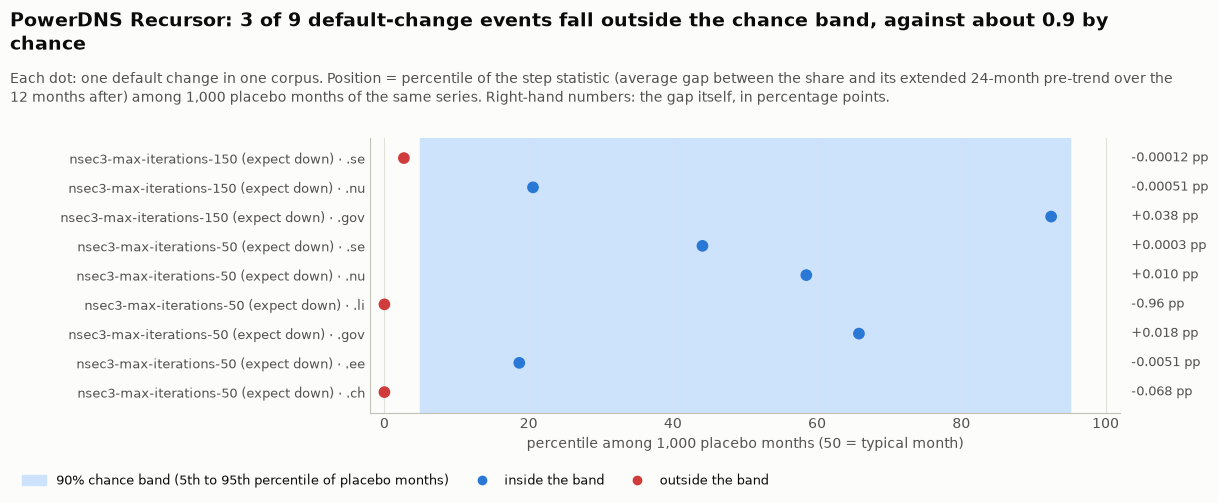

**How to read it.** A dot far right means the share ended up *higher* than its own trend predicted, far left *lower*. Only dots outside the shaded band are unusual, and even with no effect anywhere about 1 in 10 lands outside. Here 3 of 9 are outside, against 0.9 expected by chance. Outside: nsec3-max-iterations-50 in .ch at percentile 0.0 (-0.068 pp, in the expected direction); nsec3-max-iterations-50 in .li at percentile 0.0 (-0.96 pp, in the expected direction); nsec3-max-iterations-150 in .se at percentile 2.7 (-0.00012 pp, a change of under 0.01 percentage points; the share barely moved, in the expected direction).

In [53]:
q2_table("pdns-rec")
q2_dotplot("pdns-rec")

#### Does feature use shift after PowerDNS Recursor's releases?

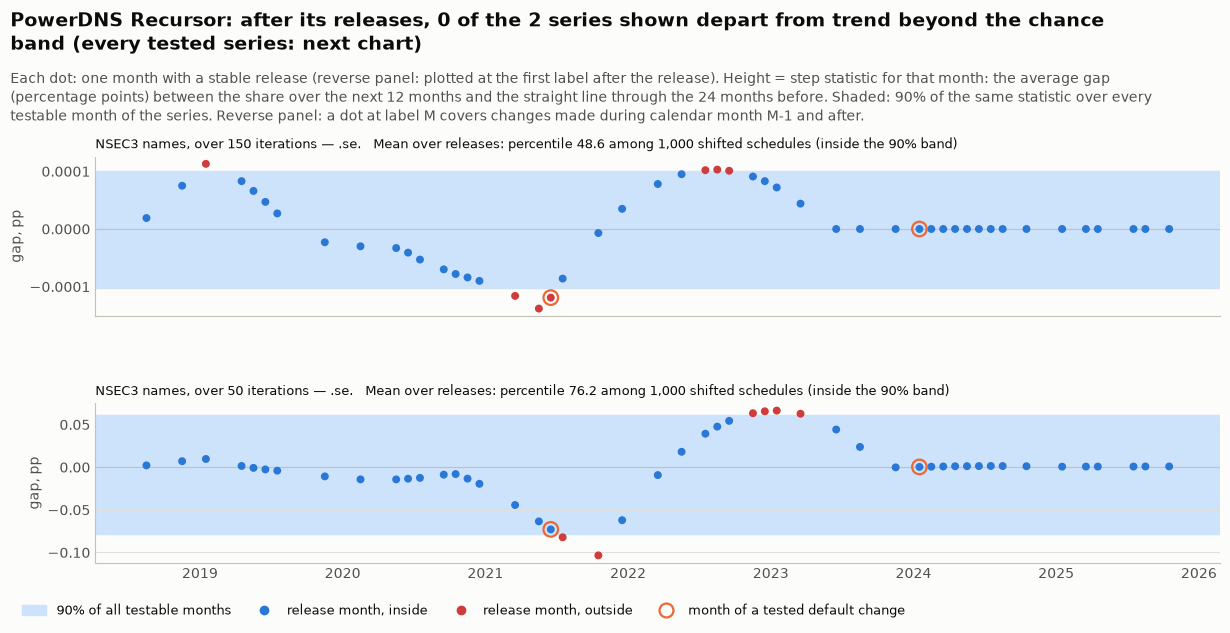

**How to read it.** If releases pushed feature use, the dots would sit mostly above (or below) the shaded band. Dots scattered across it, with a few outside, is what any random set of months looks like. NSEC3 names, over 150 iterations in .se: 14% of 49 release months outside the band, against 11% under shifted schedules; every gap in this series is under 0.01 pp, so the share barely moves and an 'outside' result here is a ranking artefact, not a real change; NSEC3 names, over 50 iterations in .se: 12% of 49 release months outside the band, against 11% under shifted schedules. Neighbouring dots form smooth waves because consecutive months share 11 of their 12 after-months; that is why the test shifts the whole schedule instead of counting dots, and why the title reports the test, not the dots. An orange ring marks a release month that is also the month of a tested default change. Series with a result outside the band are shown first. Series shown: up to three, one per observable, the reverse panel first where tested; every tested series is in the next chart.

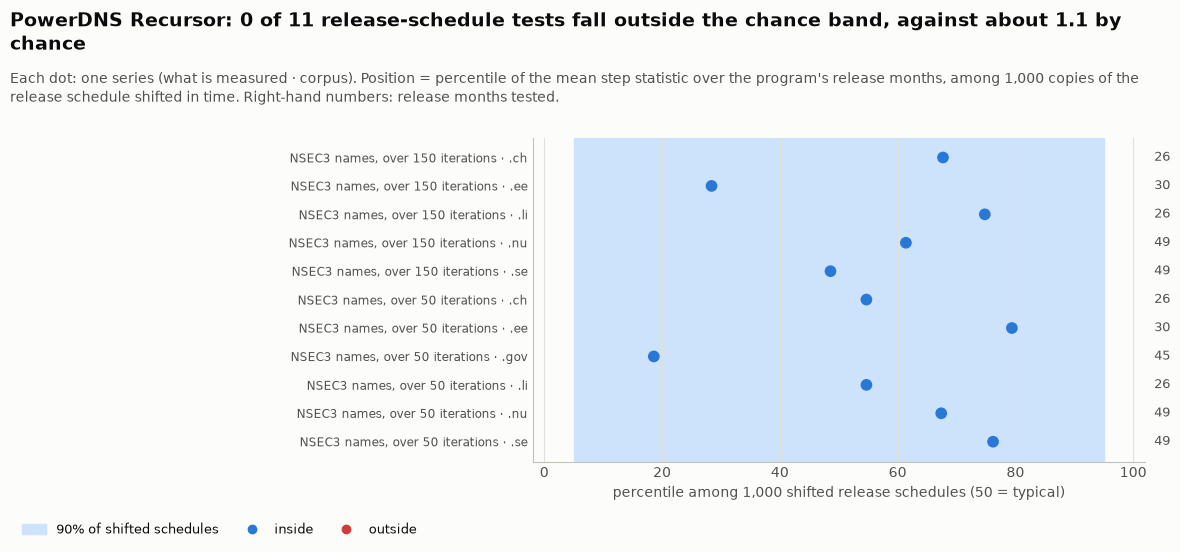

**How to read it.** One dot per series tested. Dots in the band mean that the months right after PowerDNS Recursor releases look like any other months. 0 of 11 are outside, against 1.1 expected by chance.

**Series not tested** (10, besides .fed.us, which is never signed): 7 because the value never appears in that corpus; 2 because the series is too short; 1 because the value is present in fewer than 12 months.

In [54]:
q1_release_dots("pdns-rec")
q1_summary("pdns-rec")
q1_untestable("pdns-rec")

#### PowerDNS Recursor: CVE fix latency

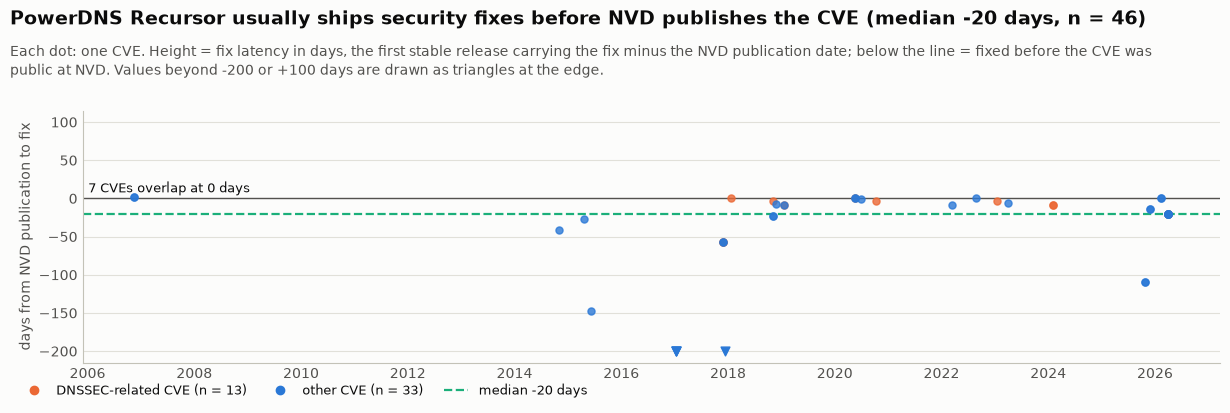

**How to read it.** Negative days are normal for embargoed security releases: the vendor tags the fix a few days before the CVE goes public. The middle half of PowerDNS Recursor's fixes lie between -37.5 and -3.25 days. 4 CVE(s) fall beyond the axis and are drawn at the edge. 7 of 46 CVEs were fixed in a release dated the same day NVD published them, so they sit on the zero line on top of each other.

In [55]:
cve_strip("pdns-rec")

#### Verdict for PowerDNS Recursor

In [56]:
verdict("pdns-rec")

**Adoption (share of domains signed, section 2b).** release schedule: 1 of 19 tests unusual, about 1.9 expected (DS in .se, fewer domains signed than the trend predicted); none of its default changes could change whether zones get signed.

**Feature use.** Feature use does not shift after PowerDNS Recursor's releases or default changes more often than chance: 3 of 20 tests fall outside the band, against about 2.0. Of the results outside the band, 1 on series that barely move (under 0.01 pp).

**Releases.** 0 of 11 program-level step tests fall outside the chance band, against about 1.1 by chance.

**Default changes.** 3 of 9 step tests fall outside the chance band, against about 0.9 by chance. Outside: nsec3-max-iterations-150 in .se, -0.00012 pp at percentile 2.7, in the expected direction, a change of under 0.01 percentage points; the share barely moved; nsec3-max-iterations-50 in .ch, -0.068 pp at percentile 0.0, in the expected direction; nsec3-max-iterations-50 in .li, -0.96 pp at percentile 0.0, in the expected direction.

**Key default changes.** the NSEC3 cap of 150 (nsec3-max-iterations-150): percentile 3 in .se, 21 in .nu, 92 in .gov.

**Security fixes.** Median -20 days from NVD publication (n = 46).

## 4. Across programs

The per-program sections asked "does the zone data follow this program?". This section compares the programs with each
other, using Phase 4's verified results: when each mechanism first appears in each program, how far code lags the
RFC, whether any program systematically goes first, and the one release that was clearly coordinated.

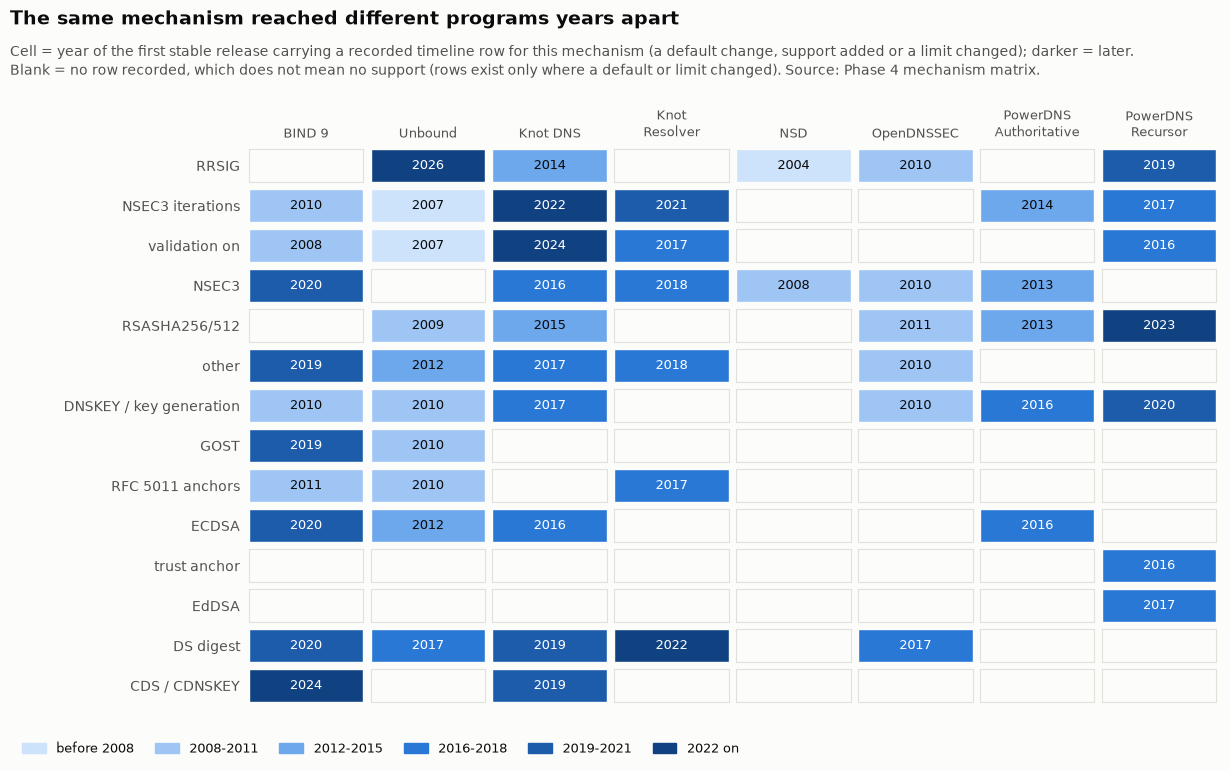

**How to read it.** Rows are DNSSEC mechanisms, columns are programs. A number is the year the program's first recorded row for that mechanism shipped in a stable release. Compare along a row to see who shipped first. The ECDSA row, for example, runs from 2012 (Unbound, validation) through 2016 (Knot, PowerDNS: signing default) to 2020 (BIND 9's policy default). Empty cells are *not* 'never': NSD does not sign, and Knot Resolver takes its algorithm support from a library, so neither has rows there.

In [57]:
MECH_LABEL = {"validation": "validation on", "trust-anchor": "trust anchor", "trust-anchor-5011": "RFC 5011 anchors",
              "nsec3": "NSEC3", "nsec3-iterations": "NSEC3 iterations", "alg-rsa-sha2": "RSASHA256/512",
              "alg-ecdsa": "ECDSA", "alg-eddsa": "EdDSA", "alg-gost": "GOST", "dnskey": "DNSKEY / key generation",
              "ds-digest": "DS digest", "cds-cdnskey": "CDS / CDNSKEY", "rrsig": "RRSIG", "other": "other"}
mat = MAT4.assign(year=MAT4.first_stable_date.str[:4].astype(int))
first = mat.groupby(["mechanism", "program"]).year.min().unstack()
order = mat.groupby("mechanism").year.min().sort_values().index
first = first.reindex(index=order, columns=[p for p in NAME if p in first.columns])
bins = [(0, 2007, "before 2008"), (2008, 2011, "2008-2011"), (2012, 2015, "2012-2015"), (2016, 2018, "2016-2018"),
        (2019, 2021, "2019-2021"), (2022, 9999, "2022 on")]
fig, ax = plt.subplots(figsize=(12.5, 1.9 + 0.42 * len(first)))
frame(fig, "The same mechanism reached different programs years apart",
      "Cell = year of the first stable release carrying a recorded timeline row for this mechanism (a default change, "
      "support added or a limit changed); darker = later. Blank = no row recorded, which does not mean no support "
      "(rows exist only where a default or limit changed). Source: Phase 4 mechanism matrix.",
      bottom=0.7, left=0.20, right=0.98)
fig.subplots_adjust(top=fig.subplotpars.top - 0.35 / fig.get_figheight())
for i, mech in enumerate(first.index):
    for j, prog in enumerate(first.columns):
        v = first.loc[mech, prog]
        if pd.isna(v):
            ax.add_patch(plt.Rectangle((j - 0.47, i - 0.42), 0.94, 0.84, facecolor=SURFACE, edgecolor=GRID, lw=0.8))
            continue
        k = next(n for n, (a, b, _) in enumerate(bins) if a <= v <= b)
        ax.add_patch(plt.Rectangle((j - 0.47, i - 0.42), 0.94, 0.84, facecolor=RAMP[k], edgecolor=SURFACE))
        ax.text(j, i, f"{int(v)}", ha="center", va="center", fontsize=9.5, color="white" if k >= 3 else INK)
ax.set_xlim(-0.5, len(first.columns) - 0.5); ax.set_ylim(len(first) - 0.5, -0.5)
ax.set_xticks(range(len(first.columns)))
ax.set_xticklabels([NAME[p].replace("PowerDNS ", "PowerDNS\n").replace("Knot Resolver", "Knot\nResolver") for p in first.columns], fontsize=9.5)
ax.xaxis.tick_top()
ax.set_yticks(range(len(first))); ax.set_yticklabels([MECH_LABEL.get(m, m) for m in first.index])
style(ax, grid=None)
for s_ in ax.spines.values():
    s_.set_visible(False)
legend_below(fig, [Patch(color=RAMP[k], label=lab) for k, (_, _, lab) in enumerate(bins)], ncol=6)
save(fig, "mechanism_matrix")
say("**How to read it.** Rows are DNSSEC mechanisms, columns are programs. A number is the year the program's first "
    "recorded row for that mechanism shipped in a stable release. Compare along a row to see who shipped first. "
    "The ECDSA row, for example, runs from 2012 (Unbound, validation) through 2016 (Knot, PowerDNS: signing "
    "default) to 2020 (BIND 9's policy default). Empty cells are *not* 'never': NSD does not sign, and Knot "
    "Resolver takes its algorithm support from a library, so neither has rows there.")

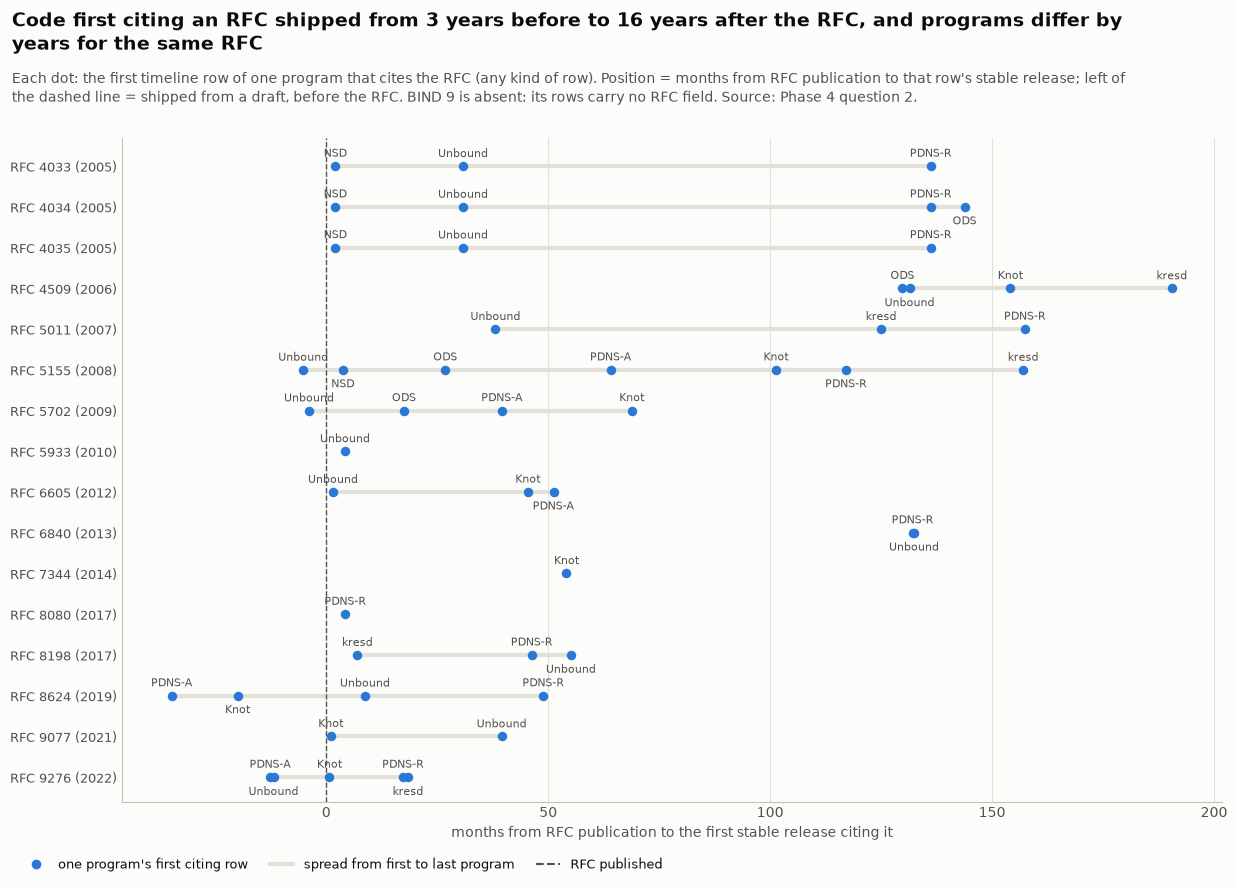

**How to read it.** Each row is one RFC. The dots are the programs, labelled below or above the dot (ODS = OpenDNSSEC, PDNS-A/-R = PowerDNS Authoritative/Recursor). A long grey bar means the programs shipped that RFC's mechanism years apart. Negative lags are real: Unbound shipped NSEC3 and RSASHA256 from drafts, and some 2021 iteration caps were codified by RFC 9276 afterwards. Is one program usually first? Unbound is first 4 times in 11 RFCs, against 3.34 expected if the order were random (p = 0.44); no program is first more often than chance.

In [58]:
q2l = J4["q2_code_lag_vs_rfc"]["per_rfc"]
ABBR = {"bind9": "BIND", "unbound": "Unbound", "knot": "Knot", "kresd": "kresd", "nsd": "NSD",
        "opendnssec": "ODS", "pdns-auth": "PDNS-A", "pdns-rec": "PDNS-R"}
fig, ax = plt.subplots(figsize=(12.5, 1.9 + 0.44 * len(q2l)))
lags = [o["lag_months"] for r in q2l for o in r["order"]]
frame(fig, f"Code first citing an RFC shipped from {-min(lags) / 12:.0f} years before to {max(lags) / 12:.0f} years "
           "after the RFC, and programs differ by years for the same RFC",
      "Each dot: the first timeline row of one program that cites the RFC (any kind of row). Position = months from "
      "RFC publication to that row's stable release; left of the dashed line = shipped from a draft, before the RFC. "
      "BIND 9 is absent: its rows carry no RFC field. Source: Phase 4 question 2.", bottom=0.9, left=0.10)
ax.axvline(0, color=INK_2, ls="--", lw=1)
for i, r in enumerate(q2l):
    xs = [o["lag_months"] for o in r["order"]]
    ax.plot([min(xs), max(xs)], [i, i], color=GRID, lw=3, solid_capstyle="round", zorder=1)
    ax.scatter(xs, [i] * len(xs), s=34, color=S1, zorder=3)
    lastx, prev_up = -1e9, False
    for o in sorted(r["order"], key=lambda o: o["lag_months"]):
        up = (not prev_up) if (o["lag_months"] - lastx) < 16 else True
        ax.text(o["lag_months"], i + (-0.30 if up else 0.36), ABBR[o["program"]], fontsize=7.8, color=INK_2,
                ha="center", va="center")
        lastx, prev_up = o["lag_months"], up
ax.set_yticks(range(len(q2l)))
ax.set_yticklabels([f"{r['rfc']} ({r['publication_date'][:4]})" for r in q2l], fontsize=9)
ax.set_ylim(len(q2l) - 0.4, -0.7)
ax.set_xlabel("months from RFC publication to the first stable release citing it")
style(ax, grid="x")
legend_below(fig, [Line2D([], [], marker="o", ls="", color=S1, label="one program's first citing row"),
                   Line2D([], [], color=GRID, lw=3, label="spread from first to last program"),
                   Line2D([], [], color=INK_2, ls="--", label="RFC published")], ncol=3)
save(fig, "rfc_code_lag")
bl = J4["q2_code_lag_vs_rfc"]["first_to_ship_chance_baseline"]["per_program_same_row_merged"]
ub = next(b for b in bl if b["program"] == "unbound")
say("**How to read it.** Each row is one RFC. The dots are the programs, labelled below or above the dot "
    "(ODS = OpenDNSSEC, PDNS-A/-R = PowerDNS Authoritative/Recursor). A long grey bar means the programs shipped "
    "that RFC's mechanism years apart. Negative lags are real: Unbound shipped NSEC3 and RSASHA256 from drafts, and "
    "some 2021 iteration caps were codified by RFC 9276 afterwards. Is one program usually first? Unbound is first "
    f"{ub['observed_leads']} times in {ub['contests_entered']} RFCs, against {ub['expected_leads_by_chance']:.2f} "
    f"expected if the order were random (p = {ub['p_at_least_observed']:.2f}); no program is first more often "
    "than chance.")

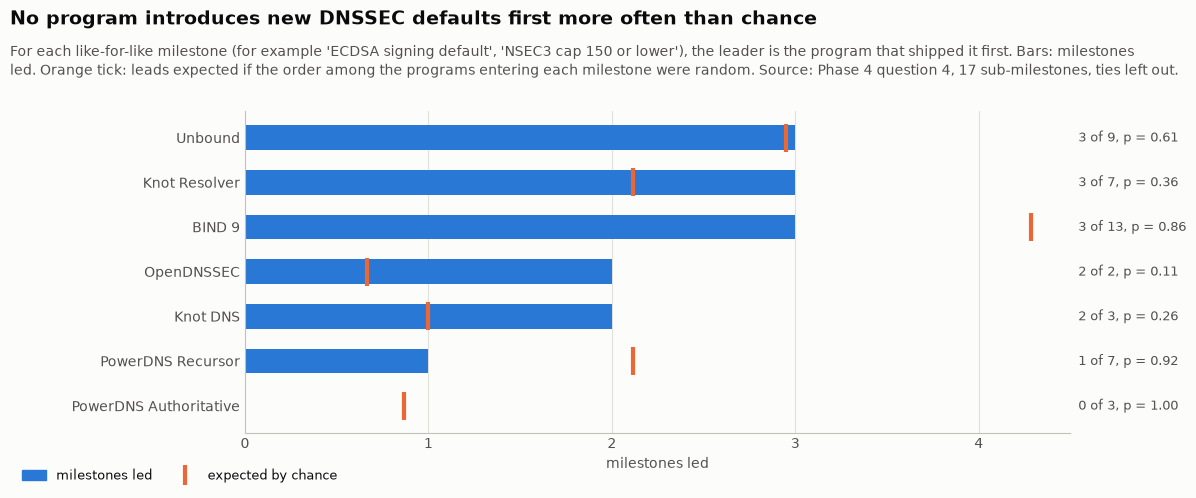

**How to read it.** A program that systematically moved first would have a bar well past its orange tick and a small p. The smallest p is OpenDNSSEC's 0.11, from 2 leads in 2 milestones. Right-hand text: leads, milestones entered, and the probability of at least that many leads by chance. The milestones are not independent, so these p-values are if anything too small, and still none is below 0.10.

In [59]:
lf = J4["q4_leader_follower"]["baseline_sub_milestones"]
lf = sorted(lf, key=lambda b: b["observed_leads"])
fig, ax = plt.subplots(figsize=(12.5, 1.9 + 0.45 * len(lf)))
frame(fig, "No program introduces new DNSSEC defaults first more often than chance",
      "For each like-for-like milestone (for example 'ECDSA signing default', 'NSEC3 cap 150 or lower'), the leader "
      "is the program that shipped it first. Bars: milestones led. Orange tick: leads expected if the order among "
      "the programs entering each milestone were random. Source: Phase 4 question 4, 17 sub-milestones, ties left out.",
      bottom=0.7, left=0.20, right=0.86)
y = np.arange(len(lf))
ax.barh(y, [b["observed_leads"] for b in lf], color=S1, height=0.55, zorder=2)
ax.scatter([b["expected_leads_by_chance"] for b in lf], y, marker="|", s=420, color=S2, lw=3, zorder=3)
for yi, b in zip(y, lf):
    ax.text(1.01, yi, f"{b['observed_leads']} of {b['contests_entered']}, p = {b['p_at_least_observed']:.2f}",
            transform=ax.get_yaxis_transform(), va="center", fontsize=9, color=INK_2)
ax.set_yticks(y); ax.set_yticklabels([NAME[b["program"]] for b in lf])
ax.set_xlabel("milestones led")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
style(ax, grid="x")
legend_below(fig, [Patch(color=S1, label="milestones led"),
                   Line2D([], [], marker="|", ls="", color=S2, ms=14, mew=3, label="expected by chance")])
save(fig, "leader_follower")
best = min(lf, key=lambda b: b["p_at_least_observed"])
say("**How to read it.** A program that systematically moved first would have a bar well past its orange tick and "
    f"a small p. The smallest p is {NAME[best['program']]}'s {best['p_at_least_observed']:.2f}, from "
    f"{best['observed_leads']} leads in {best['contests_entered']} milestones. Right-hand text: leads, milestones "
    "entered, and the probability of at least that many leads by chance. The milestones are not independent, so "
    "these p-values are if anything too small, and still none is below 0.10.")

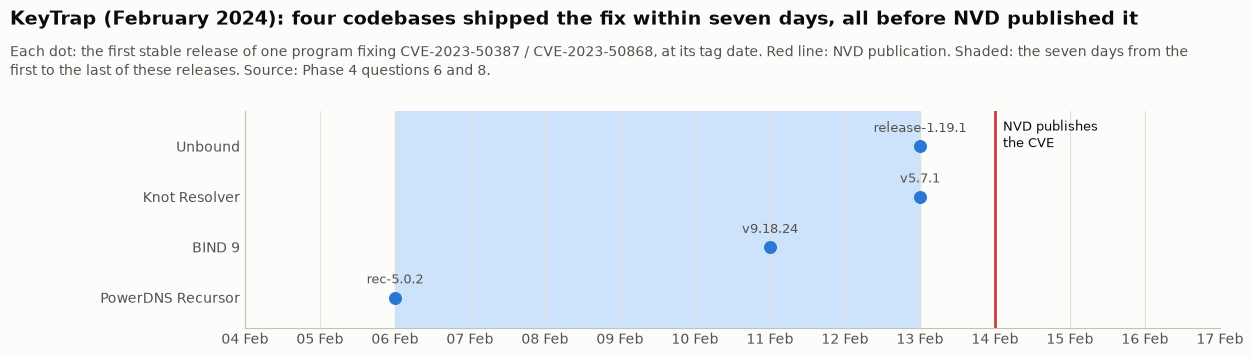

**How to read it.** Each row is one program, each dot the day its fixed release was tagged. PowerDNS Recursor's rec-5.0.2 is tagged on 6 February, but its changelog gives 13 February as the public date. Across the whole record Phase 4 counted pairs of codebases shipping the same fix or default within 3 days: 4 such release pairs, against 0.235 on average when each codebase's calendar is shifted at random (p = 0.001). All of them are this one embargoed event. The only other same-day coincidence, BIND 9 9.18.0 and PowerDNS Authoritative 4.6.0 both moving NSEC3 to 0 iterations on 2022-01-24, cannot be told apart from chance.

In [60]:
kt = CVE6[(CVE6.cve == "CVE-2023-50387") & (CVE6.group == "included")].copy()
nvd = pd.Timestamp(kt.nvd_published.iloc[0])
kt["t"] = pd.to_datetime(kt.stable_date)
kt = kt.sort_values("t")
fig, ax = plt.subplots(figsize=(12.5, 3.9))
frame(fig, "KeyTrap (February 2024): four codebases shipped the fix within seven days, all before NVD published it",
      "Each dot: the first stable release of one program fixing CVE-2023-50387 / CVE-2023-50868, at its tag date. "
      "Red line: NVD publication. Shaded: the seven days from the first to the last of these releases. Source: "
      "Phase 4 questions 6 and 8.", bottom=0.6, left=0.20)
t0, t1 = kt.t.min(), kt.t.max()
ax.axvspan(t0, t1, color=RAMP[0], zorder=0)
ax.axvline(nvd, color=RED, lw=2)
ax.text(nvd, len(kt) - 0.45, "  NVD publishes\n  the CVE", color=INK, fontsize=9, va="top")
for i, r in enumerate(kt.itertuples()):
    ax.scatter([r.t], [i], s=70, color=S1, zorder=3)
    ax.text(r.t, i + 0.28, f"{r.stable_tag}", ha="center", fontsize=9, color=INK_2)
ax.set_yticks(range(len(kt))); ax.set_yticklabels([NAME[p] for p in kt.program])
ax.set_ylim(-0.6, len(kt) - 0.3)
ax.set_xlim(t0 - pd.Timedelta(days=2), nvd + pd.Timedelta(days=3))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
style(ax, grid="x")
save(fig, "keytrap")
q8 = J4["q8_coordinated_releases"]["variants"]["tag_dates"]["tests"]["distinct_release_pairs"]
say("**How to read it.** Each row is one program, each dot the day its fixed release was tagged. PowerDNS "
    "Recursor's rec-5.0.2 is tagged on 6 February, but its changelog gives 13 February as the public date. "
    "Across the whole record Phase 4 counted pairs of codebases shipping the same fix or default within 3 days: "
    f"{q8['observed']} such release pairs, against {q8['null_mean']:g} on average when each codebase's calendar is "
    f"shifted at random (p = {q8['p_value_ge']}). All of them are this one embargoed event. The only other "
    "same-day coincidence, BIND 9 9.18.0 and PowerDNS Authoritative 4.6.0 both moving NSEC3 to 0 iterations on "
    "2022-01-24, cannot be told apart from chance.")

### Do sudden jumps in adoption line up with default changes?

Phase 7 also scanned every mapped series for **spikes**: months in which the count of zones or delegations with a
value jumps or drops sharply. A spike is "aligned" if a default change that should cause it (same value, same
direction) shipped 0 to 3 months before it. The chance rate is how often any month of that series has such a
default change 0 to 3 months before it.

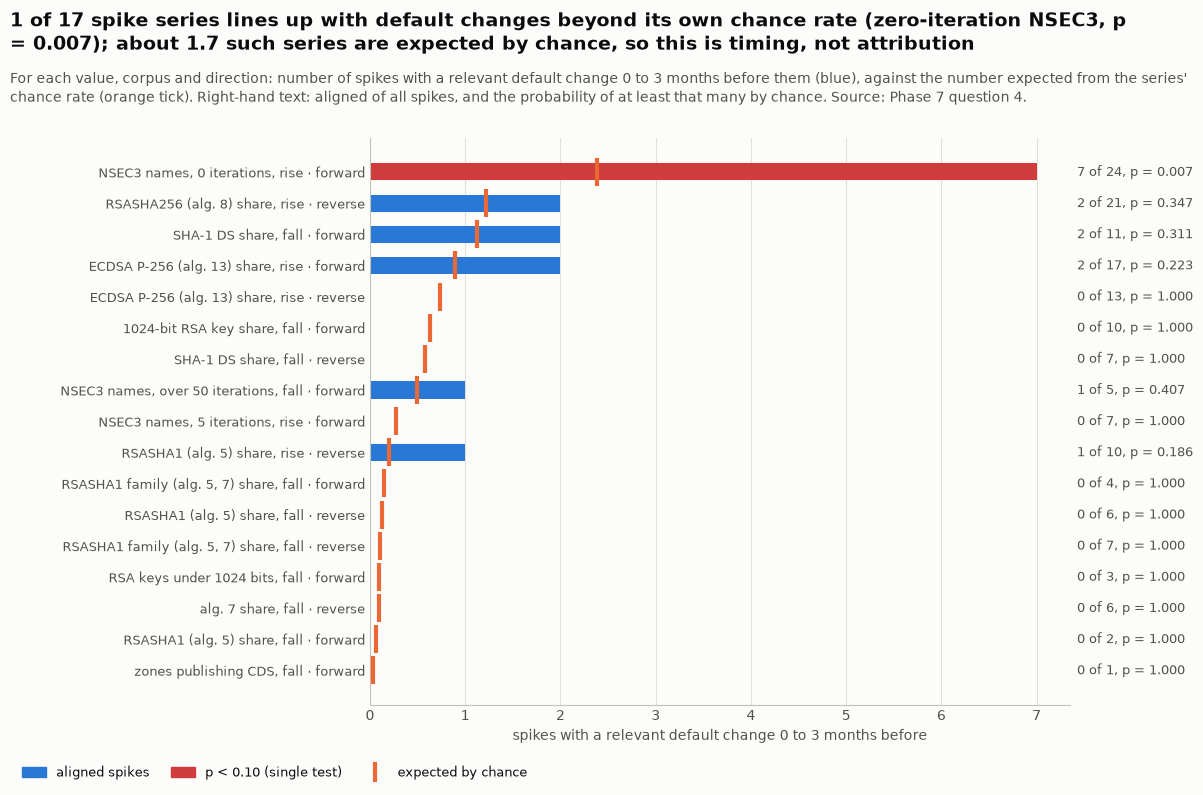

**How to read it.** A bar well past its orange tick means spikes follow default changes more often than chance. NSEC3 names, 0 iterations, rise (forward): 7 of 24 spikes aligned against 2.39 expected (p = 0.007), in 5 corpora: .ch, .fr, .li, .nu, .se. The defaults they follow: bind9 d18-nsec3param-default-0-0 2022-01-24; bind9 d21-signzone-nsec3-iterations-0 2022-07-07; knot knot[14]@3.2.0 2022-08-22; pdns-auth pdns-auth[11]@4.6.0 2022-01-24. With 17 series tested, about 1.7 would reach p < 0.10 by chance, and 0.007 is above a Bonferroni 0.10/17 = 0.0059. 3 of the 7 aligned spikes are one .ch series, and 5 of the 17 unaligned spikes fall in 2021-09 to 2021-12, before any such signer default shipped. This is timing, not attribution: those defaults and RFC 9276 (2022-08) fall within the same few months, the IETF draft behind them was public by 2021-10, .se/.nu and .ch/.li are each run by one registry, and the operators of the zones that changed cannot be identified.

In [61]:
al = Q4A[Q4A.aligned_within_3m.notna() & (Q4A.expected_aligned > 0)].copy()
UP = {"+", "1", "1.0", "up"}
al["lab"] = [f"{OBS_NAME.get(o, o)}, {'rise' if str(d) in UP else 'fall'} · {c}" for o, d, c in
             zip(al.observable, al.direction, al.corpus)]
al = al.sort_values("expected_aligned")
fig, ax = plt.subplots(figsize=(12.5, 1.9 + 0.36 * len(al)))
beat = al[al.beats_chance.astype(bool)]
n_ser, n10 = len(al), int((al.p_at_least_observed < 0.10).sum())
_names = " and ".join(sorted({ {"iter0": "zero-iteration NSEC3"}.get(o, OBS_NAME.get(o, o)) for o in beat.observable}))
ttl = ("No kind of spike lines up with default changes more often than its chance rate" if beat.empty else
       f"{n10} of {n_ser} spike series lines up with default changes beyond its own chance rate ({_names}, p = "
       + ", ".join(f"{p:.3f}" for p in beat.p_at_least_observed)
       + f"); about {0.10 * n_ser:.1f} such series are expected by chance, so this is timing, not attribution")
frame(fig, ttl,
      "For each value, corpus and direction: number of spikes with a relevant default change 0 to 3 months before "
      "them (blue), against the number expected from the series' chance rate (orange tick). Right-hand text: aligned "
      "of all spikes, and the probability of at least that many by chance. Source: Phase 7 question 4.",
      bottom=0.95, left=0.30, right=0.86)
y = np.arange(len(al))
ax.barh(y, al.aligned_within_3m, color=[RED if b else S1 for b in al.beats_chance.astype(bool)], height=0.55, zorder=2)
ax.scatter(al.expected_aligned, y, marker="|", s=380, color=S2, lw=3, zorder=3)
for yi, r in zip(y, al.itertuples()):
    ax.text(1.01, yi, f"{int(r.aligned_within_3m)} of {int(r.spikes)}, p = {r.p_at_least_observed:.3f}",
            transform=ax.get_yaxis_transform(), va="center", fontsize=9, color=INK_2)
ax.set_yticks(y); ax.set_yticklabels(al.lab, fontsize=9)
ax.set_xlabel("spikes with a relevant default change 0 to 3 months before")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
style(ax, grid="x")
legend_below(fig, [Patch(color=S1, label="aligned spikes"), Patch(color=RED, label="p < 0.10 (single test)"),
                   Line2D([], [], marker="|", ls="", color=S2, ms=14, mew=3, label="expected by chance")], ncol=3)
save(fig, "spike_alignment")
txt = ("**How to read it.** A bar well past its orange tick means spikes follow default changes more often than "
       "chance. ")
if beat.empty:
    txt += "No bar does."
for r in beat.itertuples():
    allsp = Q4[(Q4.observable == r.observable) & (Q4.direction == r.direction) & (Q4.corpus == r.corpus)]
    sp = allsp[allsp.relevant_default_within_3m.astype(bool)]
    un = allsp[~allsp.relevant_default_within_3m.astype(bool)]
    rel = MAP[(MAP.observable == r.observable) & (MAP.expected_direction.astype(str).isin(UP) if str(r.direction) in UP
                                                  else ~MAP.expected_direction.astype(str).isin(UP))]
    sp_m = [pd.Period(m[:7], "M") for m in sp.change_calendar_month_start.astype(str)]
    defs = sorted({f"{x.program} {x.row_id} {x.timing_date}" for x in rel.itertuples()
                   if any(0 <= (m - pd.Period(x.timing_date[:7], "M")).n <= 3 for m in sp_m)})
    first_def = rel.timing_date.min()[:7] if len(rel) else None
    before = un[un.change_calendar_month_start.astype(str).str[:7] < first_def] if first_def else un.iloc[0:0]
    by_src = sp.source.value_counts()
    txt += (f"{OBS_NAME.get(r.observable, r.observable)}, {'rise' if str(r.direction) in UP else 'fall'} ({r.corpus}): "
            f"{int(r.aligned_within_3m)} of {int(r.spikes)} spikes aligned against {r.expected_aligned:.2f} expected "
            f"(p = {r.p_at_least_observed:.3f}), in {sp.source.nunique()} corpora: "
            f"{', '.join(sorted(SRC.get(x, x) for x in sp.source.unique()))}. The defaults they follow: {'; '.join(defs)}. "
            f"With {n_ser} series tested, about {0.1 * n_ser:.1f} would reach p < 0.10 by chance, and "
            f"{r.p_at_least_observed:.3f} is {'above' if r.p_at_least_observed > 0.10 / n_ser else 'below'} a Bonferroni "
            f"0.10/{n_ser} = {0.10 / n_ser:.4f}. {by_src.iloc[0]} of the {len(sp)} aligned spikes are one "
            f"{SRC.get(by_src.index[0], by_src.index[0])} series"
            + (f", and {len(before)} of the {len(un)} unaligned spikes fall in "
               f"{before.change_calendar_month_start.astype(str).str[:7].min()} to "
               f"{before.change_calendar_month_start.astype(str).str[:7].max()}, before any such signer default shipped"
               if len(before) else "") + ". ")
if not beat.empty and "iter0" in set(beat.observable):
    txt += ("This is timing, not attribution: those defaults and RFC 9276 (2022-08) fall within the same few months, "
            "the IETF draft behind them was public by 2021-10, .se/.nu and .ch/.li are each run by one registry, and "
            "the operators of the zones that changed cannot be identified.")
say(txt)

## 5. Manual against automatic, and at which operator level

**What a "delegation change" is.** In the reverse data every month is a snapshot of the RIR zone files. A
*delegation* is one reverse zone handed to a network, for example `26.96.192.in-addr.arpa`. A **delegation change**
is a delegation that, between two monthly snapshots, gained a DS record (a new signing), lost it (an unsigning), or
changed its DS algorithm (a rollover). The *block* is the zone one label up, `96.192.in-addr.arpa`: in reverse DNS
that is one address allocation, so roughly one network operator.

**Action size.** An *action* is all the changes of the same kind in one month, one RIR and one block. If an upgrade
silently switches a signer to a new default, many zones of the same operator should flip at once: a large action.
A person editing zones by hand tends to produce actions of 1 or a few. **This is only a proxy:** one operator
automating a single zone looks like a manual edit, and one operator hand-editing a whole block looks like an upgrade.

**Level.** For each month and transition: *single delegation* (only one changed), *one block* (all in one block),
*concentrated* (several blocks, but one holds at least half), *diffuse* (spread over many blocks).

Phase 7 took the signer default changes that name a target algorithm, looked at the matching changes (new
signings and rollovers to that algorithm) in the release month and the three months after (ledger labels r+1 to
r+4), and compared them with all other months.

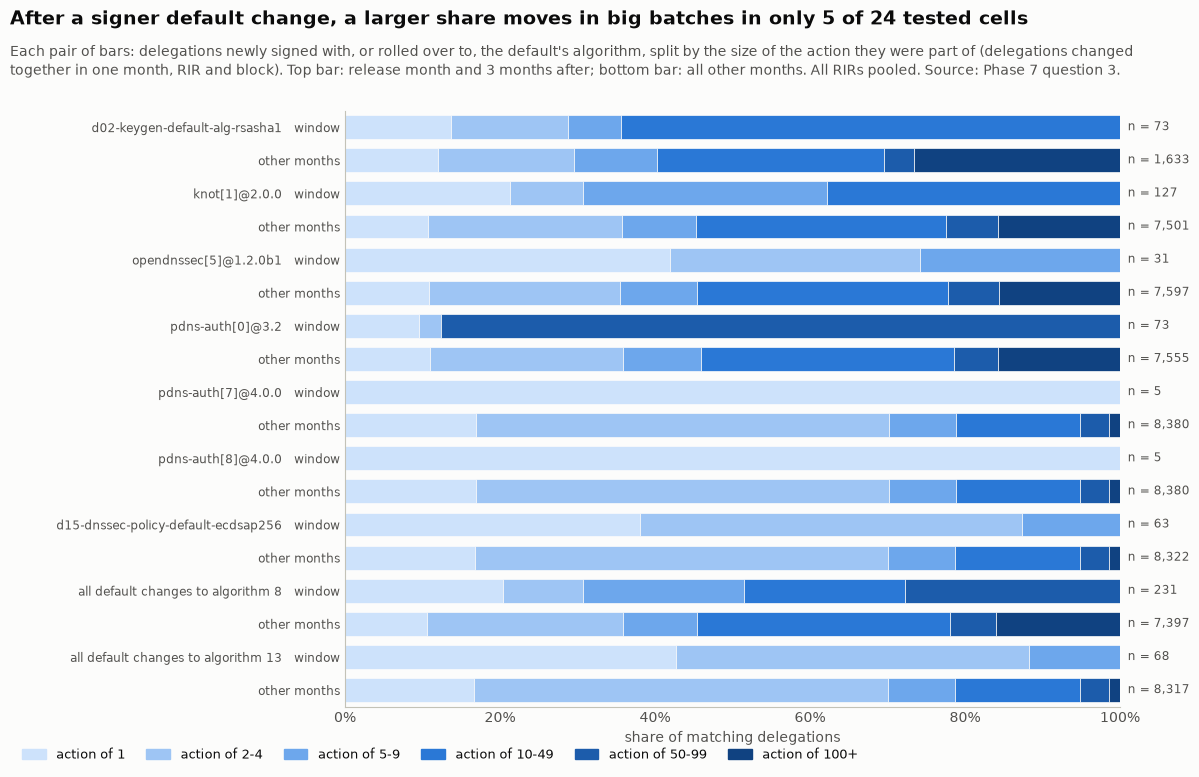

**How to read it.** Light colours on the left are small actions (one or a few delegations: manual-looking), dark colours on the right are large ones (10 or more at once: automatic-looking). If an upgrade flipped operators' zones in bulk, the top bar of each pair would be darker than the bottom one. The share moved in actions of 10 or more is lower in the window than in other months in 19 of 24 tested cells (pooled and per RIR). The group closest to a signal, pdns-auth[0]@3.2 (block-level p = 0.098), rests on one action: RIPE block 216.151.in-addr.arpa, 64 of the window's 73 matching delegations, signed between labels 2013-01 and 2013-02, i.e. during January 2013; the release was 2013-01-17, so the monthly snapshots cannot tell whether the block changed before or after it. Groups with no matching change in their window are left out: knot[2]@2.1.0.

In [62]:
bins_ = ["1", "2-4", "5-9", "10-49", "50-99", "100+"]
q3a = Q3[(Q3.scope == "all RIRs") & (Q3.status == "tested")].copy()
rows_ = []
for _, r in q3a.iterrows():
    w = np.array([r[f"window_delegations_by_size:{b}"] for b in bins_], float)
    o = np.array([r[f"other_delegations_by_size:{b}"] for b in bins_], float)
    rows_.append((f"{r.group}", "window", w / w.sum() * 100, int(w.sum())))
    rows_.append(("", "other months", o / o.sum() * 100, int(o.sum())))
fig, ax = plt.subplots(figsize=(12.5, 1.9 + 0.33 * len(rows_)))
nt_ = Q3[Q3.status == "tested"]
n_hi = int((nt_.diff_share_in_actions_ge_10 > 0).sum())
frame(fig, f"After a signer default change, a larger share moves in big batches in only {n_hi} of {len(nt_)} tested cells",
      "Each pair of bars: delegations newly signed with, or rolled over to, the default's algorithm, split by the size "
      "of the action they were part of (delegations changed together in one month, RIR and block). Top bar: "
      "release month and 3 months after; bottom bar: all other months. All RIRs pooled. Source: Phase 7 question 3.",
      bottom=0.75, left=0.28, right=0.90)
y = np.arange(len(rows_))
for yi, (g, kind, sh, n) in zip(y, rows_):
    left = 0
    for k, v in enumerate(sh):
        ax.barh(yi, v, left=left, color=RAMP[k], height=0.72, edgecolor=SURFACE, lw=0.5)
        left += v
    ax.text(101, yi, f"n = {n:,}", va="center", fontsize=8.6, color=INK_2)
ax.set_yticks(y)
ax.set_yticklabels([f"{g}   {k}" if g else k for g, k, _, _ in rows_], fontsize=8.6)
ax.set_xlim(0, 100); ax.set_ylim(len(rows_) - 0.5, -0.5)
pct_axis(ax, "x"); ax.set_xlabel("share of matching delegations")
style(ax, grid=None)
legend_below(fig, [Patch(color=RAMP[k], label=f"action of {b}") for k, b in enumerate(bins_)], ncol=6)
save(fig, "action_size")
# New computation (not a Phase 7 output): which actions make up the window of the group closest to a signal.
CL = pd.read_parquet(ROOT / "out/analysis/delegation_change_clusters.parquet")
ev3 = {e["row_id"]: e for e in jget(J7, "q3_manual_vs_automatic", "events", default=[])}
close = q3a.sort_values("p_block_ge_observed").iloc[0] if len(q3a) else None
comp = ""
if close is not None and close.group in ev3:
    e = ev3[close.group]
    w0, w1 = e["window"]
    x = CL[(CL.month >= w0) & (CL.month <= w1) & CL.kind.isin(["sign", "rollover"])
           & (CL.to_alg.astype(str) == str(e["to_alg"]))].sort_values("n_delegations", ascending=False)
    if len(x):
        big = x.iloc[0]
        lab_m = pd.Period(big.month, "M") - 1
        comp = (f" The group closest to a signal, {close.group} (block-level p = {close.p_block_ge_observed:.3f}), "
                f"rests on one action: {big.source.upper()} block {big.block}, {int(big.n_delegations)} of the "
                f"window's {int(x.n_delegations.sum())} matching delegations, { {"sign": "signed", "rollover": "rolled over"}.get(big.kind, big.kind)} between labels "
                f"{lab_m} and {big.month}, i.e. during {lab_m.strftime('%B %Y')}; the release was {e['timing_date']}, so "
                "the monthly snapshots cannot tell whether the block changed before or after it.")
nt = Q3[Q3.status == "tested"]
say("**How to read it.** Light colours on the left are small actions (one or a few delegations: manual-looking), "
    "dark colours on the right are large ones (10 or more at once: automatic-looking). If an upgrade flipped "
    "operators' zones in bulk, the top bar of each pair would be darker than the bottom one. The share moved in "
    f"actions of 10 or more is lower in the window than in other months in {int((nt.diff_share_in_actions_ge_10 < 0).sum())} "
    f"of {len(nt)} tested cells (pooled and per RIR)." + comp
    + " Groups with no matching change in their window are left out: "
    + (", ".join(sorted(set(Q3[(Q3.scope == 'all RIRs') & (Q3.status != 'tested')].group))) or "none") + ".")

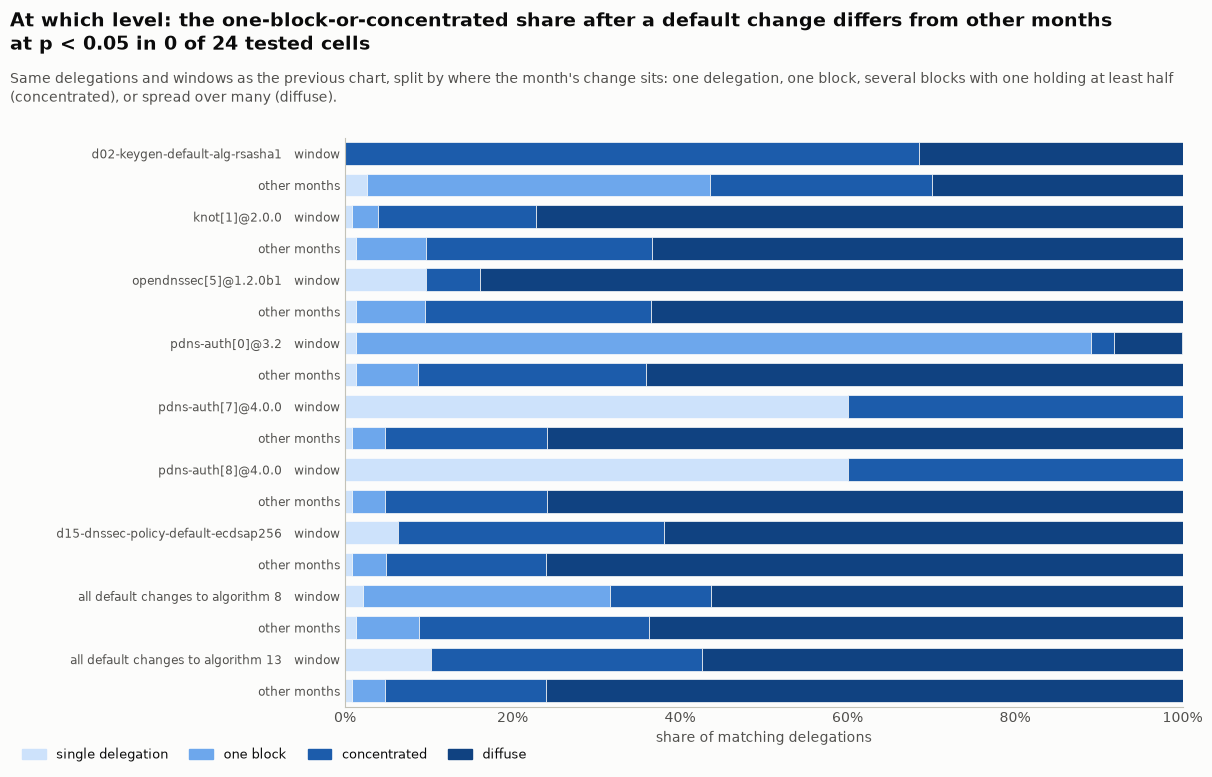

**How to read it.** The middle two colours (one block, concentrated) are changes tied to one operator's block; Phase 7 tests whether that share is higher after a default change. 'Diffuse' is deliberately not called coordinated: many unrelated operators doing a common thing in one month look identical to one actor doing it everywhere.

In [63]:
LEV = ["single delegation", "one block", "concentrated", "diffuse"]
rows_ = []
for _, r in q3a.iterrows():
    w = np.array([r[f"window_delegations_by_level:{b}"] for b in LEV], float)
    o = np.array([r[f"other_delegations_by_level:{b}"] for b in LEV], float)
    rows_.append((r.group, "window", w / w.sum() * 100))
    rows_.append(("", "other months", o / o.sum() * 100))
LCOL = [RAMP[0], RAMP[2], RAMP[4], RAMP[5]]
fig, ax = plt.subplots(figsize=(12.5, 1.9 + 0.33 * len(rows_)))
n_b = int((Q3[Q3.status == "tested"].p_block_ge_observed < 0.05).sum())
frame(fig, f"At which level: the one-block-or-concentrated share after a default change differs from other months "
           f"at p < 0.05 in {n_b} of {int((Q3.status == 'tested').sum())} tested cells",
      "Same delegations and windows as the previous chart, split by where the month's change sits: one delegation, "
      "one block, several blocks with one holding at least half (concentrated), or spread over many (diffuse).",
      bottom=0.75, left=0.28, right=0.95)
y = np.arange(len(rows_))
for yi, (g, kind, sh) in zip(y, rows_):
    left = 0
    for k, v in enumerate(sh):
        ax.barh(yi, v, left=left, color=LCOL[k], height=0.72, edgecolor=SURFACE, lw=0.5)
        left += v
ax.set_yticks(y); ax.set_yticklabels([f"{g}   {k}" if g else k for g, k, _ in rows_], fontsize=8.6)
ax.set_xlim(0, 100); ax.set_ylim(len(rows_) - 0.5, -0.5)
pct_axis(ax, "x"); ax.set_xlabel("share of matching delegations")
style(ax, grid=None)
legend_below(fig, [Patch(color=c, label=l) for c, l in zip(LCOL, LEV)], ncol=4)
save(fig, "change_level")
say("**How to read it.** The middle two colours (one block, concentrated) are changes tied to one operator's block; "
    "Phase 7 tests whether that share is higher after a default change. 'Diffuse' is deliberately not called "
    "coordinated: many unrelated operators doing a common thing in one month look identical to one actor doing it "
    "everywhere.")

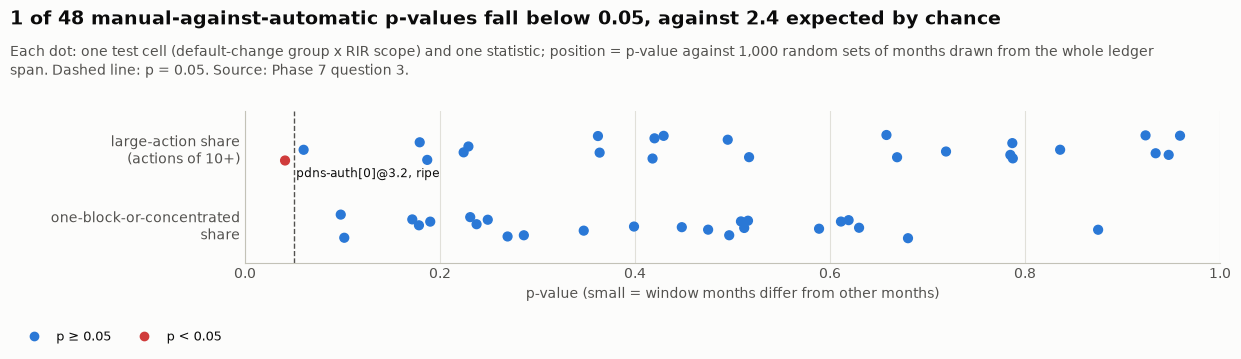

**How to read it.** With no effect anywhere, p-values spread evenly between 0 and 1, and about 1 in 20 falls below 0.05. Here 1 of 48 do. Below 0.05: pdns-auth[0]@3.2 in ripe (large-action share, p = 0.041); this is one RIPE block (216.151.in-addr.arpa, 64 of the window's 73 matching delegations) signed during January 2013, possibly before the release on the 17th. Pooled over all RIRs, pdns-auth[0]@3.2 has p = 0.060 (large actions) and 0.098 (block level); the era-matched version, which draws only months within 36 months of the window because ledger activity grew strongly from 2009 to 2019, gives 0.074 and 0.214.

In [64]:
t = Q3[Q3.status == "tested"].copy()
pv = pd.concat([t.assign(stat="large-action share\n(actions of 10+)", p=t.p_large_ge_observed),
                t.assign(stat="one-block-or-concentrated\nshare", p=t.p_block_ge_observed)])
fig, ax = plt.subplots(figsize=(12.5, 3.6))
frame(fig, f"{int((pv.p < 0.05).sum())} of {len(pv)} manual-against-automatic p-values fall below 0.05, "
           f"against {0.05 * len(pv):.1f} expected by chance",
      "Each dot: one test cell (default-change group x RIR scope) and one statistic; position = p-value against 1,000 "
      "random sets of months drawn from the whole ledger span. Dashed line: p = 0.05. Source: Phase 7 question 3.",
      bottom=0.95, left=0.20)
rng_ = np.random.default_rng(0)  # vertical jitter only, for legibility
for i, (stat, g) in enumerate(pv.groupby("stat", sort=False)):
    yy = i + rng_.uniform(-0.18, 0.18, len(g))
    ax.scatter(g.p, yy, s=40, color=[RED if p < 0.05 else S1 for p in g.p], zorder=3)
    for p_, y_, r_ in zip(g.p, yy, g.itertuples()):
        if p_ < 0.05:
            ax.annotate(f"{r_.group}, {r_.scope}", (p_, y_), xytext=(8, -12), textcoords="offset points", fontsize=8.5,
                        color=INK)
ax.axvline(0.05, color=INK_2, ls="--", lw=1)
ax.set_yticks([0, 1]); ax.set_yticklabels(pv.stat.unique())
ax.set_xlim(0, 1); ax.set_ylim(1.5, -0.5)
ax.set_xlabel("p-value (small = window months differ from other months)")
style(ax, grid="x")
legend_below(fig, [Line2D([], [], marker="o", ls="", color=S1, label="p ≥ 0.05"),
                   Line2D([], [], marker="o", ls="", color=RED, label="p < 0.05")], y_in=0.02)
save(fig, "manual_automatic_pvalues")
lo_ = pv[pv.p < 0.05]
txt = ("**How to read it.** With no effect anywhere, p-values spread evenly between 0 and 1, and about 1 in 20 falls "
       f"below 0.05. Here {len(lo_)} of {len(pv)} do. ")
if len(lo_):
    txt += "Below 0.05: " + "; ".join(f"{r.group} in {r.scope} ({r.stat.splitlines()[0]}, p = {r.p:.3f})"
                                      + (f"; {block_caveat(r.group)}" if block_caveat(r.group) else "")
                                      for r in lo_.itertuples()) + ". "
if close is not None:
    txt += (f"Pooled over all RIRs, {close.group} has p = {close.p_large_ge_observed:.3f} (large actions) and "
            f"{close.p_block_ge_observed:.3f} (block level); the era-matched version, which draws only months within "
            f"36 months of the window because ledger activity grew strongly from 2009 to 2019, gives "
            f"{close.p_large_era_matched:.3f} and {close.p_block_era_matched:.3f}"
            + (f"; {block_caveat(close.group)}" if block_caveat(close.group) and close.group not in set(lo_.group)
               else "") + ".")
say(txt)

## 6. Successor RFCs published while the predecessor is still deploying

For each pair "old practice / RFC that retires it", the old practice's share in the month the new RFC was
published, and how it moved in the year after. Descriptive only: this says nothing about cause.

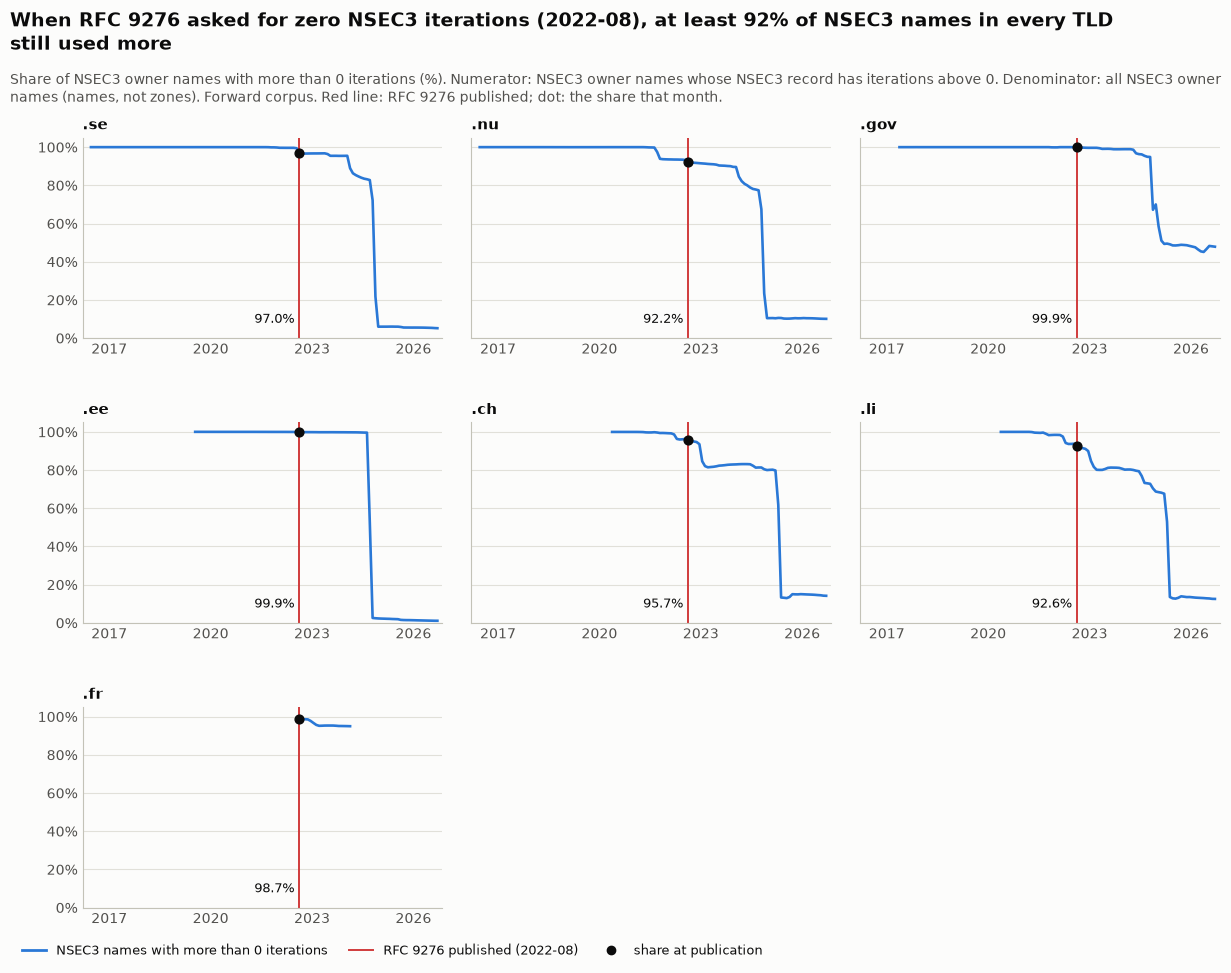

**How to read it.** Each panel is one TLD. The line is how much of the NSEC3 namespace still used the practice RFC 9276 retires. At publication it was 97.0% in .se, 92.2% in .nu, 99.9% in .gov, 99.9% in .ee, 95.7% in .ch, 92.6% in .li, 98.7% in .fr. Up to 12 months later it was flat in .se, .nu, .gov, .ee, .fr; fell in .ch, .li (a change of more than 10% relative counts as rising or falling). The reverse corpus cannot see NSEC3.

In [65]:
q5 = Q5[(Q5.predecessor == "RFC 5155") & (Q5.status == "covered")].set_index("source")
fig, axes = tld_grid(len(TLDS), 3, 12.5, 3.0, sharey=True)
frame(fig, f"When RFC 9276 asked for zero NSEC3 iterations (2022-08), at least {q5.share_at_successor.min():.0f}% of "
           "NSEC3 names in every TLD still used more",
      "Share of NSEC3 owner names with more than 0 iterations (%). Numerator: NSEC3 owner names whose NSEC3 record "
      "has iterations above 0. Denominator: all NSEC3 owner names (names, not zones). Forward corpus. Red line: "
      "RFC 9276 published; dot: the share that month.", bottom=0.7, hspace=0.42, wspace=0.08)
for ax, tld in zip(axes.flat, TLDS):
    s = series("iter_gt0", tld).dropna()
    ax.plot([m2y(m) for m in s.index], s.values, color=S1, lw=1.9)
    ax.axvline(m2y("2022-08"), color=RED, lw=1.4)
    r = q5.loc[tld]
    ax.scatter([m2y("2022-08")], [r.share_at_successor], s=40, color=INK, zorder=4)
    ax.text(m2y("2022-08") - 0.15, 8, f"{r.share_at_successor:.1f}%", ha="right", fontsize=9, color=INK)
    ax.set_title("." + tld, loc="left", fontweight="bold")
    ax.set_xlim(*FWD_XLIM); ax.set_ylim(0, 105)
    pct_axis(ax); year_axis(ax, 5); style(ax)
legend_below(fig, [Line2D([], [], color=S1, lw=2, label="NSEC3 names with more than 0 iterations"),
                   Line2D([], [], color=RED, lw=1.4, label="RFC 9276 published (2022-08)"),
                   Line2D([], [], marker="o", ls="", color=INK, label="share at publication")], ncol=3)
save(fig, "rfc9276_iterations")
traj = {k: [f".{s_}" for s_ in q5.index[q5.trajectory == k] if s_ in TLDS] for k in q5.trajectory.unique()}
say("**How to read it.** Each panel is one TLD. The line is how much of the NSEC3 namespace still used the practice "
    "RFC 9276 retires. At publication it was "
    + ", ".join(f"{q5.loc[t_].share_at_successor:.1f}% in .{t_}" for t_ in TLDS if t_ in q5.index)
    + ". Up to 12 months later it was " + "; ".join(f"{k} in {', '.join(v)}" for k, v in traj.items() if v)
    + " (a change of more than 10% relative counts as rising or falling). "
    + (f"It never fell below half its peak before the forward corpus ends in {FWD_END}. "
       if q5.first_below_half_peak_after_peak.isna().all() else "")
    + "The reverse corpus cannot see NSEC3.")

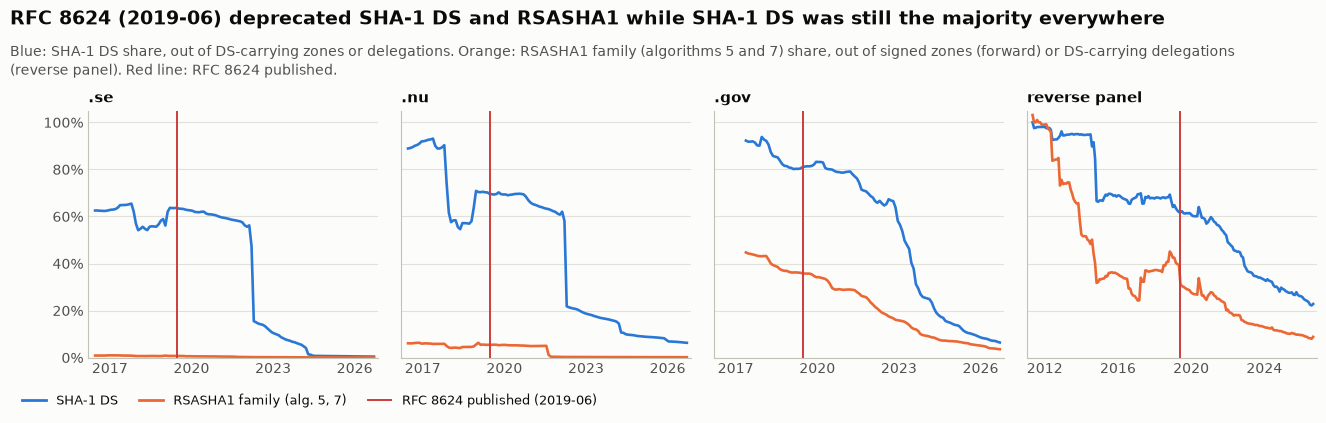

**How to read it.** At RFC 8624's publication SHA-1 DS was carried by 64% in .se, 70% in .nu, 81% in .gov, 62% in reverse panel of DS-carrying zones or delegations. It fell below half its level at its high point 34 to 47 months after the RFC. RSASHA1 was 1% in .se, 5% in .nu, 36% in .gov, 31% in reverse panel. On the reverse panel RSASHA1 was on a long decline that began well before the RFC: 99% of 103 in 2011-12, 72% of 200 in 2013-06, 50% of 313 in 2014-08, 24% of 907 in 2017-02, 31% of 1,964 in 2019-06, 9% of 6,546 in 2026-09 signed delegations. The panel's RSASHA1 line starts slightly above 100% (103% in 2011-05) because a delegation carrying both algorithm 5 and algorithm 7 DS records counts once in each; the panel then held at most 100 signed delegations. The early panel years rest on very few signed delegations, so their swings are noisy; 2014-08 is simply the first month with at least 300.

In [66]:
g8 = Q5[(Q5.successor == "RFC 8624") & (Q5.status == "covered")].set_index(["observable", "source"])
d1 = g8.xs("digest1", level="observable").share_at_successor
fig, axes = plt.subplots(1, 4, figsize=(13.5, 4.3), sharey=True)
frame(fig, "RFC 8624 (2019-06) deprecated SHA-1 DS and RSASHA1 while " +
      ("SHA-1 DS was still the majority everywhere" if (d1 > 50).all() else "both were still in use"),
      "Blue: SHA-1 DS share, out of DS-carrying zones or delegations. Orange: RSASHA1 family (algorithms 5 and 7) "
      "share, out of signed zones (forward) or DS-carrying delegations (reverse panel). Red line: RFC 8624 published.",
      bottom=0.7, wspace=0.08)
for ax, src in zip(axes, ["se", "nu", "gov", PANEL]):
    for obs, col in (("digest1", S1), ("alg5_7", S2)):
        s = series(obs, src).dropna()
        ax.plot([m2y(m, src == PANEL) for m in s.index], s.values, color=col, lw=1.9)
    ax.axvline(m2y("2019-06", src == PANEL), color=RED, lw=1.4)
    ax.set_title(SRC[src], loc="left", fontweight="bold")
    ax.set_xlim(PANEL_XLIM if src == PANEL else FWD_XLIM); ax.set_ylim(0, 105)
    pct_axis(ax); year_axis(ax, 4); style(ax)
legend_below(fig, [Line2D([], [], color=S1, lw=2, label="SHA-1 DS"),
                   Line2D([], [], color=S2, lw=2, label="RSASHA1 family (alg. 5, 7)"),
                   Line2D([], [], color=RED, lw=1.4, label="RFC 8624 published (2019-06)")], ncol=3)
save(fig, "rfc8624_sha1")
sh_, _, den_ = series_full("alg5_7", PANEL)
pts = [m for m in ("2011-12", "2013-06", "2014-08", "2017-02", "2019-06", sh_.dropna().index[-1]) if m in sh_.index]
trail = ", ".join(f"{sh_[m]:.0f}% of {int(den_[m]):,} in {m}" for m in pts if not math.isnan(sh_[m]))
below = g8.xs("digest1", level="observable").months_from_successor_to_below_half.dropna()
say("**How to read it.** At RFC 8624's publication SHA-1 DS was carried by "
    + ", ".join(f"{v:.0f}% in {SRC[k]}" for k, v in d1.items())
    + " of DS-carrying zones or delegations. "
    + (f"It fell below half its level at its high point {below.min():.0f} to {below.max():.0f} months after the RFC. "
       if len(below) else "")
    + "RSASHA1 was " + ", ".join(f"{v:.0f}% in {SRC[k]}" for k, v in
                                  g8.xs("alg5_7", level="observable").share_at_successor.items())
    + ". On the reverse panel RSASHA1 was on a long decline that began well before the RFC: " + trail
    + " signed delegations. " + RSA_NOTE + " The early panel years rest on very few signed delegations, so their swings are noisy; "
    "2014-08 is simply the first month with at least 300.")

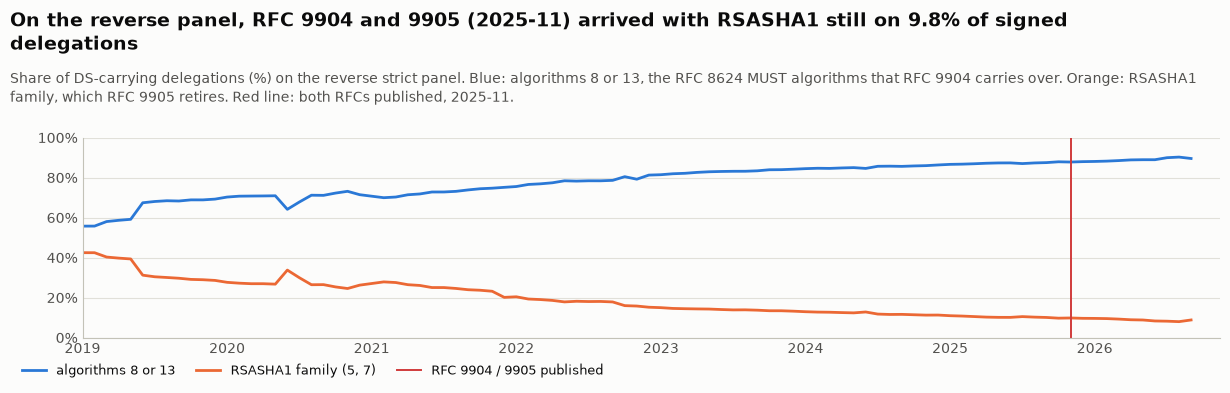

**How to read it.** Only the panel covers 2025-11. Algorithms 8 and 13 were 87.8% of signed delegations then and 89.6% in 2026-09; RSASHA1 was 9.8% and 8.8%. Two further pairs cannot be measured: RFC 4509 (SHA-256 DS) was published in 2006, before any corpus, and algorithm 12 (GOST), retired by RFC 9906, never appears in any corpus.

In [67]:
fig, ax = plt.subplots(figsize=(12.5, 4.0))
b9 = Q5[(Q5.successor == "RFC 9905") & (Q5.source == PANEL)]
frame(fig, "On the reverse panel, RFC 9904 and 9905 (2025-11) arrived with RSASHA1 still on "
           + (f"{b9.share_at_successor.iloc[0]:.1f}%" if len(b9) else "some") + " of signed delegations",
      "Share of DS-carrying delegations (%) on the reverse strict panel. Blue: algorithms 8 or 13, the RFC 8624 "
      "MUST algorithms that RFC 9904 carries over. Orange: RSASHA1 family, which RFC 9905 retires. Red line: both "
      "RFCs published, 2025-11.", bottom=0.6)
for obs, col in (("alg8_13", S1), ("alg5_7", S2)):
    s = series(obs, PANEL).dropna()
    s = s[s.index >= "2019-01"]
    ax.plot([m2y(m, True) for m in s.index], s.values, color=col, lw=2)
ax.axvline(m2y("2025-11", True), color=RED, lw=1.4)
ax.set_ylim(0, 100); ax.set_xlim(2019, PANEL_XLIM[1])
pct_axis(ax); year_axis(ax, 8); style(ax)
legend_below(fig, [Line2D([], [], color=S1, lw=2, label="algorithms 8 or 13"),
                   Line2D([], [], color=S2, lw=2, label="RSASHA1 family (5, 7)"),
                   Line2D([], [], color=RED, lw=1.4, label="RFC 9904 / 9905 published")], ncol=3)
save(fig, "rfc9904_9905_panel")
a = Q5[(Q5.successor == "RFC 9904") & (Q5.source == PANEL)].iloc[0]
b = Q5[(Q5.successor == "RFC 9905") & (Q5.source == PANEL)].iloc[0]
say(f"**How to read it.** Only the panel covers 2025-11. Algorithms 8 and 13 were {a.share_at_successor:.1f}% of "
    f"signed delegations then and {a.share_after_up_to_12m:.1f}% in {a.compare_month}; RSASHA1 was "
    f"{b.share_at_successor:.1f}% and {b.share_after_up_to_12m:.1f}%. Two further pairs cannot be measured: RFC 4509 "
    "(SHA-256 DS) was published in 2006, before any corpus, and algorithm 12 (GOST), retired by RFC 9906, never "
    "appears in any corpus.")

## 7. What this cannot show

* **Who signed a zone, and with which software.** Neither corpus records the signer or the DNS operator. Every
  alignment in this notebook is timing, not attribution.
* **Settings the zone files do not record:** NSEC3 salt length, NSEC and NSEC3 TTLs, RRSIG timing, key-management
  state, and everything a validator does (validation, trust anchors, limits other than the NSEC3 caps, which are
  tested only indirectly).
* **What a forward jump is made of.** Forward per-zone records are not in the repository, so a forward spike's split
  into new signings and rollovers is only bounded, and a digest spike has no composition at all.
* **Whether a reverse change in the release month came before or after the release day.** The reverse corpus has
  one snapshot per month.
* **Manual against automatic, directly.** Action size is a proxy; see section 5.

In [68]:
_no = jget(J7, "observable_mapping", "prevalence", "not_observable", default={}) or {}
_pn = jget(J7, "q2_default_change_events", "prevalence", "summary", "step12", "rows_with_no_test_in_any_corpus", default=[])
say("* **Adoption and feature use are different claims.** Section 2b asks whether software changes how many domains "
    f"are signed ({ADOPT_DEF}); the rest asks whether it changes which features signed zones use. A null result for "
    "one says nothing about the other. "
    + ("In the reverse corpus only DS adoption can be measured: " + "; ".join(f"{PNAME.get(k, k)}: {v}" for k, v in _no.items())
       + ". " if _no else "")
    + (f"Default changes that could change signing but have no adoption test: {', '.join(_pn)}." if _pn else ""))
# the corpus limits, from the data and from Phase 7's own "no test" reasons (never typed)
_s2 = Q2[is_step(Q2)]
_tested_any = set(_s2.loc[_s2.status == "tested", "row_id"])
_nt = _s2[_s2.status != "tested"]
_nobefore = sorted(set(_nt.loc[_nt.reason.astype(str).str.startswith("no before-period"), "row_id"]) - _tested_any)
_fwd_tested = set(_s2.loc[(_s2.corpus == "forward") & (_s2.status == "tested"), "row_id"])
_noafter = sorted(set(_nt.loc[(_nt.corpus == "forward") & _nt.reason.astype(str).str.startswith("no after-period"),
                              "row_id"]) - _fwd_tested)
say(f"* **Events outside the corpora.** Nothing before {PANEL_START} in the reverse panel or before {FWD_START} in "
    f"the forward TLDs, nothing after {PANEL_END} and {FWD_END} respectively, and, for the step test, nothing "
    "without 24 months of data before it and 12 after. "
    + (f"Default changes with no step test in any corpus because the data start too late: {len(_nobefore)} "
       f"({', '.join(_nobefore)}). " if _nobefore else "")
    + (f"Default changes the forward corpus cannot test because it ends in {FWD_END}: {len(_noafter)} "
       f"({', '.join(_noafter)})." if _noafter else f"No default change is lost to the forward corpus ending in {FWD_END}."))
bf_ = ("q1_per_program_releases", "aggregate", "bind9_feature_releases", "step12")
bn_, bo_ = val("J7", *bf_, "tested"), val("J7", *bf_, "mean_outside_90pct_null")
say(f"* **Multiple testing by q-value.** With at most {fmtv(MAXPLAC)} placebo months per series, no single test can "
    "reach a Benjamini-Hochberg q below 0.10 whatever the data, so the multiple-testing view here is judged by counts.\n"
    "* **A program-level test for BIND 9 on every stable release.** Its releases fill most months, so a shifted "
    "schedule cannot differ from the real one. "
    + (f"Its x.y.0 feature releases are tested instead (section 3.1: {bo_} of {bn_} outside the band, against "
       f"{0.1 * bn_:.1f} by chance)." if bn_ else "No other BIND 9 schedule is tested in this run."))
say("* **Measurement breaks.** The measured zone lists changed in " + (breaks_text() or NA) + ". For adoption, "
    f"leaving those months out changes which programs look unusual (releases: "
    f"{unit_txt(unit(UQ1, 'step12_breaks_masked'), 'outside_90pct_null')}). For feature use it matters too: "
    + (FEAT_BREAK_TXT or NA))
say("* **Small or noisy effects.** The step test detects only steps above a certain size, and a larger one in noisy "
    "series. " + (f"Chart 1 gives the sizes for feature use: {PW_TEXT}. " if PW_TEXT else "")
    + (f"Chart 2 gives them for adoption: {PPW_TEXT}. " if PPW_TEXT else "") + ("" if POWER else "This run of Phase 7 exports no detection-power table; the second Phase 7 "
                  "verification found that a 1 pp step was not detected and 5 to 10 pp steps only in quiet series. ")
    + "'Inside the band' therefore means 'no large lasting shift', not 'no effect'.")

* **Adoption and feature use are different claims.** Section 2b asks whether software changes how many domains are signed (the % of domains in a month with at least one DS, DNSKEY or RRSIG record); the rest asks whether it changes which features signed zones use. A null result for one says nothing about the other. In the reverse corpus only DS adoption can be measured: DNSKEY: reverse: an in-addr.arpa zone file holds only the delegation (NS, DS, glue); DNSKEY lives in the child zone and was not measured, so no reverse DNSKEY series is emitted; RRSIG: reverse: RRSIGs are child-side data; the RIR zone files carry only the DS, so no reverse RRSIG series is emitted. Default changes that could change signing but have no adoption test: nsd[0]@2.0.0, nsd[1]@2.2.0, nsd[2]@2.3.0, nsd[5]@3.2.6.

* **Events outside the corpora.** Nothing before 2011-05 in the reverse panel or before 2016-06 in the forward TLDs, nothing after 2026-09 and 2026-09 respectively, and, for the step test, nothing without 24 months of data before it and 12 after. Default changes with no step test in any corpus because the data start too late: 12 (d02-keygen-default-alg-rsasha1, d03-signzone-nsec3-iterations-100-to-10, knot[3]@2.2.0, knot[7]@2.6.0, opendnssec[3]@1.1.0rc1, opendnssec[5]@1.2.0b1, pdns-auth[0]@3.2, pdns-auth[1]@3.3, pdns-auth[3]@3.4.0, pdns-auth[4]@3.4.7, pdns-auth[9]@4.0.0, unbound[1]@0.5). Default changes the forward corpus cannot test because it ends in 2026-09: 1 (knot[19]@3.6.0).

* **Multiple testing by q-value.** With at most 149 placebo months per series, no single test can reach a Benjamini-Hochberg q below 0.10 whatever the data, so the multiple-testing view here is judged by counts.
* **A program-level test for BIND 9 on every stable release.** Its releases fill most months, so a shifted schedule cannot differ from the real one. Its x.y.0 feature releases are tested instead (section 3.1: 3 of 58 outside the band, against 5.8 by chance).

* **Measurement breaks.** The measured zone lists changed in .se 2017-05 to 2017-11; .se 2018-10 to 2019-01; .nu 2017-06 to 2017-09; .nu 2018-06 to 2019-02; .gov 2018-02 to 2018-03. For adoption, leaving those months out changes which programs look unusual (releases: 4 of 49 against 5.3 expected (a chance of about 0.79)). For feature use it matters too: With the measurement-break months left out, the release result becomes 31 of 144 against about 15.6 and 27 tests change side, and the default-change result 8 of 77 against about 9.1: the headline stays at chance, but which results are unusual depends on how the breaks are handled, so no single feature-use result is robust.

* **Small or noisy effects.** The step test detects only steps above a certain size, and a larger one in noisy series. Chart 1 gives the sizes for feature use: at one chosen event month, the smallest step detected is ECDSA .se: 1 pp; ECDSA reverse panel: 5 pp; SHA-1 DS .nu: 5 pp; across all possible event months (what the notebook calls 'detected'), ECDSA .se: not even 10 pp; ECDSA reverse panel: 10 pp; SHA-1 DS .nu: not even 10 pp. Chart 2 gives them for adoption: at one chosen event month the smallest step detected is DS adoption .se: 2 pp; DS adoption .nu: not even 10 pp; DS adoption reverse panel: 0.05 pp; across all possible event months DS adoption .se: 5 pp; DS adoption .nu: 10 pp; DS adoption reverse panel: 0.1 pp. 'Inside the band' therefore means 'no large lasting shift', not 'no effect'.

## Appendix: the numbers quoted above, checked against the source files

The hidden cell below asserts that ten numbers quoted in the text equal the values in the Phase 4 and Phase 7
outputs, so a rerun on changed data fails loudly instead of leaving stale text.

In [69]:
fresh = {k: json.loads((ROOT / p).read_text("utf-8")) for k, (p, _) in SOURCES.items()}
# a few headline numbers that the text uses, registered here in case a section above was skipped
for path in [("q1_per_program_releases", "aggregate", "step12", "tested"),
             ("q1_per_program_releases", "aggregate", "step12", "mean_outside_90pct_null"),
             ("q2_default_change_events", "summary", "step12", "n_tests"),
             ("q2_default_change_events", "summary", "step12", "n_outside_band")]:
    val("J7", *path)
for path in [("q1_per_program_releases", "prevalence", "aggregate", "step12", "tested"),
             ("q1_per_program_releases", "prevalence", "aggregate", "step12", "mean_outside_90pct_null"),
             ("q1_per_program_releases", "prevalence", "aggregate", "step12", "expected_by_calibrated_rate"),
             ("q2_default_change_events", "prevalence", "summary", "step12", "n_tests"),
             ("q2_default_change_events", "prevalence", "summary", "step12", "n_outside_band"),
             ("q2_default_change_events", "prevalence", "summary", "step12", "n_outside_and_expected_direction"),
             ("q4_spikes", "prevalence", "summary", "aligned_within_3m")]:
    val("J7", *path)
_mine = ds_unit(Q1P, 0.1)
_json = jget(fresh["J7"], *UQ1, "step12", default={}) or {}
if _mine and _json:
    assert (_mine[0], _mine[1]) == (_json["outside_90pct_null"], _json["units"]), \
        f"own DS-per-pair count {_mine[:2]} differs from Phase 7's unit count {_json}"
    print(f"own count of the DS program x corpus unit ({_mine[0]} of {_mine[1]}) equals Phase 7's")
for path in [("q1_per_program_releases", "prevalence", "break_sensitivity", "per_test", "step12", "outside_masked"),
             ("q1_per_program_releases", "break_sensitivity_feature", "per_test", "step12", "outside_masked"),
             ("q1_per_program_releases", "break_sensitivity_feature", "per_test", "step12", "tested_masked"),
             ("q2_default_change_events", "break_sensitivity_feature", "per_test", "step12", "outside_masked")]:
    val("J7", *path)
_pv = [q for q in QUOTED if "prevalence" in q[3]]
assert len(_pv) >= 4, f"only {len(_pv)} adoption (prevalence) numbers were registered"
i8 = ("q8_coordinated_releases", "variants", "tag_dates", "tests", "distinct_release_pairs")
val("J4", *i8, "observed"); val("J4", *i8, "p_value_ge")
seen, rows = set(), []
for label, v, src, path in QUOTED:
    if label in seen:
        continue
    seen.add(label)
    got = jget(fresh[src], *path)
    assert got == v, f"{label}: the text used {v}, the file now says {got}"
    rows.append((label, v))
assert len(rows) >= 10, f"only {len(rows)} numbers were quoted from the JSON"
print(f"{len(rows)} numbers quoted in the text match a fresh read of the source JSON:")
for label, v in rows:
    print(f"  {label} = {v}")
print("figures written:", len(list(FIGDIR.glob('*.png'))))

own count of the DS program x corpus unit (5 of 49) equals Phase 7's
56 numbers quoted in the text match a fresh read of the source JSON:
  J7:q1_per_program_releases/aggregate/step12/tested = 144
  J7:q1_per_program_releases/aggregate/step12/mean_outside_90pct_null = 26
  J7:q1_per_program_releases/aggregate/step12/expected_by_chance_at_10pct = 14.4
  J7:q1_per_program_releases/aggregate/step12/expected_by_calibrated_rate = 15.552
  J7:q1_per_program_releases/aggregate/bind9_feature_releases/step12/tested = 58
  J7:q1_per_program_releases/aggregate/bind9_feature_releases/step12/mean_outside_90pct_null = 3
  J7:q2_default_change_events/summary/step12/n_tests = 102
  J7:q2_default_change_events/summary/step12/n_outside_band = 11
  J7:q2_default_change_events/summary/step12/expected_outside_by_chance = 10.2
  J7:q2_default_change_events/summary/step12/expected_outside_discrete = 12.111186
  J7:q2_default_change_events/most_extreme_step_tests/0/percentile = 0.0
  J7:q2_default_change_even